# Blazar Population ML — Part 1: Jet Baryon Loading from Multi-wavelength Features

---

## Blazars and the Blazar Sequence

Blazars are among the most extreme class of radio-loud active galactic nuclei (AGN) whose characteristic jet closely aligned to the observer's line of sight. These objects are detectable across the full electromagnetic spectrum, from radio to $\gamma$-rays. The Fermi Large Area Telescope (*Fermi*-LAT) has shown that blazars are the dominant extragalactic source population in the $\gamma$-ray sky. In the fourth LAT AGN catalog (4LAC-DR3, Ajello et al. 2022), they account for more than 98% of associated extragalactic sources.

The spectral energy distribution (SED) of a blazar exhibits a characteristic double-bump structure. The low-frequency bump, ranging from radio to X-rays, is produced by synchrotron radiation from magnetically accelerated relativistic electrons in the jet. The high-frequency bump, peaking in the X-rays and even in the $\gamma$-rays, is produced by inverse Compton (IC) scattering of seed photons by those same electrons. 

Blazars have been historically classified into two subclasses:

**Flat-spectrum radio quasars (FSRQs)** are associated with high accretion rates onto the central supermassive black hole. Their jets can reach large bulk Lorentz factors ($\Gamma \sim 10\text{--}40$), and their emission region is immersed in the dense external photon field of the broad-line region (BLR), making external Compton (EC) the dominant radiative process. The result is a low synchrotron peak frequency ($\nu_{\rm syn} \lesssim 10^{13}$ Hz) and a high Compton dominance ($A_C \gg 1$), i.e., the IC peak outshines the synchrotron peak.

**BL Lac objects (BL Lacs)** are associated with low accretion rates. Their jets are slower, their BLR is faint or absent, and their emission is dominated by synchrotron self-Compton (SSC) processes. Synchrotron peak frequencies extend to $\nu_{\rm syn} \sim 10^{17}$ Hz for the most extreme high-synchrotron peaked (HSP) sources, and Compton dominance is near or below unity.

The systematic anti-correlation between synchrotron peak frequency and Compton dominance across the blazar population is known as the **blazar sequence** (Fossati et al. 1998; Donato et al. 2001). Its physical origin has been debated for two decades, and its interpretation, i.e., whether it reflects a genuine physical gradient in jet properties or a selection artifact of flux-limited samples, is central to blazar physics.

A third category complicates the observational picture. **Blazar candidates of uncertain type (BCUs)** comprise 35.5% of 4LAC-DR3: 1,208 sources with broadband properties consistent with blazars but without the optical spectroscopic data needed for definitive BL Lac or FSRQ classification. Placing BCUs within the blazar sequence framework is one of the primary goals of this project.

---

## Baryon Loading and Jet Composition

The physical composition of relativistic jets is a fundamental unsolved problem in high-energy astrophysics. Whether jets are dominated by electron-positron pairs or carry a significant hadronic component determines their total kinetic power and efficiency as particle accelerators, but this hadronic content cannot be measured directly. It must be inferred through a combination of radiative modeling and kinematic observations.

The key parameter is the **baryon loading** $\mu$, defined as the total energy flux per unit rest-mass energy flux of the jet (e.g, Komissarov et al. 2007):

$$\mu := \Gamma(1 + \sigma)$$

where $\Gamma$ is the bulk Lorentz factor and $\sigma$ is the jet magnetization, defined as the ratio of Poynting flux to hydrodynamic energy flux. A jet with $\mu \approx 1$ would be nearly magnetically dominated; larger $\mu$ means more energy per baryon is available for acceleration and radiation. According to magnetohydrodynamic (MHD) theory, $\mu$ is conserved along the jet during magnetic acceleration: as $\Gamma$ increases, $\sigma$ decreases proportionally, leaving $\mu$ imprinted by the launch conditions near the black hole. Constraining $\mu$ from observations is therefore a direct probe of the jet formation mechanism.

In Rueda-Becerril et al. (2021), the authors propose and tests a simple physical picture: all blazar jets are launched with similar energy per baryon, that is, $\mu$ is approximately constant across the entire blazar population regardless of jet power or accretion rate. The accretion rate $\dot{m}$ (in Eddington units) connects the bulk Lorentz factor and the jet luminosity through an empirical power-law relation motivated by VLBI observations ($\dot{m} \propto \Gamma^s$), effectively parameterizing the full SED by a single observable. Within this framework:

- **FSRQs** correspond to high $\dot{m}$. Their jets achieve large $\Gamma$ but settle at low magnetization ($\sigma \lesssim 10$) at the emission region. Magnetic reconnection injects a steep particle energy distribution ($p \gtrsim 2$), producing soft $\gamma$-ray spectra. The dense external photon field from the BLR drives EC emission, pushing Compton dominance to values well above unity and $\nu_{\rm syn}$ to low frequencies.
- **BL Lacs** correspond to low $\dot{m}$. Their jets do not reach large $\Gamma$, leaving the emission region more strongly magnetized ($\sigma \gtrsim 10$). Reconnection produces a hard particle spectrum ($p \lesssim 2$) and hard $\gamma$-ray emission at $\gtrsim$ GeV. The faint or absent BLR means SSC dominates, keeping $\nu_{\rm syn}$ at high frequencies and Compton dominance near or below unity.

Using the numerical code [`PARAMO`](https://github.com/altjerue/paramo) to solve the Fokker-Planck equation for the evolving electron distribution and compute synchrotron, SSC, and EC emission, the authors generate synthetic SEDs across a grid of magnetization values and compares them to observational data from Ghisellini et al. (2011) for the $\gamma$-ray spectral properties, Lister et al. (2019) for MOJAVE apparent velocities, and Finke (2013) for $A_C$. The **entire blazar sequence is recovered qualitatively for models with mild baryon loading $50 \lesssim \mu \lesssim 80$**. Jets with $\mu < 50$ are inconsistent with the Lorentz factors inferred from VLBI for highly magnetized cases, i.e., jets with $\mu > 80$ exceed observed apparent velocities. This narrow range constrains the energy per baryon of blazar jets independently of their accretion rate, providing the first simple physical model capable of accounting for the whole blazar population.

---

## This Project: Machine Learning Extension

Rueda-Becerril et al. (2021) established the population-level result: a constant baryon loading $\mu \approx 50\text{--}80$ is consistent with all blazar observables. What it did not provide is a source-by-source estimation of $\mu$ or a scalable method for classifying the thousands of catalog sources that lack individual SED modeling. This project addresses both gaps using classical machine learning on two observational datasets: the full 4LAC-DR3 catalog and the MOJAVE-XVII VLBI survey.

This first stage of the project will consist in two parts:

- **Part 1 (full catalog, ~3,400 sources):** catalog-native SED and spectral features only, no kinematics
- **Part 2 (MOJAVE cross-matched, ~334 sources):** adds $\beta_{\rm app}$ and $\Gamma_{\rm min}$

In this notebook we will endorse the first part of the project. We will be using $\gamma$-ray spectral features and SED parameters available for the full catalog. We will implement unsupervised dimensionality reduction (PCA, UMAP) and clustering (GMM, HDBSCAN) methods to map the blazar population and assign probabilistic BL Lac/FSRQ classifications to BCU sources. The central question is whether the feature space defined by *Fermi*-LAT observables recovers the blazar sequence structure predicted by the 2021 model without using class labels.

**Notebook sections:**

1. Setup and imports
2. Load and inspect 4LAC-DR3
3. Load and inspect MOJAVE-XVII
4. Cross-match: 4LAC-DR3 $\times$ MOJAVE-XVII
5. Feature derivation and unified dataframes
6. Missingness audit
7. Exploratory data analysis (EDA)
8. Dimensionality reduction & clustering
9. Conclusions

## 1. Setup and Imports

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan
from pathlib import Path

from astropy.io import fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

import warnings

warnings.filterwarnings("ignore")

# Cosmology (consistent with 2021 paper)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Paths
DATA_DIR = Path("data/")
LAC_H = DATA_DIR / "table-4LAC-DR3-h.fits"
MOJAVE = DATA_DIR / "VizieR-MOJAVE-XVII.fit"

# Plot style
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
CLASS_COLORS = {"bll": "steelblue", "fsrq": "tomato", "bcu": "green"}
SED_COLORS = {"lsp": "tomato", "isp": "goldenrod", "hsp": "steelblue"}

## 2. Load and Inspect 4LAC-DR3

### Inspecting `table-4LAC-DR3-h.fits`

In [153]:
def safe_float(col):
    return np.ma.filled(col.data, np.nan).astype(float)


def safe_str(col):
    return np.array([str(v).strip() if v is not np.ma.masked else "" for v in col])


def safe_str_lower(col):
    return np.array(
        [str(v).strip().lower() if v is not np.ma.masked else "" for v in col]
    )

In [154]:
# Exploring header data units (HDUs)
with fits.open(LAC_H) as hdul:
    for i, hdu in enumerate(hdul):
        print(f"HDU {i}: {type(hdu).__name__}")
        if hasattr(hdu, "columns") and hdu.columns:
            print(f"Rows: {len(hdu.data)}")
            print(f"Columns ({len(hdu.columns)}):")
            for col in hdu.columns:
                print(
                    f"  {col.name:30s}  {col.format:6s}  {col.unit if col.unit else ''}"
                )

HDU 0: PrimaryHDU
HDU 1: BinTableHDU
Rows: 3407
Columns (41):
  Source_Name                     18A     
  DataRelease                     I       
  RAJ2000                         E       deg
  DEJ2000                         E       deg
  GLON                            E       deg
  GLAT                            E       deg
  Signif_Avg                      E       
  Flux1000                        E       ph cm-2 s-1
  Unc_Flux1000                    E       ph cm-2 s-1
  Energy_Flux100                  E       erg cm-2 s-1
  Unc_Energy_Flux100              E       erg cm-2 s-1
  SpectrumType                    18A     
  PL_Index                        E       
  Unc_PL_Index                    E       
  Pivot_Energy                    E       MeV
  LP_Index                        E       
  Unc_LP_Index                    E       
  LP_beta                         E       
  Unc_LP_beta                     E       
  Flags                           I       
  CLASS          

In [155]:
lac = Table.read(LAC_H)
lac_len = len(lac)

cls_mixed = safe_str(lac["CLASS"])
cls_lower = safe_str_lower(lac["CLASS"])
sed_arr = safe_str_lower(lac["SED_class"])

# Finding unique values in CLASS column
classes, cls_counts = np.unique(cls_lower, return_counts=True)
classes_mixed, counts_mixed = np.unique(cls_mixed, return_counts=True)

# Finding unique values in SED_class column
sed, sed_counts = np.unique(sed_arr, return_counts=True)

### `CLASS` distribution

In [156]:
for cl, n in sorted(zip(classes_mixed, counts_mixed), key=lambda x: -x[1]):
    print(f"{cl:10s}  {n:5d}  ({100 * n / lac_len:.1f}%)")

bll          1357  (39.8%)
bcu          1208  (35.5%)
fsrq          715  (21.0%)
FSRQ           40  (1.2%)
rdg            36  (1.1%)
BLL            22  (0.6%)
RDG             6  (0.2%)
agn             6  (0.2%)
css             5  (0.1%)
NLSY1           4  (0.1%)
nlsy1           4  (0.1%)
ssrq            2  (0.1%)
AGN             1  (0.0%)
sey             1  (0.0%)


The class labels need to be case-homogenized.

### `SED_class` distribution

In [157]:
for s, n in sorted(zip(sed, sed_counts), key=lambda x: -x[1]):
    label = s if s else "(missing)"
    print(f"{label:10s}  {n:5d}  ({100 * n / lac_len:.1f}%)")

lsp          1564  (45.9%)
(missing)     777  (22.8%)
hsp           551  (16.2%)
isp           515  (15.1%)


### Missingness for key features

From [FERMILAC (Fermi LAT Fourth AGN Catalog)](https://heasarc.gsfc.nasa.gov/W3Browse/fermi/fermilac.html) we list the key features for your analysis and their definition:

- **Energy_Flux100**: The energy flux from 100 MeV to 100 GeV, in erg/cm2/s.
- **PL_Index**: The photon index when fitting with the PowerLaw model.
- **LP_Index**: The photon index at pivot_energy when fitting with LogParabola model.
- **Redshift**: The redshift of the AGN.
- **HE_EPeak**: The energy in the observer frame of the high-energy SED peak, in MeV.
- **HE_nuFnuPeak**: The 1-sigma error on spectral energy distribution at high-energy-peak frequency, in erg/cm2/s.
- **nu_syn**: The synchrotron-peak frequency in the observer frame, in Hz.
- **nuFnu_syn**: The quantity $\nu * F_{\nu} at the synchrotron-peak frequency, in erg/cm2/s. 
- **Variability_Index**: The sum of the log(likelihood) difference between the flux fitted in each time interval and the average flux over the full catalog interval; a value greater than 18.48 over 12 intervals indicates <1% chance of being a steady source.
- **Frac_Variability**: The fractional variability computed from the fluxes in each year.

In [158]:
key_cols = [
    "PL_Index",
    "LP_Index",
    "Redshift",
    "nu_syn",
    "nuFnu_syn",
    "HE_EPeak",
    "HE_nuFnuPeak",
    "Variability_Index",
    "Frac_Variability",
    "Energy_Flux100",
]

for col in key_cols:
    arr = safe_float(lac[col])
    n_nan = np.sum(np.isnan(arr))
    n_zero = np.sum(arr == 0)
    print(
        f"{col:25s}  missing: {n_nan:4d} ({100 * n_nan / lac_len:5.1f}%)  zero: {n_zero:4d}"
    )

print(f"\nN = {lac_len}")

PL_Index                   missing:    0 (  0.0%)  zero:    0
LP_Index                   missing:    0 (  0.0%)  zero:    0
Redshift                   missing:    0 (  0.0%)  zero:    0
nu_syn                     missing:    0 (  0.0%)  zero:  777
nuFnu_syn                  missing:    0 (  0.0%)  zero:  777
HE_EPeak                   missing:  518 ( 15.2%)  zero:    0
HE_nuFnuPeak               missing:    0 (  0.0%)  zero:    0
Variability_Index          missing:    0 (  0.0%)  zero:    0
Frac_Variability           missing:    0 (  0.0%)  zero:  874
Energy_Flux100             missing:    0 (  0.0%)  zero:    0

N = 3407


### Derived features feasibility

In [159]:
he_nufnu = safe_float(lac["HE_nuFnuPeak"])
nufnu_syn = safe_float(lac["nuFnu_syn"])
nu_syn = safe_float(lac["nu_syn"])
e_flux100 = safe_float(lac["Energy_Flux100"])
z = np.nan_to_num(lac["Redshift"].data, nan=0.0, posinf=0.0, neginf=0.0)

has_sed = (nufnu_syn > 0) & (he_nufnu > 0) & (~np.isnan(he_nufnu))
has_z = z > 0
has_lum = has_z & (e_flux100 > 0) & (~np.isnan(e_flux100))
has_cd = has_sed
is_blazar = np.isin(cls_lower, ["bll", "fsrq"])
is_bcu = cls_lower == "bcu"

### Compton Dominance and Gamma-ray Luminosity

In [160]:
cd_valid = np.sum(has_cd)
lum_valid = np.sum(has_lum)

print(
    f"Compton dominance computable:    {cd_valid:4d}/{lac_len}  ({100 * cd_valid / lac_len:.1f}%)"
)
print(
    f"Gamma-ray luminosity computable: {lum_valid:4d}/{lac_len}  ({100 * lum_valid / lac_len:.1f}%)"
)

Compton dominance computable:    2247/3407  (66.0%)
Gamma-ray luminosity computable: 1806/3407  (53.0%)


### Redshift

Note: Redshift 0 means "no measurement", not actually z = 0.

In [161]:
print(f"z > 0 (measured):    {np.sum(z > 0):4d} ({100 * np.sum(z > 0) / lac_len:.1f}%)")
print(
    f"z = 0 (no redshift): {np.sum(z == 0):4d} ({100 * np.sum(z == 0) / lac_len:.1f}%)"
)

z > 0 (measured):    1806 (53.0%)
z = 0 (no redshift): 1601 (47.0%)


### `CLASS` case normalization issue

Mixed case entries detected: bll vs BLL, fsrq vs FSRQ; need normalization

In [162]:
for cl, n in sorted(zip(classes, cls_counts), key=lambda x: -x[1]):
    print(f"{cl:5s} + {cl.upper():5s} = {n:5d} ({100 * n / cls_counts.sum():.1f}%)")

bll   + BLL   =  1379 (40.5%)
bcu   + BCU   =  1208 (35.5%)
fsrq  + FSRQ  =   755 (22.2%)
rdg   + RDG   =    42 (1.2%)
nlsy1 + NLSY1 =     8 (0.2%)
agn   + AGN   =     7 (0.2%)
css   + CSS   =     5 (0.1%)
ssrq  + SSRQ  =     2 (0.1%)
sey   + SEY   =     1 (0.0%)


### BCU SED class breakdown

In [163]:
bcu_sed, bcu_counts = np.unique(sed_arr[is_bcu], return_counts=True)

for s, n in sorted(zip(bcu_sed, bcu_counts), key=lambda x: -x[1]):
    label = s if s else "(no SED class)"
    print(f"{label:15s}  {n:4d}")

lsp               508
(no SED class)    448
isp               135
hsp               117


### Confirmed blazars (BL Lacs + FSRQs) by SED class

In [164]:
bl_sed, bl_counts = np.unique(sed_arr[is_blazar], return_counts=True)

for s, n in sorted(zip(bl_sed, bl_counts), key=lambda x: -x[1]):
    label = s if s else "(no SED class)"
    print(f"{label:15s}  {n:4d}")

lsp              1025
hsp               429
isp               367
(no SED class)    313


### Summary of LAC structure

**Effective Sample Sizes**

In [165]:
print(f"Total sources:                   {lac_len:4d}")
print(
    f"Confirmed blazars (BL Lac + FSRQ): {np.sum(is_blazar):4d}  ({100 * np.sum(is_blazar) / lac_len:.1f}%)"
)
print(
    f"BCU:                               {np.sum(is_bcu):4d}  ({100 * np.sum(is_bcu) / lac_len:.1f}%)"
)
print(
    f"With SED peak (nu_syn > 0):        {np.sum(nufnu_syn > 0):4d}  ({100 * np.sum(nufnu_syn > 0) / lac_len:.1f}%)"
)
print(
    f"With Compton dominance:            {np.sum(has_cd):4d}  ({100 * np.sum(has_cd) / lac_len:.1f}%)"
)
print(
    f"With redshift:                     {np.sum(has_z):4d}  ({100 * np.sum(has_z) / lac_len:.1f}%)"
)
print(
    f"With luminosity (z * flux):        {np.sum(has_lum):4d}  ({100 * np.sum(has_lum) / lac_len:.1f}%)"
)
print(
    f"Confirmed blazars + all above:     {np.sum(is_blazar & has_cd & has_lum):4d}  ({100 * np.sum(is_blazar & has_cd & has_lum) / lac_len:.1f}%)"
)

Total sources:                   3407
Confirmed blazars (BL Lac + FSRQ): 2134  (62.6%)
BCU:                               1208  (35.5%)
With SED peak (nu_syn > 0):        2630  (77.2%)
With Compton dominance:            2247  (66.0%)
With redshift:                     1806  (53.0%)
With luminosity (z * flux):        1806  (53.0%)
Confirmed blazars + all above:     1203  (35.3%)


**1. `CLASS` distribution (after normalization):**
- BL Lac: 1,379 (40.5%)
- BCU: 1,208 (35.5%) $\rightarrow$ largest uncertainty population
- FSRQ: 755 (22.2%)
- Radio Galaxy: 42 (1.2%)
- Other (NLSY1, AGN, CSS, SSRQ, SEY): 23 (~0.6%)

**2. `SED_class` distribution:**
- Shows Low synchrotron peaked (LSP) sources dominate at 45.9%, while 777 entries (22.8%) missing SED classification.
- The missing SED class correspond exactly to sources lacking synchrotron peak measurements (i.e., zero `nu_syn` or `nuFnu_syn` values), predominantly BCUs.
- High synchrotron peaked (HSP) and Intermediate synchrotron peaked (ISP) make up the remaining 31.3% of classified sources.

**3.Missingness:**
- Looking at the missing patterns, `PL_index` and `LP_index` are fully populated, but there are gaps elsewhere that need investigation.
- Redshift is encoded as 0 for unmeasured sources rather than NaN.
- `HE_EPeak` has 518 missing entries (15.2%), while `Energy_Flux100` is complete.
- For derived features, Compton dominance has good coverage at 66%, but $\gamma$-ray luminosity is constrained by redshift availability at only 53%.

Looking at the effective sample sizes, the full catalog has 3,407 sources, but only 1,806 have redshift data needed for luminosity calculations, and just 1,208 are BCUs (the actual classification targets).

The confirmed blazars (BLL + FSRQ) total 2,134 sources, which gives a solid training set.

---

## 3. Load and Inspect MOJAVE-XVII

### Inspecting HDU content

In [166]:
# Exploring header data units (HDUs)
with fits.open(MOJAVE) as hdul:
    print(f"HDUs: {len(hdul)}")
    for i, hdu in enumerate(hdul):
        print(f"\nHDU {i}: {type(hdu).__name__}")
        if hasattr(hdu, "columns") and hdu.columns:
            print(f"  Rows: {len(hdu.data)}")
            print(f"  Columns ({len(hdu.columns)}):")
            for col in hdu.columns:
                print(
                    f"    {col.name:20s}  {col.format:6s}  {col.unit if col.unit else ''}"
                )

HDUs: 6

HDU 0: PrimaryHDU

HDU 1: TableHDU
  Rows: 204
  Columns (22):
    Nf                    I3      
    ID                    A8      
    Nacc                  I3      
    Nvm                   I3      
    f_ID                  A3      
    OName                 A20     
    Cl                    A1      
    z                     F7.4    
    lognu                 F4.1    log(Hz)
    r_lognu               A2      
    muMax                 F6.1    uarcsec/yr
    e_muMax               F5.1    uarcsec/yr
    f_muMax               A1      
    betaMax               F7.4    
    e_betaMax             F7.4    
    Ref                   A19     
    L11                   I3      
    L13                   I3      
    SimbadName            F       
    NED                   A3      
    _RA                   F9.5    deg
    _DE                   F9.5    deg

HDU 2: TableHDU
  Rows: 230
  Columns (22):
    ID                    A8      
    Nacc                  I3      
    Nvm   

`VizieR-MOJAVE-XVII.fit` file has 6 HDUs:

- **HDU 1**
    - 204 rows
    - source list with max apparent velocity `betaMax`
- **HDU 2**
    - 230 rows
    - includes `Smax`, the peak flux density
- **HDU 3**
    - 39,294 rows
    - individual component measurements
    - VLBI component data
- **HDU 4**
    - 1,743 rows
    - individual component kinematics
    - per-component proper motions, beta
- **HDU 5**
    - 881 rows
    - component kinematics with acceleration data

### Inspecting data distributions

In [167]:
with fits.open(MOJAVE) as hdul:
    # Check HDU 1 and 2 (the source level tables)
    for hdu_idx in [1, 2]:
        hdu = hdul[hdu_idx]
        data = hdu.data
        print(f"=== HDU {hdu_idx} ({len(data)} sources) ===")

        # Sample IDs and coordinates
        ids = [str(r["ID"]).strip() for r in data[:5]]
        ras = [r["_RA"] for r in data[:5]]
        decs = [r["_DE"] for r in data[:5]]
        betas = [r["betaMax"] for r in data[:5]]
        print(f"  Sample IDs:      {ids}")
        print(f"  Sample RAs:      {[f'{r:.4f}' for r in ras]}")
        print(f"  Sample DECs:     {[f'{d:.4f}' for d in decs]}")
        print(f"  Sample betaMax:  {[f'{b:.4f}' for b in betas]}")

        # betaMax distribution
        betas_all = safe_float(data["betaMax"])
        print(f"  betaMax range: {betas_all.min():.2f} - {betas_all.max():.2f}")
        print(f"  betaMax median: {np.median(betas_all):.2f}")
        print(f"  betamax = 0: {np.sum(betas_all == 0)}")

        # Redshift coverage
        zs = np.array([r["z"] for r in data])
        print(f"  z > 0: {np.sum(zs > 0)} / {len(data)}")

        # Class column
        cls = safe_str(data["Cl"])
        unique_cls, counts = np.unique(cls, return_counts=True)
        cls_dict = {str(u): int(c) for u, c in zip(unique_cls, counts)}
        print(f"  Classes: {cls_dict}")

    # HDU 4: per-component kinematics, checking if useful for individual beta
    hdu4 = hdul[4].data
    print(f"=== HDU 4 sample (per-component beta) ===")
    unique_ids = list(set([str(r["ID"]).strip() for r in hdu4]))
    print(f"  Unique sources in HDU4: {len(unique_ids)}")
    betas4 = np.array([r["beta"] for r in hdu4])
    print(f"  beta range: {betas4.min():.3f} - {betas4.max():.3f}")

=== HDU 1 (204 sources) ===
  Sample IDs:      ['0003+380', '0006+061', '0011+189', '0010+405', '0015-054']
  Sample RAs:      ['1.4882', '2.2664', '3.4849', '3.3797', '4.3992']
  Sample DECs:     ['38.3375', '6.4726', '19.1783', '40.8603', '-5.2116']
  Sample betaMax:  ['4.6100', '0.0000', '4.5400', '6.9200', '0.7200']
  betaMax range: 0.00 - 34.80
  betaMax median: 1.44
  betamax = 0: 53
  z > 0: 165 / 204
  Classes: {'B': 79, 'G': 16, 'N': 4, 'Q': 101, 'U': 4}
=== HDU 2 (230 sources) ===
  Sample IDs:      ['0003-066', '0007+106', '0016+731', '0048-097', '0059+581']
  Sample RAs:      ['1.5579', '2.6292', '4.9408', '12.6722', '15.6907']
  Sample DECs:     ['-6.3932', '10.9749', '73.4583', '-9.4848', '58.4031']
  Sample betaMax:  ['7.0800', '1.5800', '7.6400', '0.0000', '8.6200']
  betaMax range: 0.00 - 41.50
  betaMax median: 7.02
  betamax = 0: 48
  z > 0: 210 / 230
  Classes: {'B': 38, 'G': 10, 'N': 1, 'Q': 175, 'U': 6}
=== HDU 4 sample (per-component beta) ===
  Unique sources in

### Summary of MOJAVE data

From this inspections we find:

**HDU 1:**

- 204 sources that appear to be:
    - BL Lacs (79 B-class),
    - Quasars (101 Q-class),
    - Galaxies (16 G-class),
    - Narrow-line (4 N-class),
    - Unknown (4 U-class).
- IDs are in B1950 format.
- betaMax median = 1.44 (lower)

**HDU 2:**

- 230 sources:
    - 175 Q-class strongly Quasar-dominated,
    - 38 B-class BL Lacs.
- betaMax median = 7.02 (higher, as expected for quasars).
- Different sources from HDU 1.

**HDU 4:**

- 382 unique sources with per-component kinematics

We have 204 plus 230 sources across HDU 1 and 2, totaling around 434 with potential overlap to verify.

The `betaMax` values in HDU 1 range from zero to 34.8 with a median of 1.44 and 53 sources with value 0, and values in HDU 2 range from zero to 41.50 with a median of 7.02 and 48 sources with value 0.

Sources with zero `betaMax` may represent objects without detected proper motion, which is physically valid since some jets don't show superluminal motion at 15 GHz, though they could also indicate single-epoch observations.



### Combining MOJAVE HDUs

In [168]:
def load_mojave_hdu(hdul, hdu_idx):
    data = hdul[hdu_idx].data
    return Table(
        {
            "ID": safe_str(data["ID"]),
            "RA": safe_float(data["_RA"]),
            "DEC": safe_float(data["_DE"]),
            "betaMax": safe_float(data["betaMax"]),
            "e_betaMax": safe_float(data["e_betaMax"]),
        }
    )

In [169]:
with fits.open(MOJAVE) as hdul:
    moj_combined = vstack([load_mojave_hdu(hdul, 1), load_mojave_hdu(hdul, 2)])

_, first_idx = np.unique(moj_combined["ID"], return_index=True)
mojave = moj_combined[np.sort(first_idx)]
mojave

ID,RA,DEC,betaMax,e_betaMax
str8,float64,float64,float64,float64
0003+380,1.48823,38.33754,4.61,0.36
0006+061,2.26638,6.47257,0.0,0.0
0011+189,3.4849,19.17831,4.54,0.46
0010+405,3.37971,40.86032,6.92,0.64
0015-054,4.39924,-5.2116,0.72,0.28
0019+058,5.63517,6.13452,0.0,0.0
0027+056,7.44123,5.91131,1.45,0.38
0026+346,7.30934,34.94229,1.76,0.7
0035+413,9.60351,41.61833,7.4,0.31


## 4. Cross-Match: 4LAC-DR3 $\times$ MOJAVE-XVII

### Loading 4LAC-DR3

In [170]:
lac_ra = safe_float(lac["RA_Counterpart"])
lac_dec = safe_float(lac["DEC_Counterpart"])

### Cross-match Motivation and Strategy

The scientific case for combining these two catalogs is direct. *Fermi*-LAT provides the spectral properties that characterize the jet emission mechanism: SED peak frequencies, Compton dominance $A_C$, $\gamma$-ray spectral curvature, and variability. MOJAVE provides VLBI kinematics: the maximum apparent superluminal speed $\beta_{\rm app}$ measured over 2 decades of monitoring at 15 GHz. The combination allows testing whether the emission properties encoded in the $\gamma$-ray SED are consistent with the kinematic state of the jet, which is the observational basis of Rueda-Becerril, Harrison & Giannios (2021).

Positional matching is used rather than name matching because the MOJAVE catalog uses B1950 source IDs that do not correspond one-to-one to 4LAC-DR3 names. The tolerance is chosen empirically by scanning the separation distribution across candidate thresholds.

**MOJAVE selection bias.** MOJAVE monitors bright, compact, predominantly northern-hemisphere AGN, originally designed as a quasar monitoring program. Its cross-matched sample is therefore biased toward FSRQs (60% of the 334 matches vs. 22% in the full 4LAC-DR3 catalog). This is a consequence of MOJAVE's survey design, not a property of the blazar population. Any analysis restricted to the cross-matched subsample should account for this bias explicitly.

In [171]:
# Selecting valid sources, i.e. valid RA and Dec
valid = (~np.isnan(lac_ra)) & (~np.isnan(lac_dec))
lac_sub = lac[valid]

# Matching sources with sky coordinates
lac_coords = SkyCoord(ra=lac_ra[valid] * u.deg, dec=lac_dec[valid] * u.deg)
moj_coords = SkyCoord(ra=mojave["RA"] * u.deg, dec=mojave["DEC"] * u.deg)
idx, sep, _ = moj_coords.match_to_catalog_sky(lac_coords)
sep_arcsec = sep.to(u.arcsec).value

print("=== Tolerance sensitivity ===")
for tol in [0.5, 1.0, 2.0, 3.0, 5.0]:
    print(f'{tol}": {np.sum(sep_arcsec < tol)} matched')

=== Tolerance sensitivity ===
0.5": 333 matched
1.0": 334 matched
2.0": 334 matched
3.0": 334 matched
5.0": 334 matched


### Selecting sources within tolerance threshold

In [172]:
tol = 2.0
mask = sep_arcsec < tol
matched_moj = mojave[mask]
matched_lac = lac_sub[idx[mask]]
seps = sep_arcsec[mask]

# Cross-match summary
print(f"Matched: {len(matched_moj)} / {len(mojave)} MOJAVE sources")
print(f'Separation: median = {np.median(seps):.4f}"  max = {seps.max():.4f}"')

Matched: 334 / 434 MOJAVE sources
Separation: median = 0.0133"  max = 0.5373"


In [173]:
# CLASS
cls_match = safe_str_lower(matched_lac["CLASS"])
for c, n in sorted(zip(*np.unique(cls_match, return_counts=True)), key=lambda x: -x[1]):
    print(f"{c:8s}: {n}")

fsrq    : 200
bll     : 110
bcu     : 8
rdg     : 8
nlsy1   : 4
css     : 2
agn     : 1
ssrq    : 1


In [174]:
# SED_class
sed_match = safe_str_lower(matched_lac["SED_class"])
for s, n in sorted(zip(*np.unique(sed_match, return_counts=True)), key=lambda x: -x[1]):
    print(f"{(s if s else '(none)'):8s}: {n}")

lsp     : 289
isp     : 23
hsp     : 15
(none)  : 7


In [175]:
# betaMax
beta_max = matched_moj["betaMax"]
print(
    f"betaMax: min = {beta_max.min()}  median = {np.median(beta_max):.1f}  max = {beta_max.max():.1f}"
)
print(f"betaMax = 0 (no detected motion): {np.sum(beta_max == 0)}")
print(
    f"betaMax > 1c: {np.sum(beta_max > 1)}  |  > 5c: {np.sum(beta_max > 5)}  |  > 10c: {np.sum(beta_max > 10)}"
)

betaMax: min = 0.0  median = 5.3  max = 41.5
betaMax = 0 (no detected motion): 71
betaMax > 1c: 219  |  > 5c: 170  |  > 10c: 117


In [176]:
z_match = safe_float(matched_lac["Redshift"])
nu_match = safe_float(matched_lac["nu_syn"])
he_match = safe_float(matched_lac["HE_nuFnuPeak"])
syn_match = safe_float(matched_lac["nuFnu_syn"])

has_z = z_match > 0
has_syn = nu_match > 0
has_cd = (syn_match > 0) & (he_match > 0) & (~np.isnan(he_match))
is_blazar = np.isin(cls_match, ["bll", "fsrq"])
has_all = is_blazar & has_z & has_syn & (beta_max > 0)

print(f"Redshift available: {np.sum(has_z)}")
print(f"SED peak (nu_syn > 0): {np.sum(has_syn)}")
print(f"Compton dominance computable: {np.sum(has_cd)}")
print(f"\n=> Fulll-feature sources (CLASS + SED + z + betaMax): {np.sum(has_all)}")

Redshift available: 301
SED peak (nu_syn > 0): 327
Compton dominance computable: 312

=> Fulll-feature sources (CLASS + SED + z + betaMax): 235


### Summary of cross-matching data

We found that:

- 334/434 MOJAVE sources matched to 4LAC-DR3-h
- Median separation 0.01333" (VLBI precision), max 0.5373". This is an excellent match quality.
- Tolerance sensitivity shows flat results across all thresholds, confirming clean matches with no ambiguous boundary cases

**Source classification breakdown:**

- FSRQs dominate at 60% (200 sources)
- BL Lacs at 33% (110 sources)
- ~7% other types

The SED classification is heavily skewed toward LSPs at 86% (289 sources), which makes sense since MOJAVE selection is mostly bright radio sources, while ISPs and HSPs are rare in this sample.

**Apparent motion metrics:**

The median superluminal velocity is $5.3 \text{c}$, with 219 sources exceeding $1 \text{c}$ and 170 clearly superluminal showing velocities $> 5 \text{c}$. On the other hand, 71 sources show no detected motion, confirming the selection bias we anticipated, i.e., these objects may have been detected without proper motion.



## 5. Feature Derivation and Unified Dataframes

Now we will construct the unified dataframe by combining the features from LAC catalog and the MOJAVE kinematic data.

### Compton Dominance

The Compton dominance $A_C$ is defined as the ratio between the $\gamma$-ray and the synchrotron peak
luminosities (Fossati et al. 1998, Finke 2013):

$$A_C := \frac{L_{pk}^{\rm IC}}{L_{pk}^{\rm syn}}$$

This ratio is dimensionless and quantifies which radiative process dominates the observed SED. For BL Lac objects, particularly HSP sources, the synchrotron and IC peaks carry comparable power, giving $A_C \approx 0.1\text{--}1$. For FSRQs, the IC process is amplified by scattering off external photon fields from the BLR and dusty torus (external Compton, EC), driving $A_C \gg 1$.

Finke (2013) found a relationship (anti-correlation) between $A_C$ and $\log \nu_{\rm syn}$, defining the blazar sequence: sources with high synchrotron peak frequency tend to have low $A_C$ (BL Lacs), while sources with low synchrotron peak frequency tend to have high $A_C$ (FSRQs). This anti-correlation is the dominant structure in the feature space and the primary signal PCA is expected to recover as its first principal component.

The 4LAC-DR3 stores $\nu F_{\nu}^{\rm IC}$ (column `HE_nuFnuPeak`) in ${\rm MeV\,cm^{-2}\,s^{-1}}$, while $\nu F_{\nu}^{\rm syn}$ (column `nuFnu_syn`) is in ${\rm erg\,cm^{-2}\,s^{-1}}$. We will homogenize the units of these columns and use them get the peak luminosity.

In [177]:
he_nufnu = np.where(he_nufnu <= 0, np.nan, he_nufnu)
he_nufnu_erg = (he_nufnu * u.MeV).to(u.erg).value
compton_dom = np.where(
    (~np.isnan(he_nufnu_erg)) & (~np.isnan(nufnu_syn)) & (nufnu_syn > 0),
    he_nufnu_erg / nufnu_syn,
    np.nan,
)
compton_dom

array([       nan, 0.71856239, 0.96841646, ..., 0.63024417, 1.58597679,
       0.61897978], shape=(3407,))

### $\gamma$-ray Luminosity

The $\gamma$-ray luminosity is estimated from the isotropic energy flux:

$$L_{\gamma} = 4 \pi d_L^2 \, F_{100}$$

where $d_L$ is the luminosity distance computed for a flat $\Lambda\text{CDM}$ cosmology with $H_0 = 70\, {\rm km\,s^{-1}\,Mpc^{-1}}, \Omega_m = 0.3$. $F_{100}$ is the energy flux from 100 MeV to 100 GeV reported in 4LAC-DR3.

In [178]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    d_L = np.where(
        ~np.isnan(z),
        cosmo.luminosity_distance(np.where(~np.isnan(z), z, 0.1)).to(u.cm).value,
        np.nan,
    )
gammaray_lum = np.where(~np.isnan(z), 4 * np.pi * d_L**2 * e_flux100, np.nan)
gammaray_lum

array([8.12524039e+31, 4.51883067e+32, 9.76220259e+44, ...,
       4.43654642e+31, 1.15923157e+32, 1.00544442e+32], shape=(3407,))

### Bulk Lorentz Factor Lower Bound ($\Gamma_{\rm min}$)

$$\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$$

**Derivation.** Apparent superluminal motion arises from relativistic aberration when a jet is oriented close to the line of sight. For a source moving at speed $\beta c$ at angle $\theta$ to the observer, the apparent transverse velocity is:

$$\beta_{\rm app} = \frac{\beta \sin \theta}{1 - \beta \cos \theta}$$

This is maximized at $\theta_{\rm opt} = \arcsin(1/\Gamma)$, giving $\beta_{\rm app,max} \approx \Gamma$ for $\beta \to 1$. Inverting for the minimum Lorentz factor consistent with an observed $\beta_{\rm app}$:

$$\Gamma_{\rm min} = \sqrt{1 + \beta_{\rm app}^2}$$

This bound is conservative: the true $\Gamma$ can be larger if the jet is not at the optimal viewing angle. MOJAVE-XVII reports the maximum $\beta_{\rm app}$ measured across all epochs and jet components for each source, providing the tightest available kinematic constraint on $\Gamma$ (Lister et al. 2019).

In Rueda-Becerril, Harrison & Giannios (2021), $\Gamma_{\rm min}$ computed from MOJAVE $\beta_{\rm app}$ is the primary kinematic observable linking the forward model to the data. This is the critical connection between Part 1 (population structure) and Part 2 ($\mu$ regression) of this project.

In [179]:
gamma_min = np.sqrt(1.0 + beta_max**2)
gamma_min

4.717213160331002
1.0
4.6488278092439606
6.991881005852431
1.2322337440599491
1.0
10.836240122847038
1.0014569386648633
18.826576959181935
1.0148541767170296
17.927911200137064


### 4LAC DataFrame

In [180]:
# Implementing function that extracts necessary features
def lac_features(lac_hdu):
    z = safe_float(lac_hdu["Redshift"])
    z = np.where(z <= 0, np.nan, z)
    nu = safe_float(lac_hdu["nu_syn"])
    nu = np.where(nu <= 0, np.nan, nu)
    nf = safe_float(lac_hdu["nuFnu_syn"])
    nf = np.where(nf <= 0, np.nan, nf)
    hp = safe_float(lac_hdu["HE_EPeak"])
    hn = safe_float(lac_hdu["HE_nuFnuPeak"])
    hn = np.where(hn <= 0, np.nan, hn)
    he_erg = (hn * u.MeV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s).value
    cd = np.where((~np.isnan(he_erg)) & (~np.isnan(nf)) & (nf > 0), he_erg / nf, np.nan)
    ef = safe_float(lac_hdu["Energy_Flux100"])
    vi = safe_float(lac_hdu["Variability_Index"])
    fv = safe_float(lac_hdu["Frac_Variability"])
    fv = np.where(fv <= 0, np.nan, fv)

    # Calculating luminosity distance
    dl = np.where(
        ~np.isnan(z),
        cosmo.luminosity_distance(np.where(~np.isnan(z), z, 0.1)).to(u.cm).value,
        np.nan,
    )
    lum = np.where(~np.isnan(z), 4.0 * np.pi * dl**2 * ef, np.nan)

    return dict(
        class_=safe_str_lower(lac_hdu["CLASS"]),
        sed_class=safe_str_lower(lac_hdu["SED_class"]),
        redshift=z,
        pl_index=safe_float(lac_hdu["PL_Index"]),
        lp_alpha=safe_float(lac_hdu["LP_Index"]),
        lp_beta=safe_float(lac_hdu["LP_beta"]),
        log_nu_syn=np.log10(np.where(nu > 0, nu, np.nan)),
        log_nuFnu_syn=np.log10(np.where(nf > 0, nf, np.nan)),
        log_he_epeak=np.log10(np.where(hp > 0, hp, np.nan)),
        log_compton_dom=np.log10(np.where(cd > 0, cd, np.nan)),
        log_gamma_lum=np.log10(np.where(lum > 0, lum, np.nan)),
        var_index=vi,
        frac_var=fv,
    )

#### Feature Engineering Notes

The `lac_features` function computes more features than are used in the clustering step. The exclusion decisions are made here and justified upfront.

**`log_gamma_lum`** requires a measured redshift. Redshift completeness is 48% for the full catalog and strongly non-uniform: FSRQs have near-complete coverage, while BL Lacs and BCUs are frequently missing. Including luminosity would reduce the complete-case sample by more than half and introduce redshift-driven selection bias.

**`log_he_epeak`** is correlated with `log_nu_syn` (both track the SED peak energy scale) and has higher missingness. Including it adds a near-redundant dimension.

**`frac_var`** is excluded in favor of `var_index`. The *Fermi*-LAT variability index (`var_index`) is based on a likelihood ratio test applied uniformly to all sources. The fractional variability (`frac_var`) requires a variability amplitude above a threshold and has higher missingness. `var_index` is more complete and more uniformly defined across the catalog.

The retained features are: `pl_index`, `lp_alpha`, `lp_beta`, `log_nu_syn`, `log_nuFnu_syn`, `log_compton_dom`, `var_index`.

In [181]:
lac_feat = lac_features(lac)

lac_df = pd.DataFrame(
    {
        "source_name": [str(v).strip() for v in lac["Source_Name"]],
        "ra": safe_float(lac["RAJ2000"]),
        "dec": safe_float(lac["DEJ2000"]),
        "class": lac_feat["class_"],
        "sed_class": lac_feat["sed_class"],
        **{k: v for k, v in lac_feat.items() if k not in ["class_", "sed_class"]},
    }
)

print(lac_df.info())
lac_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 3407 entries, 0 to 3406
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_name      3407 non-null   str    
 1   ra               3407 non-null   float64
 2   dec              3407 non-null   float64
 3   class            3407 non-null   str    
 4   sed_class        3407 non-null   str    
 5   redshift         1806 non-null   float64
 6   pl_index         3407 non-null   float64
 7   lp_alpha         3407 non-null   float64
 8   lp_beta          3407 non-null   float64
 9   log_nu_syn       2630 non-null   float64
 10  log_nuFnu_syn    2630 non-null   float64
 11  log_he_epeak     2889 non-null   float64
 12  log_compton_dom  2247 non-null   float64
 13  log_gamma_lum    1806 non-null   float64
 14  var_index        3407 non-null   float64
 15  frac_var         2533 non-null   float64
dtypes: float64(13), str(3)
memory usage: 426.0 KB
None


,source_name,ra,dec,class,sed_class,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var
0,4FGL J0001.2+4741,0.3126,47.685902,bcu,isp,NaN,2.271696,2.254081,0.012156,14.0000,-12.429871,NaN,NaN,NaN,25.313953,0.675882
1,4FGL J0001.2-0747,0.3151,-7.797100,bll,lsp,NaN,2.116692,2.078927,0.051182,13.9600,-11.712922,2.901076,-0.143536,NaN,46.780693,0.406565
2,4FGL J0001.4-0010,0.3717,-0.169900,bll,lsp,0.461516,1.939160,1.661223,0.132438,12.5575,-12.606731,4.189645,-0.013938,44.989548,9.272764,NaN
3,4FGL J0001.5+2113,0.3815,21.218300,fsrq,isp,1.106000,2.654060,2.514159,0.159319,14.2000,-11.938370,1.817433,1.089770,47.233789,1910.935791,0.996138
4,4FGL J0001.6-4156,0.4165,-41.942501,bcu,hsp,NaN,1.775175,1.693865,0.072754,15.8650,-11.720573,4.520856,-0.391878,NaN,26.393343,0.490977
5,4FGL J0001.8-2153,0.4647,-21.886499,bcu,lsp,NaN,1.876663,1.716620,0.405808,13.2200,-12.012512,3.798033,-0.593747,NaN,24.557972,0.902851
6,4FGL J0002.1-6728,0.5378,-67.474602,bll,,NaN,1.847773,1.593436,0.186790,NaN,NaN,3.969671,NaN,NaN,12.530725,0.174254
7,4FGL J0002.3-0815,0.5937,-8.265200,bcu,lsp,NaN,2.092075,2.060727,0.146869,13.8800,-12.398651,3.441642,-0.230340,NaN,13.014215,0.096862
8,4FGL J0002.4-5156,0.6131,-51.935501,bcu,,NaN,1.914456,1.535265,0.368987,NaN,NaN,3.883515,NaN,NaN,17.686310,0.571694
9,4FGL J0003.1-5248,0.7817,-52.807098,bcu,,NaN,1.915512,1.859399,0.047373,NaN,NaN,4.175021,NaN,NaN,7.998425,NaN


### MOJAVE Cross-Match DataFrame

In [182]:
matched_lac_feats = lac_features(matched_lac)
matched_lac_feats.keys()

dict_keys(['class_', 'sed_class', 'redshift', 'pl_index', 'lp_alpha', 'lp_beta', 'log_nu_syn', 'log_nuFnu_syn', 'log_he_epeak', 'log_compton_dom', 'log_gamma_lum', 'var_index', 'frac_var'])

In [183]:
matched_df = pd.DataFrame(
    {
        "source_name": [str(v).strip() for v in matched_lac["Source_Name"]],
        "mojave_id": matched_moj["ID"].data,
        "class": matched_lac_feats["class_"],
        "sed_class": matched_lac_feats["sed_class"],
        **{
            k: v
            for k, v in matched_lac_feats.items()
            if k not in ["class_", "sed_class"]
        },
        "beta_app": beta_max,
        "e_beta": safe_float(matched_moj["e_betaMax"]),
        "gamma_min": gamma_min,
        "sep_arcsec": seps,
    }
)
print(f"Shape: {matched_df.shape}")
matched_df.head(10)

Shape: (334, 19)


,source_name,mojave_id,class,sed_class,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var,beta_app,e_beta,gamma_min,sep_arcsec
0,4FGL J0005.9+3824,0003+380,fsrq,lsp,0.229000,2.622250,2.523793,0.185720,13.120,-11.139063,2.082927,-0.401212,45.003709,41.211475,0.364801,4.610,0.360,4.717213,0.005528
1,4FGL J0009.1+0628,0006+061,bll,lsp,1.562629,2.149776,2.121510,0.047164,13.390,-11.766305,2.656246,-0.218745,46.962624,14.957571,0.170138,0.000,0.000,1.000000,0.015278
2,4FGL J0014.1+1910,0011+189,bll,lsp,0.477000,2.384697,2.297421,0.124943,13.670,-11.729243,2.551894,-0.420159,45.441102,47.450222,0.834481,4.540,0.460,4.648828,0.001718
3,4FGL J0013.6+4051,0010+405,agn,lsp,0.255500,2.285562,2.313309,-0.061691,12.795,-11.568093,NaN,NaN,44.604909,10.474953,NaN,6.920,0.640,6.991881,0.008111
4,4FGL J0017.5-0514,0015-054,fsrq,lsp,0.227000,2.535158,2.572081,0.114792,12.929,-11.583820,1.869443,0.216466,45.180957,277.968903,0.967473,0.720,0.280,1.232234,0.009809
5,4FGL J0022.5+0608,0019+058,bll,lsp,NaN,2.150342,2.076796,0.050636,13.145,-11.566420,2.575981,0.222676,NaN,218.544571,0.459733,0.000,0.000,1.000000,0.006918
6,4FGL J0051.1-0648,0048-071,fsrq,lsp,1.975000,2.367258,2.249718,0.129959,12.171,-11.634115,2.413387,0.056114,47.396753,187.134705,0.743581,10.790,0.850,10.836240,0.012736
7,4FGL J0057.7+3023,0055+300,rdg,lsp,0.016485,2.377946,2.383914,-0.010729,13.610,-11.496375,NaN,NaN,42.336446,8.819928,NaN,0.054,0.012,1.001457,0.008168
8,4FGL J0112.8+3208,0110+318,fsrq,lsp,0.603000,2.341171,2.244526,0.078907,12.865,-10.912592,2.050075,-0.161718,46.616046,1211.009644,0.796868,18.800,1.000,18.826577,0.015768
9,4FGL J0113.7+0225,0111+021,bll,lsp,0.047000,2.590676,2.594676,-0.006174,13.280,-11.782959,NaN,NaN,43.342059,20.432755,0.377503,0.173,0.047,1.014854,0.011913


## 6. Missingness Audit

In [184]:
print("=== Missingness (% NaN) ===\n")
for label, df in [
    (f"4LAC-DR3-h ({len(lac_df)} sources)", lac_df),
    (f"MOJAVE cross-match ({len(matched_df)} sources)", matched_df),
]:
    print(f"{label}:")
    num_cols = df.select_dtypes(include=float).columns
    missing = df[num_cols].isnull().mean() * 100
    print(missing[missing > 0].sort_values(ascending=False).round(1).to_string() + "\n")

=== Missingness (% NaN) ===

4LAC-DR3-h (3407 sources):
redshift           47.0
log_gamma_lum      47.0
log_compton_dom    34.0
frac_var           25.7
log_nu_syn         22.8
log_nuFnu_syn      22.8
log_he_epeak       15.2

MOJAVE cross-match (334 sources):
redshift           9.9
log_gamma_lum      9.9
log_compton_dom    6.6
log_he_epeak       4.8
frac_var           4.2
log_nu_syn         2.1
log_nuFnu_syn      2.1



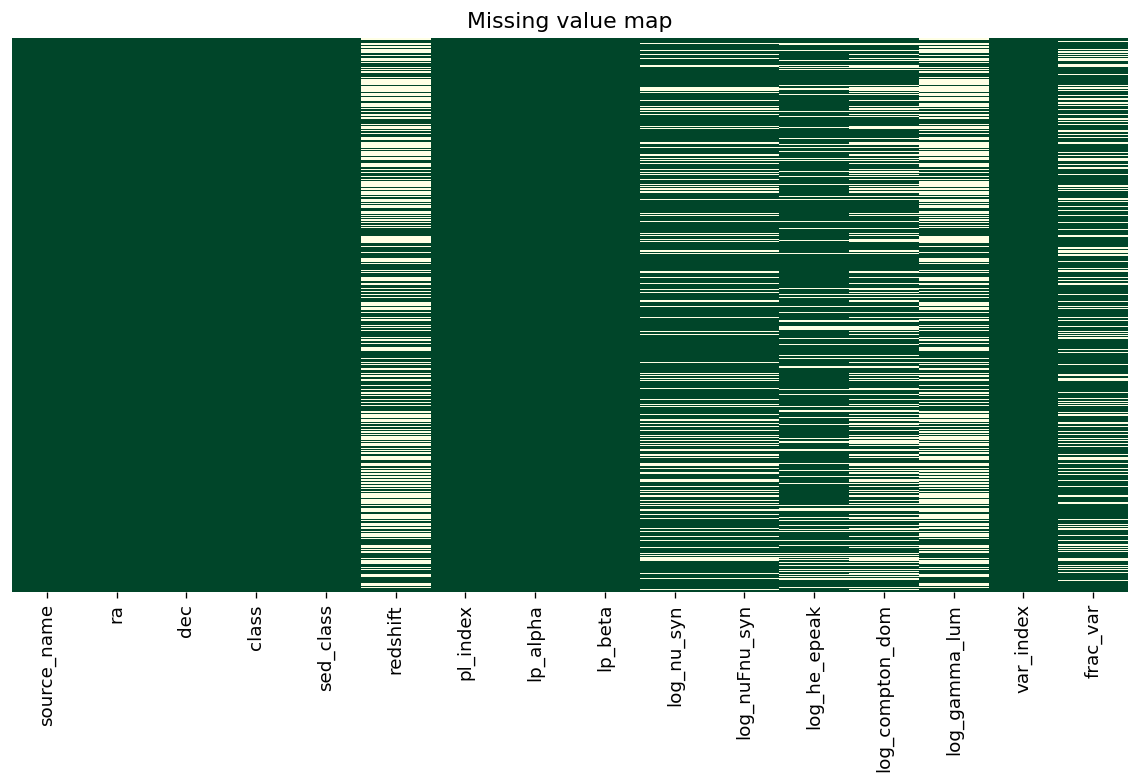

In [185]:
plt.figure(figsize=(12, 6))
sns.heatmap(lac_df.isna(), cbar=False, yticklabels=False, cmap="YlGn_r")
plt.title("Missing value map")
plt.show()

  class  complete_frac     n  incomplete_frac
0   bll       0.325598  1379         0.674402
1  fsrq       0.781457   755         0.218543
2   bcu       0.055464  1208         0.944536


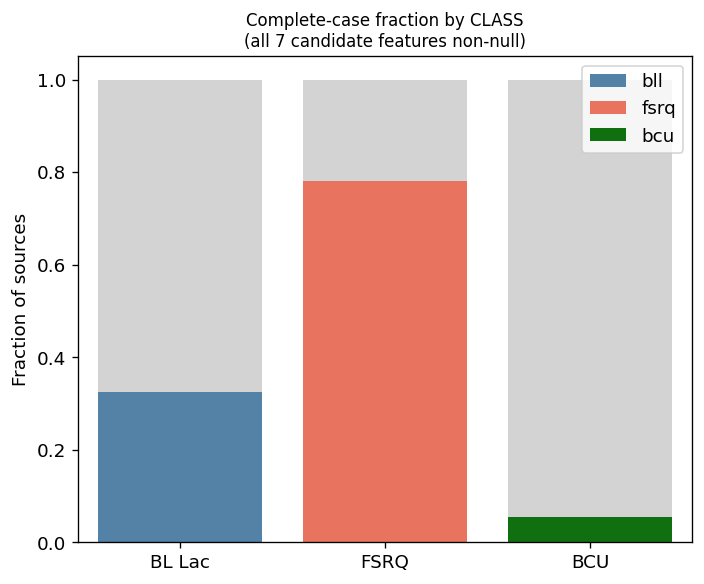

In [186]:
miss_feats = [
    "log_nu_syn",
    "log_nuFnu_syn",
    "log_compton_dom",
    "log_gamma_lum",
    "frac_var",
    "redshift",
    "var_index",
]

class_complete = (
    lac_df.assign(_complete=lac_df[miss_feats].notna().all(axis=1))
    .groupby("class")["_complete"]
    .agg(complete_frac="mean", n="count")
    .reindex(["bll", "fsrq", "bcu"])
    .assign(incomplete_frac=lambda d: 1 - d["complete_frac"])
    .reset_index()
)

print(class_complete)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=class_complete,
    x="class",
    y="complete_frac",
    hue="class",
    palette=CLASS_COLORS,
    legend=True,
    ax=ax,
)
sns.barplot(
    data=class_complete,
    x="class",
    y="incomplete_frac",
    bottom=class_complete["complete_frac"].values,
    color="lightgray",
    ax=ax,
)
ax.set_xticklabels(["BL Lac", "FSRQ", "BCU"])
ax.set_xlabel("")
ax.set_ylabel("Fraction of sources")
ax.set_title(
    r"Complete-case fraction by CLASS" + "\n" r"(all 7 candidate features non-null)",
    fontsize=10,
)

plt.tight_layout()
plt.show()

  sed_class  complete_frac     n  incomplete_frac
0       lsp       0.514066  1564         0.485934
1       isp       0.299029   515         0.700971
2       hsp       0.319419   551         0.680581
3      none       0.000000   777         1.000000


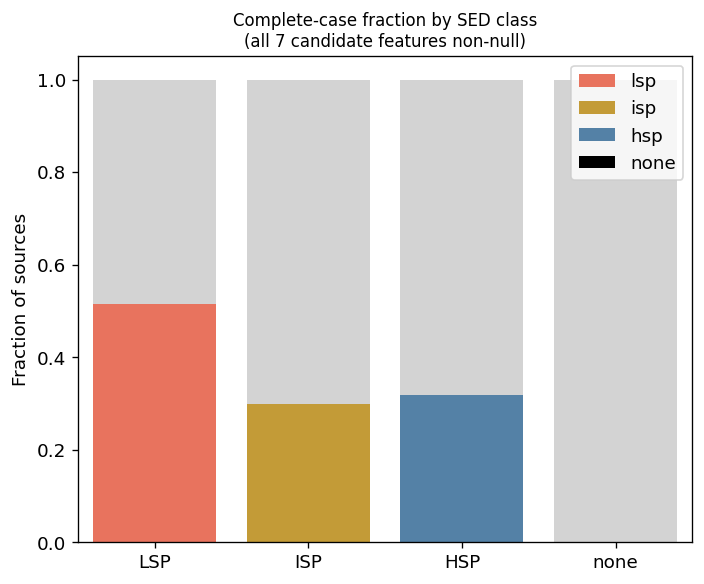

In [187]:
sed_complete = (
    lac_df.assign(_complete=lac_df[miss_feats].notna().all(axis=1))
    .groupby("sed_class")["_complete"]
    .agg(complete_frac="mean", n="count")
    .reindex(["lsp", "isp", "hsp", ""])
    .assign(incomplete_frac=lambda d: 1 - d["complete_frac"])
    .reset_index()
    .assign(sed_class=lambda d: d["sed_class"].replace("", "none"))
)

print(sed_complete)

sed_palette = {**SED_COLORS, "none": "black"}

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=sed_complete,
    x="sed_class",
    y="complete_frac",
    hue="sed_class",
    palette=sed_palette,
    legend=True,
    ax=ax,
)
sns.barplot(
    data=sed_complete,
    x="sed_class",
    y="incomplete_frac",
    bottom=sed_complete["complete_frac"].values,
    color="lightgray",
    ax=ax,
)
ax.set_xticklabels(["LSP", "ISP", "HSP", "none"])
ax.set_xlabel("")
ax.set_ylabel("Fraction of sources")
ax.set_title(
    r"Complete-case fraction by SED class" + "\n"
    r"(all 7 candidate features non-null)",
    fontsize=10,
)

plt.tight_layout()
plt.show()

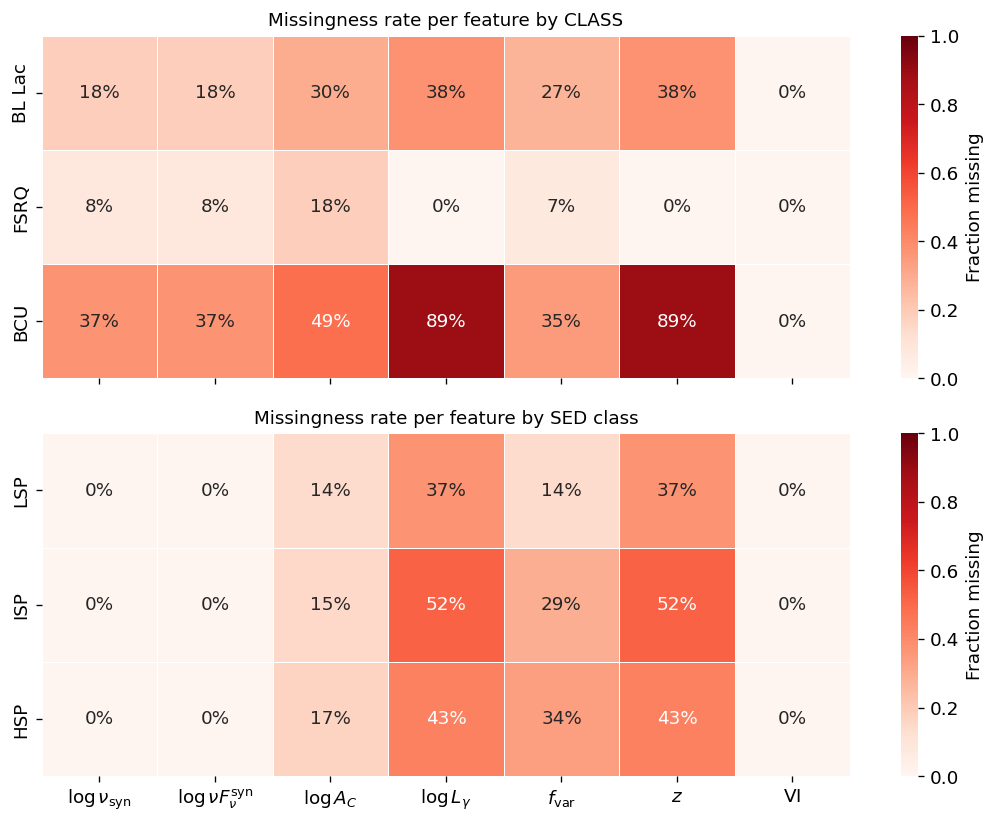

In [188]:
# Missingness by Class
miss_by_class = (
    lac_df.groupby("class")[miss_feats]
    .apply(lambda g: g.isna().mean())
    .reindex(["bll", "fsrq", "bcu"])
    .rename(
        columns={
            "log_nu_syn": r"$\log\nu_\mathrm{syn}$",
            "log_nuFnu_syn": r"$\log\nu F_\nu^\mathrm{syn}$",
            "log_compton_dom": r"$\log A_C$",
            "log_gamma_lum": r"$\log L_\gamma$",
            "frac_var": r"$f_\mathrm{var}$",
            "redshift": r"$z$",
            "var_index": r"$\mathrm{VI}$",
        }
    )
)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax = axes[0]
sns.heatmap(
    miss_by_class,
    vmin=0,
    vmax=1,
    cmap="Reds",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Fraction missing"},
    ax=ax,
)
ax.set_yticklabels(["BL Lac", "FSRQ", "BCU"])
ax.set_title("Missingness rate per feature by CLASS", fontsize=11)
ax.set_ylabel("")
# ax.set_xlabel("")


# Missingness by SED class
miss_by_sed = (
    lac_df.groupby("sed_class")[miss_feats]
    .apply(lambda g: g.isna().mean())
    .reindex(["lsp", "isp", "hsp"])
    .rename(
        columns={
            "log_nu_syn": r"$\log\nu_\mathrm{syn}$",
            "log_nuFnu_syn": r"$\log\nu F_\nu^\mathrm{syn}$",
            "log_compton_dom": r"$\log A_C$",
            "log_gamma_lum": r"$\log L_\gamma$",
            "frac_var": r"$f_\mathrm{var}$",
            "redshift": r"$z$",
            "var_index": r"$\mathrm{VI}$",
        }
    )
)

ax = axes[1]
sns.heatmap(
    miss_by_sed,
    vmin=0,
    vmax=1,
    cmap="Reds",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Fraction missing"},
    ax=ax,
)
ax.set_yticklabels(["LSP", "ISP", "HSP"])
ax.set_title("Missingness rate per feature by SED class", fontsize=11)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Missing data in the 4LAC-DR3 catalog is not random. SED peak parameters ($\nu_{\rm syn}$, $\nu F_{\nu}^{\rm syn}$, $\nu_{\rm IC}^{\rm peak}$, $\nu F_{\nu}^{\rm IC}$) are reported only for sources where a multi-wavelength SED fit converged with sufficient signal-to-noise. The missingness audit covers all seven candidate features before any selection decision is made.

The completeness plots confirm the expected structure. Among CLASS groups, FSRQs have the highest complete-case fraction: FSRQs are radio-bright, well-monitored, and their broad-line emission provides unambiguous flux-peak localization. BL Lacs show intermediate completeness. BCUs have the lowest completeness, consistent with their definition as blazar candidates whose SED characterization is insufficient for optical classification.

Among SED classes, LSP sources achieve the highest complete-case fraction. LSP blazars are dominated by FSRQs, which have spectroscopically confirmed redshifts from broad emission lines and well-characterized inverse Compton peaks in the Fermi-LAT band. HSP sources are almost exclusively BL Lacs, which lack broad emission lines, i.e., their redshifts are frequently unknown. Sources with no SED classification are 0% complete by construction: a missing $\nu_{\rm syn}$ measurement is what prevents SED class assignment in the first place.

The missingness heatmap quantifies the per-class rate for each feature individually. Redshift missingness is highest for BL Lacs, which lack the broad emission lines used for spectroscopic redshift measurement. The Variability Index (VI) is a native catalog quantity computed for all detected sources and carries negligible missingness across all classes.

## 7. Exploratory Data Analysis

The EDA has two goals:

1. Understand the marginal distributions of each feature: whether they are symmetric or skewed, whether BLL and FSRQ populations overlap or separate, and whether any feature has pathological concentration near a boundary value.
2. Map the correlation structure to identify redundant features before the dimensionality reduction step.

Redundant features inflate the effective weight of correlated groups in PCA and can produce spurious principal components that reflect shared measurement noise rather than independent physical dimensions.

We will restrict our analysis to confirmed blazars, i.e., BL Lacs and FSRQs with complete feature vectors. Including BCUs would bias the distributions because BCU sources are the class with the least number of complete cases of the catalog, as established in the missingness audit.

In [189]:
print(lac_df.info())
lac_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3407 entries, 0 to 3406
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_name      3407 non-null   str    
 1   ra               3407 non-null   float64
 2   dec              3407 non-null   float64
 3   class            3407 non-null   str    
 4   sed_class        3407 non-null   str    
 5   redshift         1806 non-null   float64
 6   pl_index         3407 non-null   float64
 7   lp_alpha         3407 non-null   float64
 8   lp_beta          3407 non-null   float64
 9   log_nu_syn       2630 non-null   float64
 10  log_nuFnu_syn    2630 non-null   float64
 11  log_he_epeak     2889 non-null   float64
 12  log_compton_dom  2247 non-null   float64
 13  log_gamma_lum    1806 non-null   float64
 14  var_index        3407 non-null   float64
 15  frac_var         2533 non-null   float64
dtypes: float64(13), str(3)
memory usage: 426.0 KB
None


,ra,dec,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var
count,3407.000000,3407.000000,1806.000000,3407.000000,3407.000000,3407.000000,2630.000000,2630.000000,2889.000000,2247.000000,1806.000000,3407.000000,2533.000000
mean,173.944827,3.230552,0.764666,2.212827,2.123670,0.141304,13.922084,-11.940065,2.966305,0.005354,45.642518,239.064871,0.550353
std,103.499049,39.454128,0.655205,0.297745,0.357863,0.186105,1.329748,0.498905,1.181154,0.500373,1.305312,2247.250923,0.342690
min,0.312600,-86.307800,0.000017,1.418864,-0.048980,-0.116156,11.325000,-13.442121,-1.337828,-2.003262,36.049629,1.600064,0.013834
25%,83.247700,-26.248549,0.266000,1.986413,1.883922,0.039538,12.860000,-12.300484,2.254835,-0.331850,44.802677,12.564138,0.310569
50%,174.218597,2.878500,0.560000,2.207268,2.126640,0.092379,13.578500,-11.985512,2.969566,-0.042184,45.680856,20.184406,0.478118
75%,253.739197,34.409899,1.120000,2.431613,2.372675,0.168965,14.720000,-11.637932,3.787908,0.327857,46.628683,50.009445,0.715342
max,359.990814,88.737602,4.313000,3.152549,3.204185,0.999995,20.255000,-9.106307,8.047229,2.322742,48.711938,84340.757812,2.910003


### Categorical features

In [190]:
for cat in lac_df.select_dtypes(include=str).columns:
    if cat not in ["source_name", "mojave_id"]:
        print(lac_df[cat].value_counts())
        print("-" * 30)

class
bll      1379
bcu      1208
fsrq      755
rdg        42
nlsy1       8
agn         7
css         5
ssrq        2
sey         1
Name: count, dtype: int64
------------------------------
sed_class
lsp    1564
        777
hsp     551
isp     515
Name: count, dtype: int64
------------------------------


### Feature Distributions

The distribution plots serve as a visual feature importance ranking. Features with well-separated BLL and FSRQ distributions contribute strongly to class structure; features with heavily overlapping distributions add variance with little discriminating power.

Key expectations:

- `log_nu_syn` should be bimodal within BL Lacs (LSP vs. HSP) and concentrated at low values for FSRQs. It is the most direct single-feature expression of the blazar sequence.
- `log_compton_dom` ($\log A_C$) should show BL Lacs near $A_C \approx 1$ and FSRQs at $A_C \gg 1$, reflecting the SSC-to-EC transition.
- `pl_index` should show FSRQs with softer (higher) $\gamma$-ray spectral indices, shaped by the external Compton cutoff and BLR absorption.
- `var_index` is right-skewed. FSRQs are on average more variable on *Fermi*-LAT year-timescales, but both classes span a wide dynamic range.
- `lp_alpha` and `lp_beta` measure spectral curvature in the $\gamma$-ray band; HSP BL Lacs have more curved spectra because their IC peak falls near or inside the LAT bandpass.

Features whose BLL and FSRQ distributions are indistinguishable carry no discriminating information and will be automatically downweighted in PCA.

In [191]:
dist_feats = lac_df.select_dtypes(include=float).columns.to_list()
dist_feats.remove("ra")
dist_feats.remove("dec")

plot_df = lac_df[lac_df["class"].isin(["bll", "fsrq"])][dist_feats + ["class"]].dropna()

print(f"Distribution Features:\n  {dist_feats}")
print(
    f"Complete cases:\n  BLL: {(plot_df['class']=='bll').sum()}\n  FSRQ: {(plot_df['class']=='fsrq').sum()}"
)

Distribution Features:
  ['redshift', 'pl_index', 'lp_alpha', 'lp_beta', 'log_nu_syn', 'log_nuFnu_syn', 'log_he_epeak', 'log_compton_dom', 'log_gamma_lum', 'var_index', 'frac_var']
Complete cases:
  BLL: 449
  FSRQ: 590


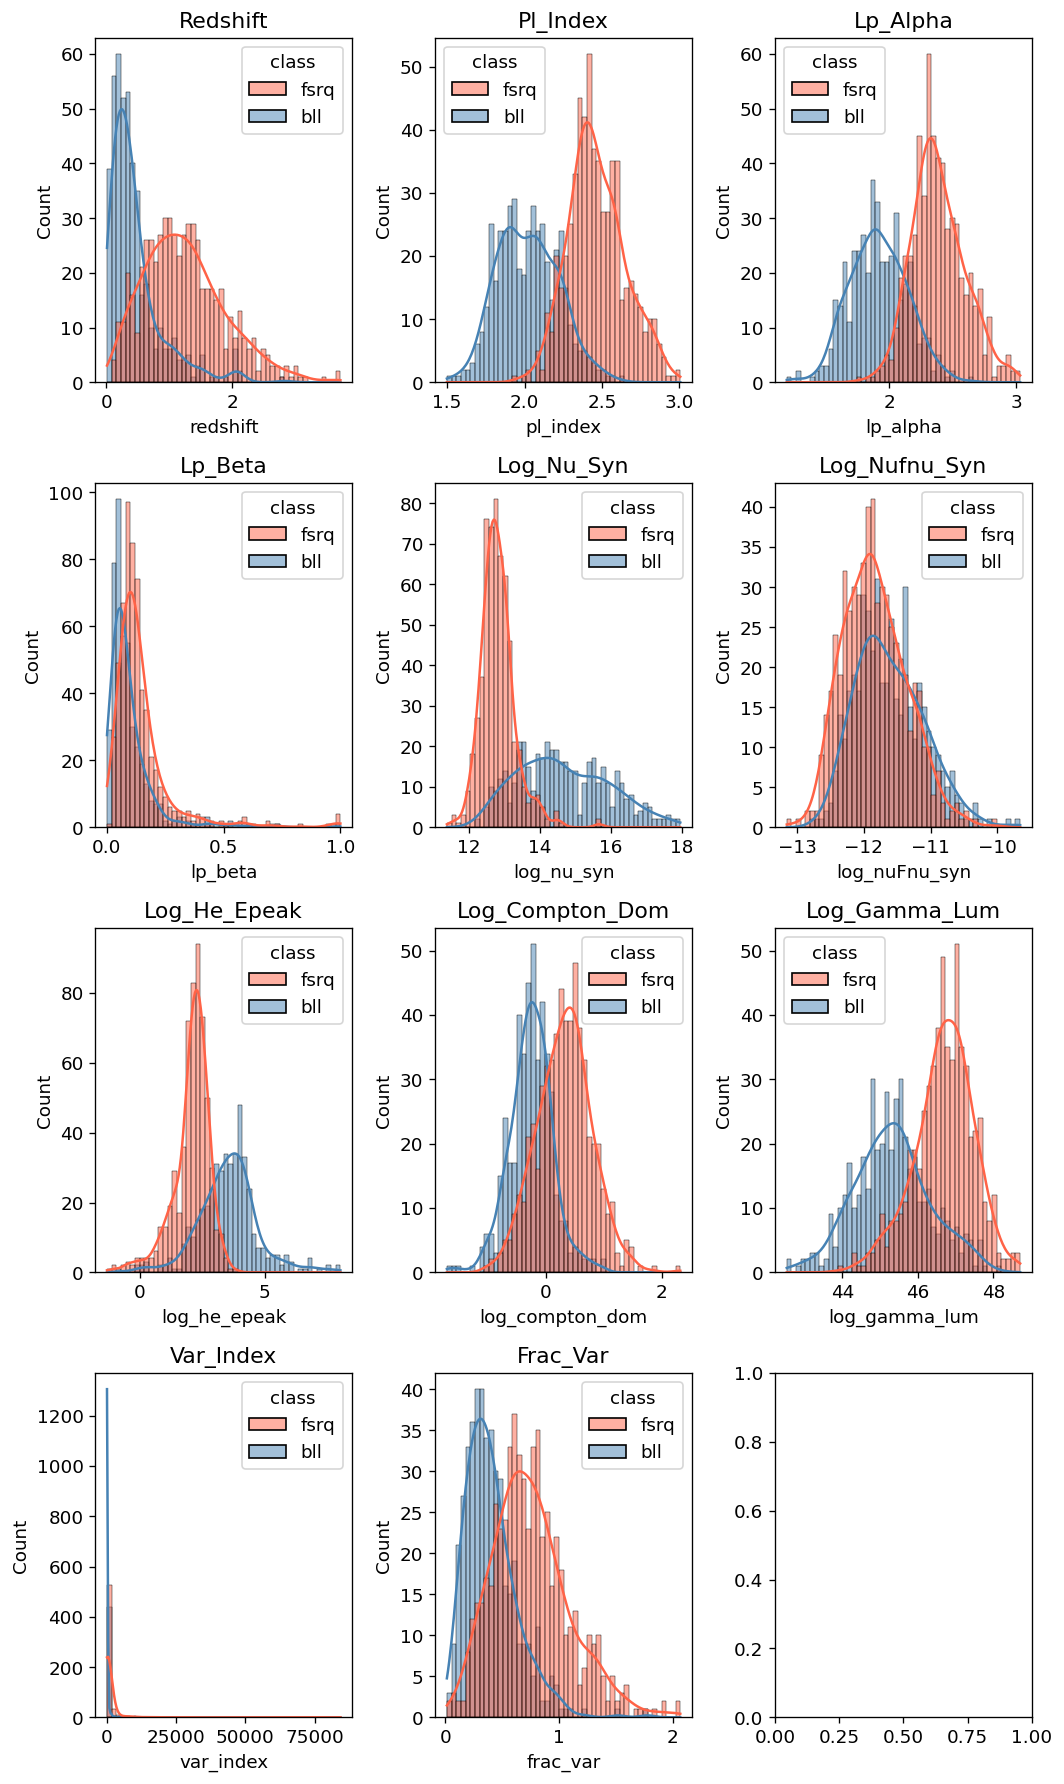

In [192]:
# Plotting distributions
fig, axes = plt.subplots(4, 3, figsize=(9, 15))

i = 0
j = 0
for cat in dist_feats:
    sns.histplot(
        data=plot_df,
        kde=True,
        x=cat,
        hue="class",
        bins=50,
        palette=CLASS_COLORS,
        color="steelblue",
        ax=axes[i, j],
    )
    axes[i, j].set_title(f"{cat.title()}")

    if j >= 2:
        j = 0
        i += 1
    else:
        j += 1
plt.tight_layout()
plt.show()

### Features Correlation

We explore the correlation structure of the feature set to identify redundant pairs before dimensionality reduction. Redundant features inflate the effective weight of correlated groups in PCA and can produce spurious principal components that reflect shared measurement noise rather than independent physical dimensions.

We compute correlations on the complete confirmed-blazar sample first, then break them down by class separately. A correlation that appears in the pooled sample but disappears within each class is driven by class membership, not by a physical relationship internal to either population.

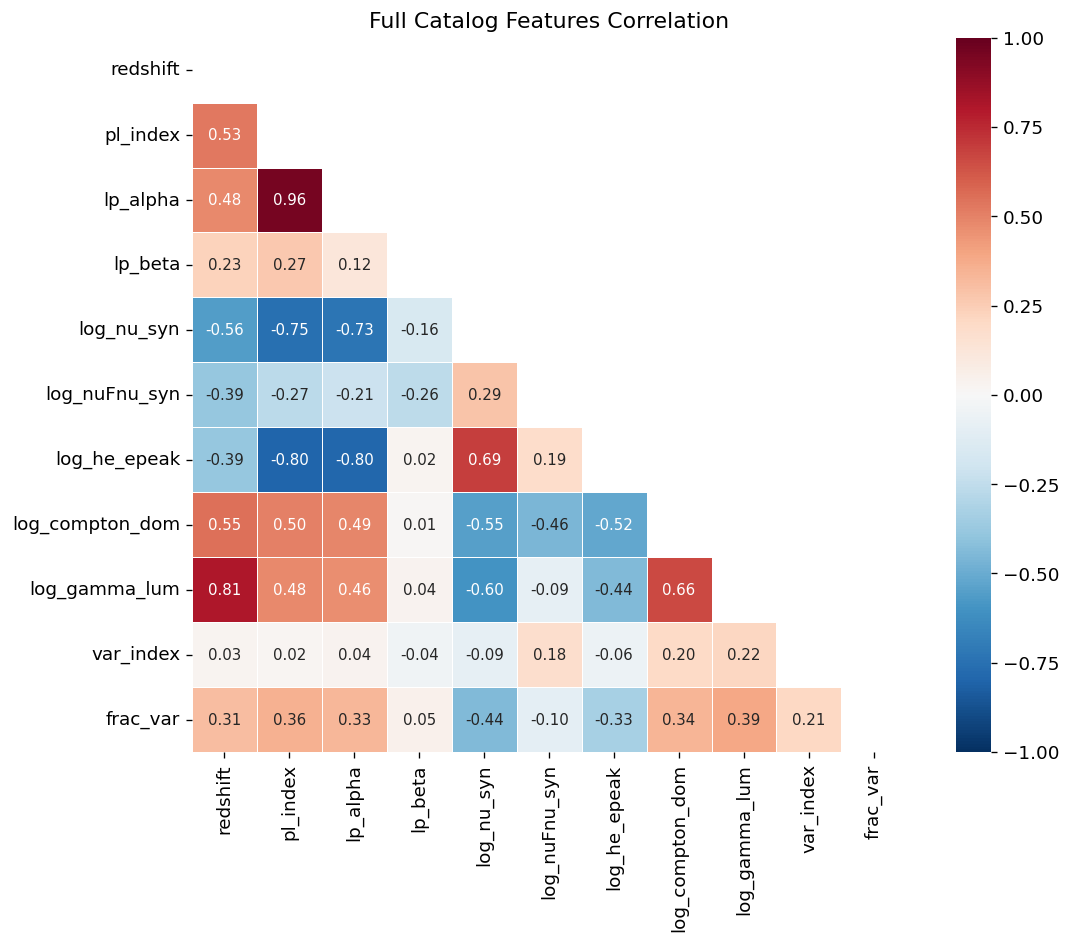

In [193]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = plot_df.corr(numeric_only=True)
corr_abs = corr.abs()
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_mask = corr_abs.mask(mask)

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    square=True,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)

ax.set_title("Full Catalog Features Correlation")

plt.tight_layout()
plt.show()

We will compare Pearson and Spearman correlations because `var_index` and `frac_var` have right-skewed distributions. The comparison will identify which pairwise relationships are driven by extreme values rather than the bulk of the distribution.

**Note:** Pearson assumes linearity and is sensitive to outliers in the tails; Spearman rank correlation is more robust.

Also, we will calculate per-class correlation for BL Lacs and FSRQs, separately. Each class spans different physical regimes, so some correlations in the pooled sample are between-class effects rather than within-class physical relationships.

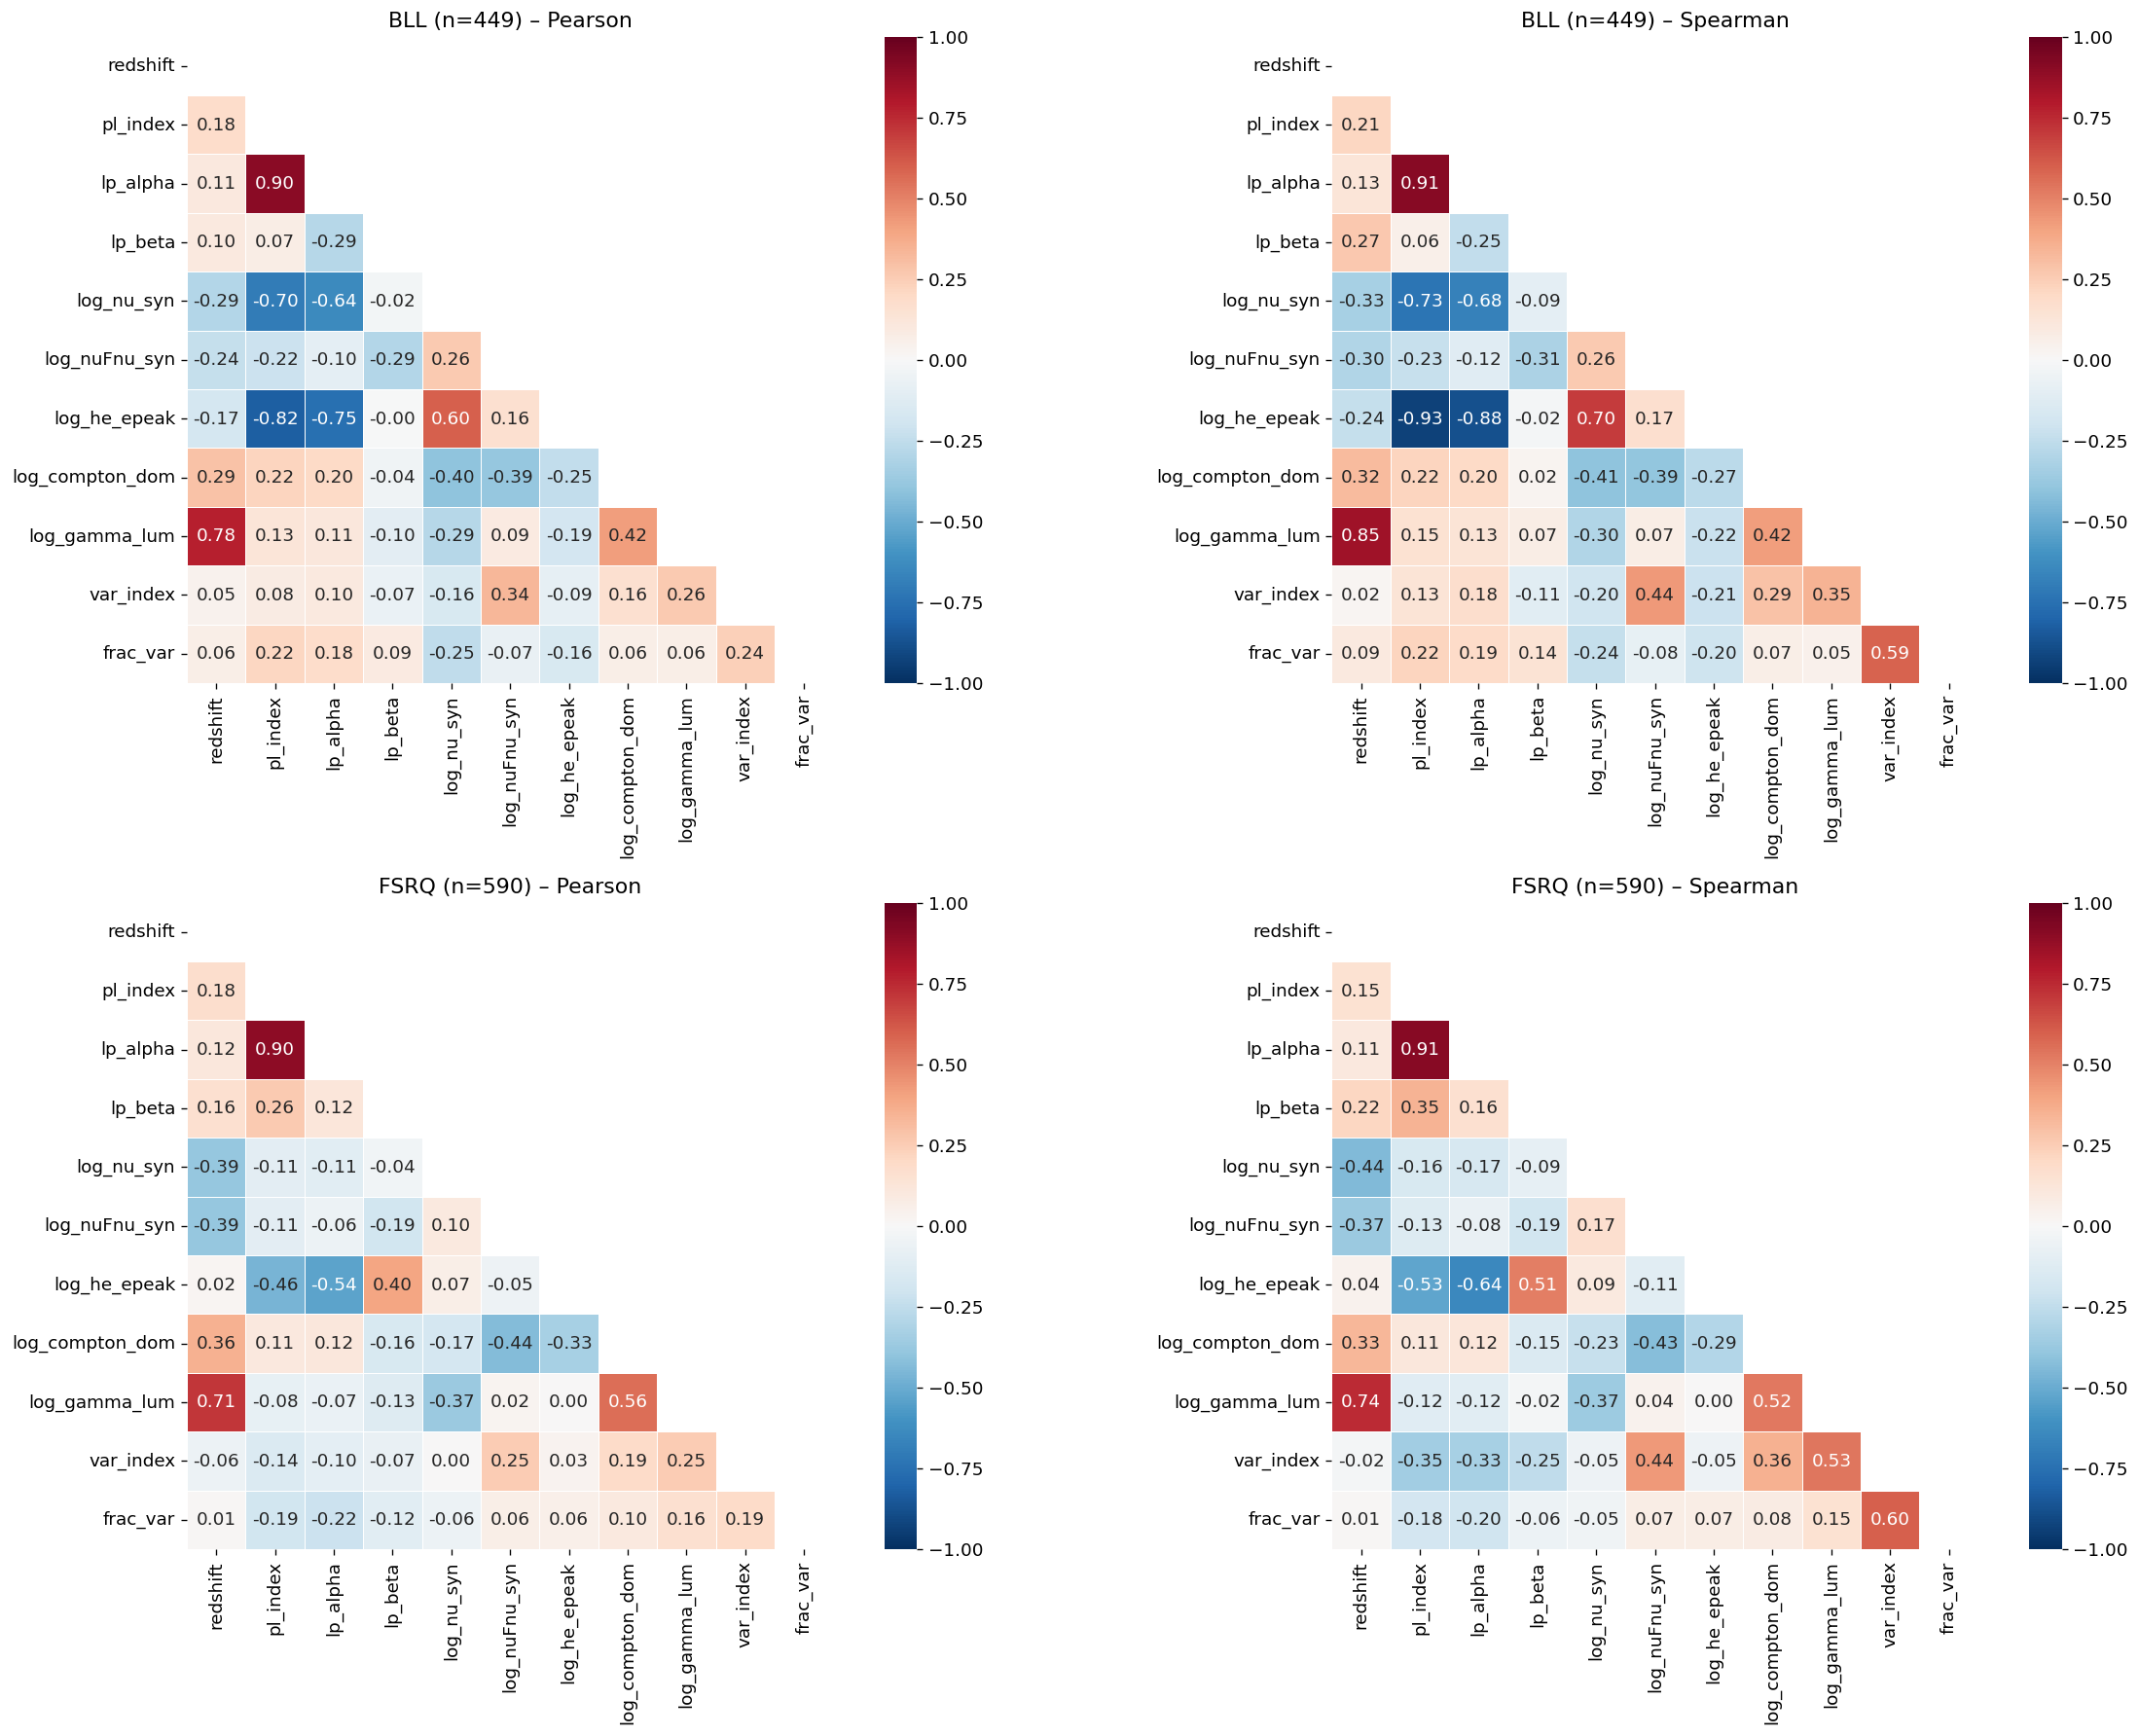

In [194]:
fig, ax = plt.subplots(2, 2, figsize=(20, 15))

i = 0
for cls in ["bll", "fsrq"]:
    sub = plot_df[plot_df["class"] == cls][dist_feats].dropna()

    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax[i][0],
    )
    ax[i][0].set_title(f"{cls.upper()} (n={len(sub)}) – Pearson")

    corr = sub.corr(method="spearman")
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax[i][1],
    )
    ax[i][1].set_title(f"{cls.upper()} (n={len(sub)}) – Spearman")

    i += 1

plt.tight_layout()
plt.show()

The Pearson and Spearman matrices agree for roughly normal features (`pl_index`, `lp_alpha`, `log_nu_syn`, `log_compton_dom`). The largest differences appear for `var_index` and `frac_var`, consistent with their right-skewed distributions. Spearman ranks are more reliable for these two features. Of the two, we will consider `var_index` only for the PCA analysis because `frac_var` has 26% missingness.

The physically expected signature is the anti-correlation between `log_nu_syn` and `log_compton_dom` (the blazar sequence in correlation form). If $|r| > 0.7$, this pair will dominate the first principal component in PCA.

On the other hand, correlations computed separately for BL Lacs and FSRQs reveal which structure is within-class and which is between-class. A high correlation in the pooled sample that weakens within each class is a between-class effect, driven by the BL Lac/FSRQ separation rather than by a physical relationship internal to either population, e.g., `log_gamma_lum` or `pl_index`.

### BLL vs FSRQ: Pairplot

Pairplots are useful to compare each variable distribution alongside scatter plots for every pair of variables to overview all pairwise relationships.

The most diagnostically useful panel is `log_nu_syn` vs. `log_compton_dom`, the so-called blazar sequence. If BL Lac and FSRQ sources form two separated clouds in this projection, the blazar sequence manifests as bimodal structure in feature space. Substantial overlap would instead indicate a continuous unimodal population where the BL Lac/FSRQ classification reflects observational thresholds rather than distinct physics.

The variability features (`var_index`) are expected to show the most overlap: variability is a function of jet orientation and activity state as much as of blazar type, and both classes span a wide dynamic range.

Pair-plot features:
  ['lp_beta', 'log_nu_syn', 'log_nuFnu_syn', 'log_he_epeak', 'log_compton_dom', 'log_gamma_lum', 'var_index', 'frac_var']


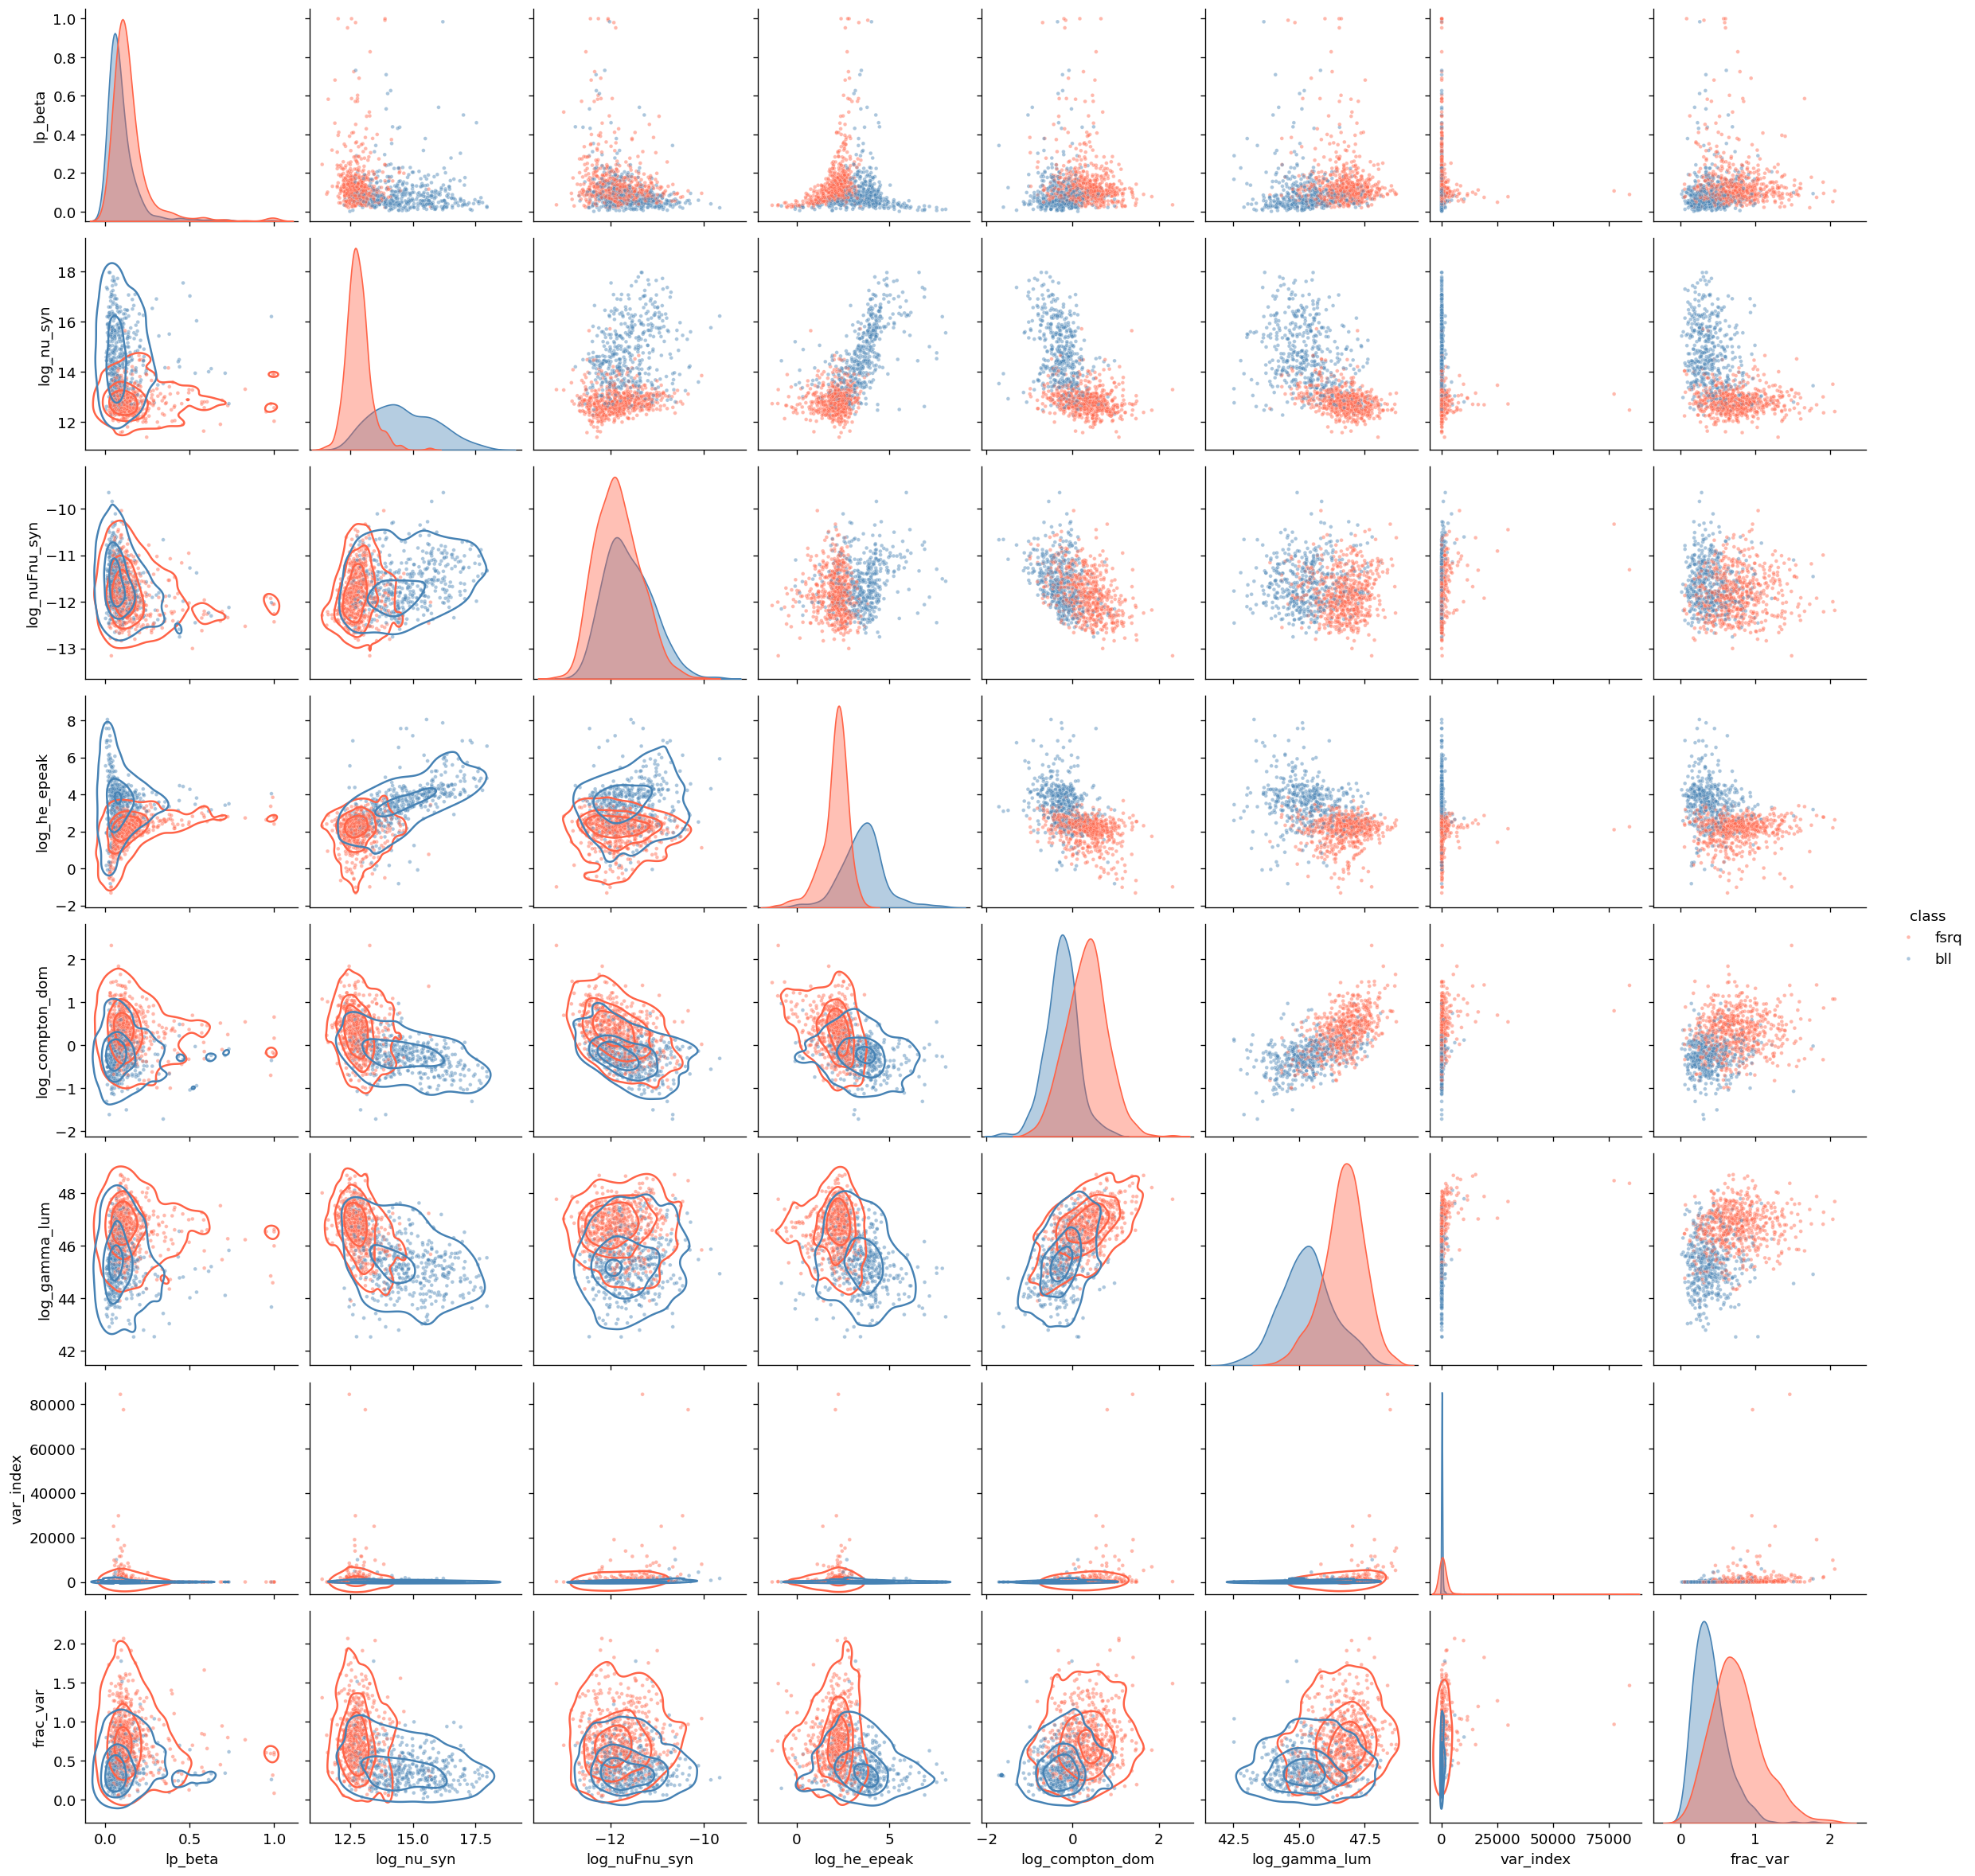

In [195]:
# Selecting low correlation features
pair_feats = [c for c in corr_mask.columns if not any(corr_mask[c] > 0.7)]
print(f"Pair-plot features:\n  {pair_feats}")

g = sns.pairplot(
    data=plot_df[pair_feats + ["class"]],
    hue="class",
    vars=pair_feats,
    palette=CLASS_COLORS,
    diag_kind="kde",
    plot_kws={"alpha": 0.45, "s": 8, "rasterized": True},
    diag_kws={"fill": True, "alpha": 0.4},
)
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show()

### Blazar Sequence

The blazar sequence is shown as $\log A_C$ vs. $\log \nu_{\rm syn}$, the canonical two-dimensional representation of the anti-correlation first reported by Fossati et al. (1998) and Donato et al. (2001), Finke (2013) solidified the concept with a larger sample. The blazar sequence states that sources with higher synchrotron peak frequency systematically have lower $A_C$, and vice versa. In Rueda-Becerril, Harrison & Giannios (2021), this anti-correlation is reproduced by simulations with constant baryon loading $50 \lesssim \mu \lesssim 80$ and varying accretion rate $\dot{m}$.

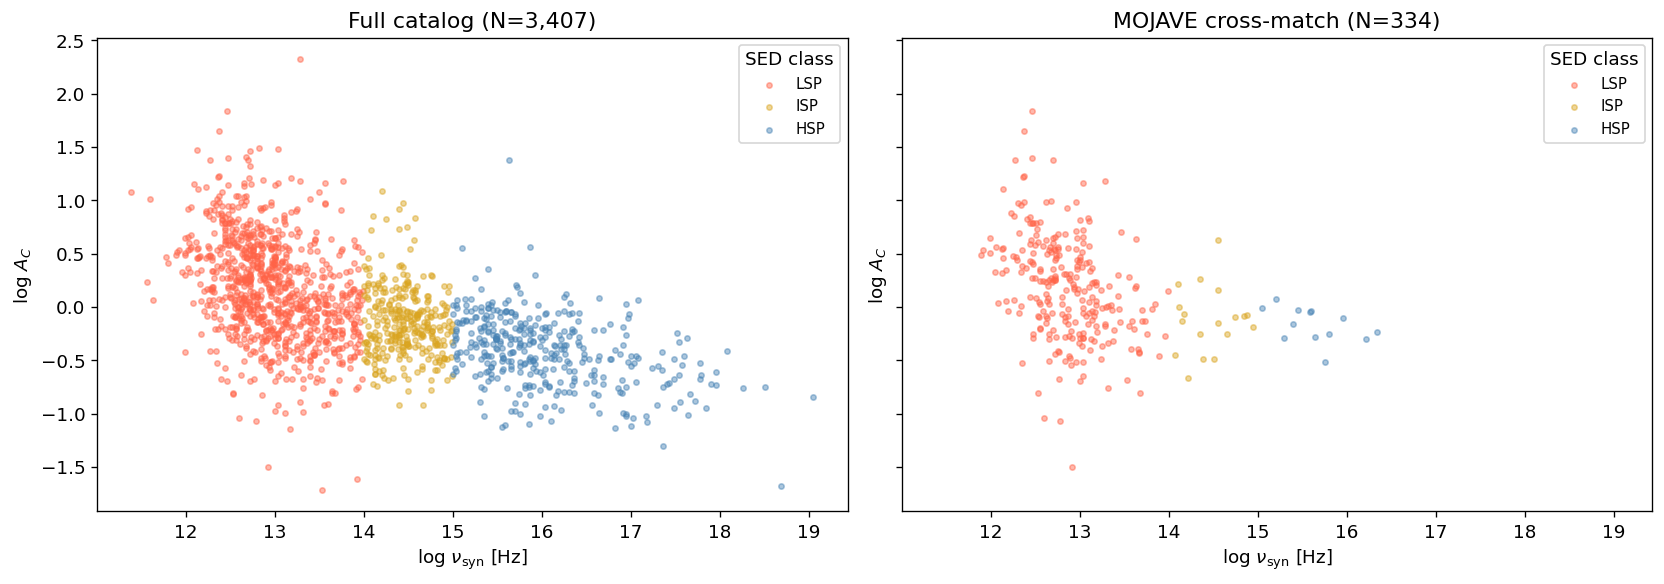

In [196]:
sed_order = ["lsp", "isp", "hsp"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, (df, title) in zip(
    axes,
    [
        (lac_df[lac_df["class"].isin(["bll", "fsrq"])], "Full catalog (N=3,407)"),
        (
            matched_df[matched_df["class"].isin(["bll", "fsrq"])],
            "MOJAVE cross-match (N=334)",
        ),
    ],
):
    sub = df[["log_nu_syn", "log_compton_dom", "sed_class"]].dropna()
    for sed in sed_order:
        mask = sub["sed_class"] == sed
        ax.scatter(
            sub.loc[mask, "log_nu_syn"],
            sub.loc[mask, "log_compton_dom"],
            c=SED_COLORS[sed],
            label=sed.upper(),
            alpha=0.45,
            s=10,
            rasterized=True,
        )
    ax.set_xlabel(r"$\log\,\nu_{\rm syn}$ [Hz]")
    ax.set_ylabel(r"$\log\,A_C$")
    ax.set_title(title)
    ax.legend(title="SED class", fontsize=9)

plt.tight_layout()
plt.show()

In this plot we can qualitatively confirm an anti-correlation is present in this dataset before any dimensionality reduction, providing a sanity check on the feature derivation. We can also confirm that the three subclasses, i.e., LSP, ISP and HSP form a continuous sequence.

Comparing the full 4LAC-DR3 (left panel) with the MOJAVE cross-match (right panel) makes the selection bias explicit: MOJAVE sources are concentrated at low $\nu_{\rm syn}$ and high $A_C$ (LSP FSRQs), as expected from the radio-brightness selection.

Our hypothesis here is: if the blazar sequence is the dominant source of variance, PCA should recover it as PC1 with opposite-sign loadings on `log_nu_syn` and `log_compton_dom`.

## 8. Dimensionality Reduction & Clustering

We want to address two questions in this section:

1. whether the blazar population is continuous or bimodal, and
2. where BCU sources sit relative to confirmed BL Lacs and FSRQs.

No single method resolves both. For instance, PCA establishes the linear variance structure while UMAP reveals nonlinear topology and provides the embedding for density-based clustering, and GMM assigns probabilistic memberships while HDBSCAN validates the density structure without parametric assumptions.

We will explore these methods to gain enough intuition about our data.

### 8.1 PCA

PCA finds the linear combinations of the input features that capture the most variance. The output is directly interpretable: each principal component loading vector maps back to physical observables, and the scree plot quantifies how many independent dimensions the data actually occupies.

#### Feature Selection

The audit above leads directly to three exclusion decisions. In the first place, `redshift` and `log_gamma_lum` are excluded because both carry ~47% missingness, and applying a complete-case filter on either would discard nearly half the catalog before clustering begins. Second, `frac_var` is excluded at 26% missingness. The original Variability Index (`var_index`) covers the same physical dimension as `frac_var` with effectively zero missing data and is retained instead.

The three SED peak features (`log_nu_syn`, `log_nuFnu_syn`, `log_compton_dom`) are retained despite 23–34% missingness because they are the primary physical observables. Excluding them entirely would undermine the scientific purpose of the analysis.

The retained feature set for PCA is therefore: `pl_index`, `lp_alpha`, `lp_beta`, `log_nu_syn`, `log_nuFnu_syn`, `log_compton_dom`, and `var_index`.

#### Analysis

The key test is the first principal component. If PC1 loads with opposite signs on `log_nu_syn` and `log_compton_dom`, it recovers the blazar sequence as a data-driven axis, independent of class labels. If it does not, that is a meaningful result about the feature space.

PCA is the appropriate first step precisely because it is linear. Its inability to capture curved manifolds is also its virtue at this stage. Any structure PCA cannot explain is a clean motivation for UMAP.

Complete cases: 2207 / 3407 (64.8%)
  BL Lac: 970
  FSRQ: 616
  BCU: 621


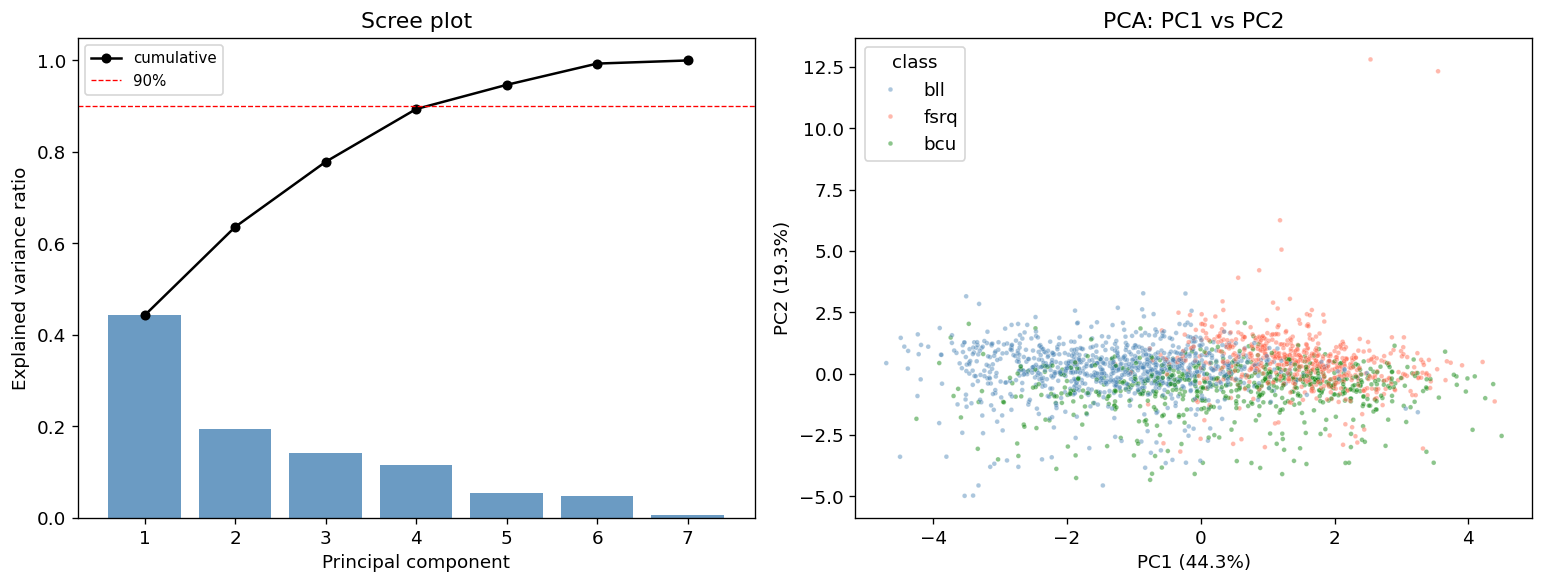

In [197]:
pca_feats = [
    "pl_index",
    "lp_alpha",
    "lp_beta",
    "log_nu_syn",
    "log_nuFnu_syn",
    "log_compton_dom",
    "var_index",
]

pca_mask = lac_df[pca_feats].notna().all(axis=1) & lac_df["class"].isin(
    ["bll", "fsrq", "bcu"]
)
pca_df = lac_df[pca_mask].copy().reset_index(drop=True)
print(f"Complete cases: {pca_mask.sum()} / {len(lac_df)} ({100*pca_mask.mean():.1f}%)")
print(
    f"  BL Lac: {(pca_df['class']=='bll').sum()}\n"
    f"  FSRQ: {(pca_df['class']=='fsrq').sum()}\n"
    f"  BCU: {(pca_df['class']=='bcu').sum()}"
)

scaler = StandardScaler()
X = scaler.fit_transform(pca_df[pca_feats])

pca = PCA()
Z_pca = pca.fit_transform(X)
pca_df["PC1"] = Z_pca[:, 0]
pca_df["PC2"] = Z_pca[:, 1]

ev = pca.explained_variance_ratio_
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(pca_feats) + 1), ev, color="steelblue", alpha=0.8)
axes[0].plot(
    range(1, len(pca_feats) + 1), np.cumsum(ev), "ko-", ms=5, label="cumulative"
)
axes[0].axhline(0.9, ls="--", color="red", lw=0.8, label="90%")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")
axes[0].set_xticks(range(1, len(pca_feats) + 1))
axes[0].legend(fontsize=9)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="class",
    palette=CLASS_COLORS,
    alpha=0.45,
    s=8,
    rasterized=True,
    ax=axes[1],
)
axes[1].set_xlabel(f"PC1 ({ev[0] * 100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({ev[1] * 100:.1f}%)")
axes[1].set_title("PCA: PC1 vs PC2")

plt.tight_layout()
plt.show()

The scree plot quantifies how many independent variance dimensions the 7-feature space contains. The left panel shows that 4 components explain 89.4% of the variance and 5 components explain 94.7%, so the 90% threshold is reached at 5 components. The population therefore does not compress into a low-dimensional linear subspace, i.e., no single dominant axis carries the bulk of the variance. The blazar sequence, the $\gamma$-ray spectral shape, and variability represent genuinely independent physical dimensions in the data.

The PC1/PC2 scatter (right panel), colored by class, tests whether BL Lacs and FSRQs separate in the linear projection. Substantial overlap is visible, so PCA cannot resolve the two populations in any two-component view. This is not a failure of the method but a property of the data. A continuous distribution in feature space produces overlapping projections regardless of how many components are shown. It motivates the nonlinear embedding step UMAP, implemented in Section 8.2.

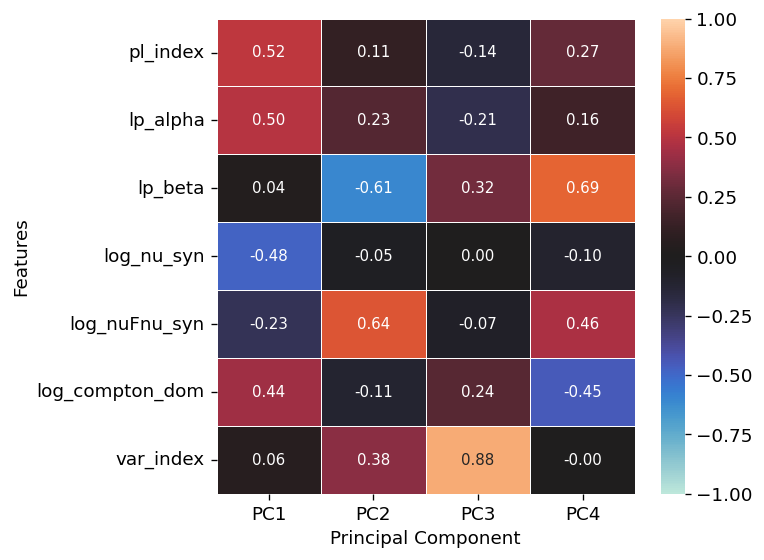

In [198]:
PCkeys = ["PC1", "PC2", "PC3", "PC4", "PC5"]
loadings = pd.DataFrame(pca.components_[:4].T, index=pca_feats, columns=PCkeys[:4])

sns.heatmap(
    loadings,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
)
plt.ylabel("Features")
plt.xlabel("Principal Component")
plt.tight_layout()
plt.show()

The loading heatmap shows the contribution of each original feature to each principal component. Only the pattern of signs within a component is physically meaningful; the overall sign of an eigenvector is arbitrary.

The key diagnostic is PC1. Opposite-sign loadings on `log_nu_syn` and `log_compton_dom` in PC1 recover the blazar sequence as a data-driven axis without class labels: sources with high synchrotron peak frequency score high on PC1 and sources with high Compton dominance score low, or vice versa. This is the  anti-correlation pattern that Fossati et al. (1998), Donato et al. (2001), and Finke (2013) predict. Verifying this against the heatmap we should find that the signs on these two features in PC1 are opposite, and therefore the blazar sequence is the dominant source of linear variance in the catalog.

However, we find that PC1 is instead dominated by spectral shape parameters `pl_index` and `lp_alpha`. This means that the $\gamma$-ray spectral curvature outweighs the SED peak structure as the primary variance axis. Both outcomes are scientifically informative.

### 8.2 UMAP

UMAP builds a fuzzy topological representation of the data using Riemannian geometry, then finds a low-dimensional layout that preserves it. Unlike PCA, it captures nonlinear manifold structure. Unlike t-SNE, it preserves global topology as well as local neighborhoods. In other words, sources that are far apart in feature space remain far apart in the embedding. This global preservation matters here because the question of whether BL Lacs and FSRQs form one connected population or two separated ones requires global, not just local, structure to be meaningful.

UMAP serves two roles in this analysis:

1. it is a visualization tool for inspecting the population geometry, and
2. it is the input space for HDBSCAN.

#### Parameter Selection

Two parameters control the embedding quality of a UMAP method and must be chosen with care, not left at defaults.

- `n_neighbors`: sets the size of the local neighborhood used to build the topological graph.
- `min_dist`: controls how tightly points are packed in the 2D layout.

Our approach is a stability sweep: run UMAP across a grid of parameter values and identify which features of the embedding are consistent across choices. Structure that appears regardless of parameter setting is a genuine topological feature of the data, whereas a structure that only appears at specific settings is an artifact of the projection.

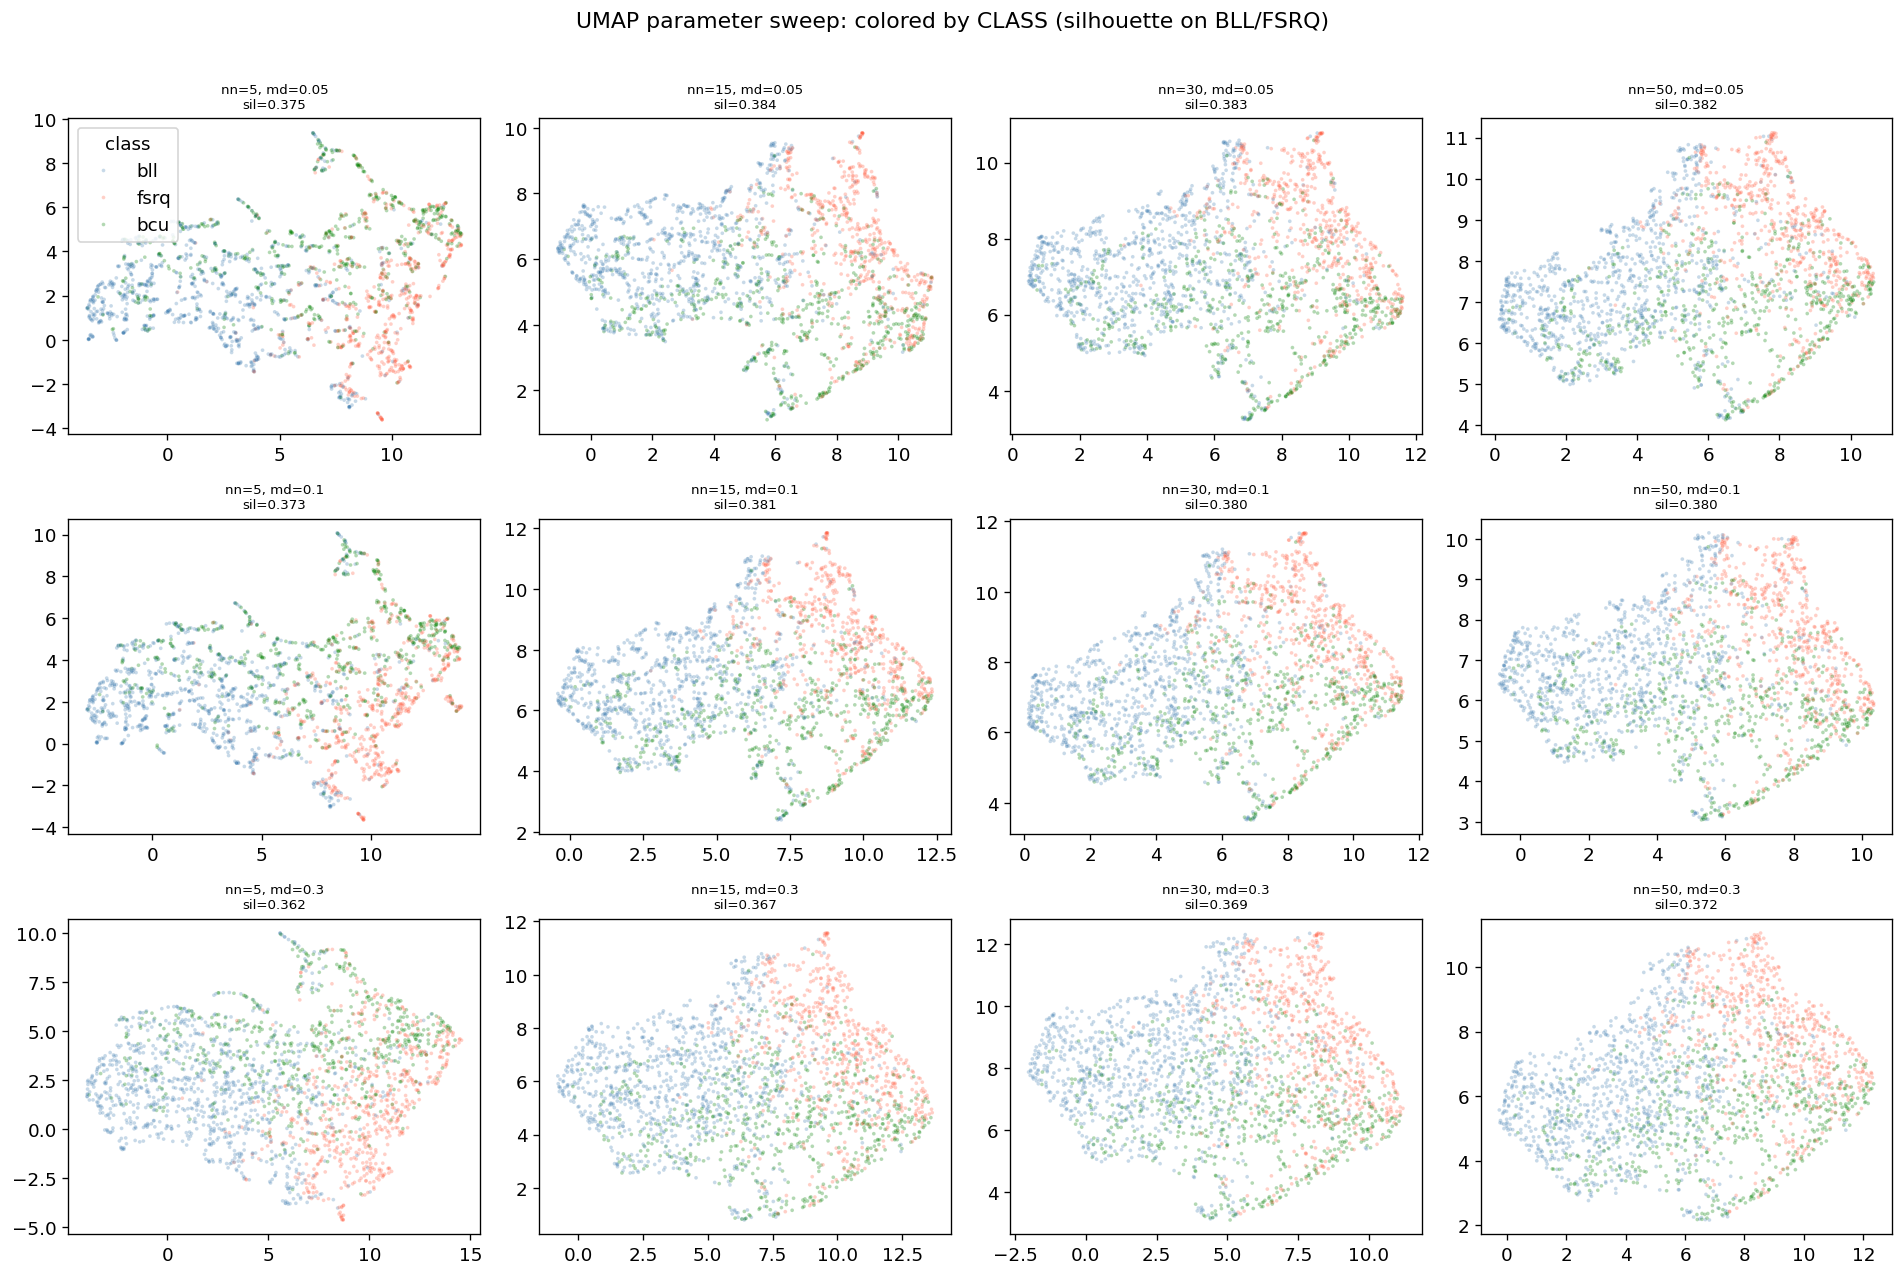

Best silhouette: n_neighbors=15, min_dist=0.05, score=0.384


In [199]:
nn_vals = [5, 15, 30, 50]
md_vals = [0.05, 0.1, 0.3]

sweep_results = {}
fig, axes = plt.subplots(
    len(md_vals), len(nn_vals), figsize=(4 * len(nn_vals), 3.5 * len(md_vals))
)

for row, md_val in enumerate(md_vals):
    for col, nn_val in enumerate(nn_vals):
        red = umap.UMAP(
            n_neighbors=nn_val, min_dist=md_val, n_components=2, random_state=42
        )
        emb = red.fit_transform(X)

        # Silhouette on confirmed blazars only (BLL vs FSRQ separation quality)
        confirmed = pca_df["class"].isin(["bll", "fsrq"]).values
        sil = silhouette_score(emb[confirmed], pca_df.loc[confirmed, "class"].values)
        sweep_results[(nn_val, md_val)] = {"embedding": emb, "silhouette": sil}

        tmp = pca_df[["class"]].copy()
        tmp["U1"], tmp["U2"] = emb[:, 0], emb[:, 1]
        sns.scatterplot(
            data=tmp,
            x="U1",
            y="U2",
            hue="class",
            palette=CLASS_COLORS,
            hue_order=["bll", "fsrq", "bcu"],
            alpha=0.3,
            s=5,
            rasterized=True,
            ax=axes[row, col],
            legend=(row == 0 and col == 0),
        )
        axes[row, col].set_title(f"nn={nn_val}, md={md_val}\nsil={sil:.3f}", fontsize=8)
        axes[row, col].set_xlabel("")
        axes[row, col].set_ylabel("")

fig.suptitle("UMAP parameter sweep: colored by CLASS (silhouette on BLL/FSRQ)", y=1.01)
plt.tight_layout()
plt.show()

# Report best parameters by silhouette score
best_params = max(sweep_results, key=lambda p: sweep_results[p]["silhouette"])
print(
    f"Best silhouette: n_neighbors={best_params[0]}, min_dist={best_params[1]}, "
    f"score={sweep_results[best_params]['silhouette']:.3f}"
)

The silhouette score measures BL Lac/FSRQ class separation quality in the embedding (higher is better). This score provides a quantitative basis for parameter selection rather than a purely visual judgment. The selected parameters should produce an embedding where BL Lac and FSRQ sources form clearly separated regions, BCU sources populate the transition zone, and the overall topology is stable relative to neighboring parameter settings. Parameters at which a small change in `n_neighbors` or `min_dist` dramatically reorganizes the layout should be treated as sensitive and avoided.

Looking at our grid of UMAP parameter sweep we can find that the best silhouette score corresponds to `min_dist` = 0.05. However, we need to run a more detailed exploration of parameter `n_neighbors` since values 5 and 15 show strong discrepancies.

We will explore small changes below 15 to confirm the value that should be used for `n_neighbors`.

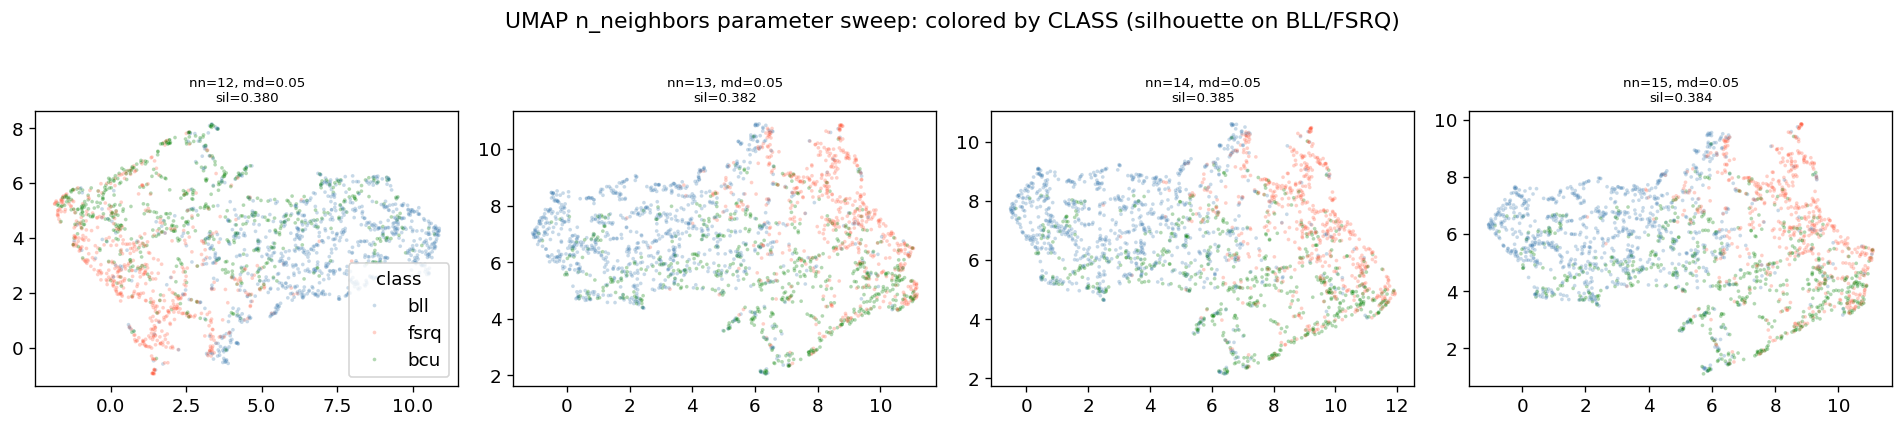

Best silhouette: n_neighbors=14, min_dist=0.05, score=0.385
14


In [200]:
nn_vals = [12, 13, 14, 15]

sweep_results = {}
fig, axes = plt.subplots(1, len(nn_vals), figsize=(4 * len(nn_vals), 3.5))

for col, nn_val in enumerate(nn_vals):
    red = umap.UMAP(n_neighbors=nn_val, min_dist=0.05, n_components=2, random_state=42)
    emb = red.fit_transform(X)

    # Silhouette on confirmed blazars only (BL Lacs vs FSRQs separation quality)
    confirmed = pca_df["class"].isin(["bll", "fsrq"]).values
    sil = silhouette_score(emb[confirmed], pca_df.loc[confirmed, "class"].values)
    sweep_results[nn_val] = {"embedding": emb, "silhouette": sil}

    tmp = pca_df[["class"]].copy()
    tmp["U1"], tmp["U2"] = emb[:, 0], emb[:, 1]
    sns.scatterplot(
        data=tmp,
        x="U1",
        y="U2",
        hue="class",
        palette=CLASS_COLORS,
        hue_order=["bll", "fsrq", "bcu"],
        alpha=0.3,
        s=5,
        rasterized=True,
        ax=axes[col],
        legend=(col == 0),
    )
    axes[col].set_title(f"nn={nn_val}, md={0.05}\nsil={sil:.3f}", fontsize=8)
    axes[col].set_xlabel("")
    axes[col].set_ylabel("")

fig.suptitle(
    "UMAP n_neighbors parameter sweep: colored by CLASS (silhouette on BLL/FSRQ)",
    y=1.01,
)
plt.tight_layout()
plt.show()

# Report best parameters by silhouette score
best_params = max(sweep_results, key=lambda p: sweep_results[p]["silhouette"])
print(
    f"Best silhouette: n_neighbors={best_params}, min_dist=0.05, "
    f"score={sweep_results[best_params]['silhouette']:.3f}"
)
print(best_params)

The above results confirm that `n_neighbors` = 15 is the best parameter. Even though 14 neighbors gives a better silhouette score, a slight change of two neighbors down throws a dramatically different organization. As we have mentioned before, if a small change in the parameters reorganizes the layout dramatically, then that value should be avoided.

**Final parameter values:**
- `n_neighbors`: 15
- `min_dist`: 0.05
- Silhouette score: 0.384

#### Analysis

We will proceed with the analysis with the selected parameters.

Selected: n_neighbors=15, min_dist=0.05


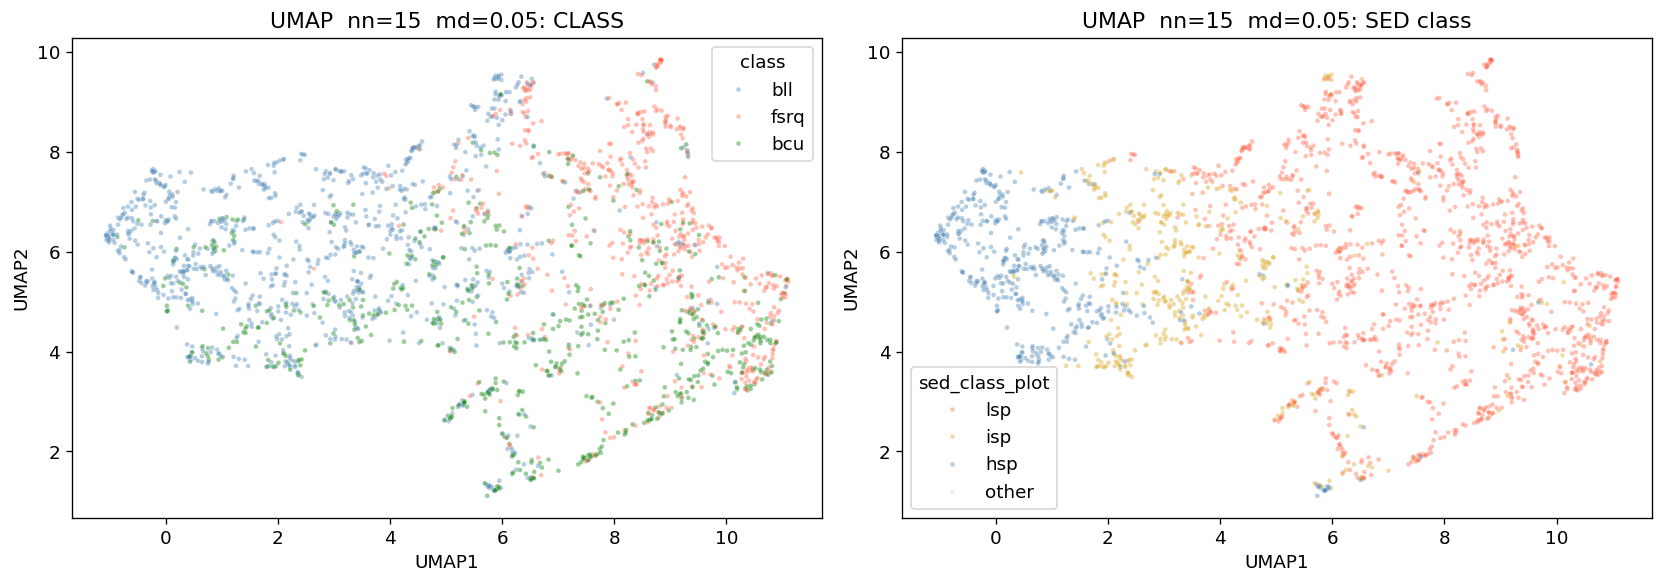

In [201]:
# Final UMAP with selected parameters
chosen_nn = 15
chosen_md = 0.05
print(f"Selected: n_neighbors={chosen_nn}, min_dist={chosen_md}")

reducer = umap.UMAP(
    n_neighbors=chosen_nn, min_dist=chosen_md, n_components=2, random_state=42
)
embedding = reducer.fit_transform(X)
pca_df["UMAP1"] = embedding[:, 0]
pca_df["UMAP2"] = embedding[:, 1]

pca_df["sed_class_plot"] = pca_df["sed_class"].where(
    pca_df["sed_class"].isin(SED_COLORS), other="other"
)
sed_palette = {**SED_COLORS, "other": "lightgray"}
sed_hue_order = ["lsp", "isp", "hsp", "other"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=pca_df,
    x="UMAP1",
    y="UMAP2",
    hue="class",
    palette=CLASS_COLORS,
    hue_order=["bll", "fsrq", "bcu"],
    alpha=0.4,
    s=8,
    rasterized=True,
    ax=axes[0],
)
axes[0].set_title(f"UMAP  nn={chosen_nn}  md={chosen_md}: CLASS")

sns.scatterplot(
    data=pca_df,
    x="UMAP1",
    y="UMAP2",
    hue="sed_class_plot",
    palette=sed_palette,
    hue_order=sed_hue_order,
    alpha=0.4,
    s=8,
    rasterized=True,
    ax=axes[1],
)
axes[1].set_title(f"UMAP  nn={chosen_nn}  md={chosen_md}: SED class")

plt.tight_layout()
plt.show()

The final embedding uses `n_neighbors` = 15 and `min_dist` = 0.05, selected for parameter stability and maximum BL Lac/FSRQ class separation (silhouette = 0.384). The embedding will be passed directly to HDBSCAN and serve as the visual reference for GMM results. Whether the topology shows a continuous gradient or two separated populations is the central question that the clustering methods in Sections 8.3 and 8.4 address.

### 8.3 Gaussian Mixture Models

Gaussian Mixture Models (GMM) is chosen over hard-clustering methods with the goal of not assigning every source to a bin, but quantifying the probability that each source belongs to the BL Lac or FSRQ population. For instance, a BCU source assigned 80% BL Lac-like probability and 20% FSRQ-like probability is a qualitatively different object from one split 51/49, and that difference is scientifically meaningful. Collapsing the soft assignment into a binary label would discard exactly the information the analysis is designed to recover.

#### Upper Bound for $k$

The number of components is not fixed _a priori_, but the upper bound of a physically meaningful search range is not arbitrary either. The primary constraint we found comes from physics. In the first place, the confirmed blazar population has the two well known main classes distinguished by accretion rate $\dot{m}$, jet composition, and external photon field $u_{\rm ext}$$: BL Lacs and FSRQs. A third component is physically motivated to encompass the intermediate or transition-state sources. Beyond $k \approx 5$, additional components would need to correspond to physically identifiable subpopulations, e.g., LSP vs. HSP BL Lacs, different FSRQ accretion regimes. Whether such subpopulations exist in the feature space is unknown, but each claimed component above $k = 3$ requires its own physical justification, besides a better metric value.

The PCA scree plot provides an independent data-driven upper bound that corroborates this physical expectation. The intrinsic dimensionality is the number of principal components needed to explain 90% of the variance, i.e., it measures how many truly independent axes of variation exist in the population. A GMM component separates sources that differ along at least one of those axes. If the data lie on a $d$-dimensional manifold, then at most $d$ independent directions exist along which populations can be distinct. Each direction can support at most two separated dense regions, one near each extreme of the axis, for instance: sources at high $\nu_{\rm syn}$ and sources at low $\nu_{\rm syn}$ can be separated along one axis, but you cannot add a third distinct group along the same direction without it overlapping one of the first two. Therefore, across all $d$ independent axes, the maximum number of non-overlapping dense regions is $2^d$. However, in practice the population forms a connected manifold rather than occupying isolated corners of a hypercube. The linear approximation $2d$ is therefore a conservative practical ceiling: it lies well below the theoretical $2^d$ maximum and well above the physically expected $k = 2$ or $3$.

It is worth noting that this is not a strict bound. It is a principled heuristic for distinguishing between $k$ values that could reflect genuine population structure and $k$ values that are almost certainly partitioning internal structure within a known class. The PCA scree plot will be our anchor for computing it.

In [202]:
# PCA-anchored upper bound for k
cumvar = np.cumsum(pca.explained_variance_ratio_)
intrinsic_dim = int(np.searchsorted(cumvar, 0.90)) + 1
print(
    f"PCA intrinsic dimensionality (90% variance threshold): {intrinsic_dim} components"
)
print(f"Cumulative explained variance: {cumvar[:intrinsic_dim].round(3).tolist()}")
print(f"Scientifically motivated k range: 2 to ~{intrinsic_dim * 2}")

PCA intrinsic dimensionality (90% variance threshold): 5 components
Cumulative explained variance: [0.443, 0.636, 0.778, 0.894, 0.947]
Scientifically motivated k range: 2 to ~10


#### Model Exploration

We will start by searching over $k \in [1, 32]$ and four covariance types: spherical, diagonal, tied, full. We will use a 5-fold cross-validated log-likelihood as the primary fitting criterion. Additionally, two more metrics will be computed on the full training set: Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC).

These three measures capture different aspects of model quality:

- Cross-validated log-likelihood is the purest measure of out-of-sample fit but carries no penalty for complexity.
- BIC penalizes each free parameter by $\log n \approx 7.7$ (for $n = 2207$ complete-case sources) and is the standard choice for Gaussian mixture model selection because this penalty is strong enough to suppress spurious components in practice.
- AIC penalizes by 2 per free parameter, making it more permissive of complex models.

Comparing these three metrics should give us a better insight about the dispute between fit quality and model simplicity that is the selection problem.

The grid deliberately extends to $k = 2^5 + 3 = 35$, well beyond the scientifically motivated upper bound of $\sim 10$ established above, and a bit above the maximum number of non-overlapping regions $2^d$. This is intentional. If the metrics stabilize or show a clear elbow before $k = 10$, the data confirm the physically motivated range. If instead the metrics keep improving past $k = 10$ with no sign of saturation, that is a diagnostic result: it means the selection criteria are responding to structure in the input space that is not intrinsic population structure. Similarly, if the minimum value of the log-likelihood is close to $2^5 = 32$ means that, against our earlier statement, the population formed non-overlapping dense regions. Extending the grid to $k = 35$ makes this diagnostic visible rather than hidden by an artificially truncated search range.

In [203]:
gmm_grid_search = GridSearchCV(
    GaussianMixture(n_init=3, random_state=42),
    param_grid={
        "n_components": range(1, 39),
        "covariance_type": ["spherical", "tied", "diag", "full"],
    },
    cv=5,
    n_jobs=-1,
)
gmm_grid_search.fit(embedding)
print(f"Best model:             {gmm_grid_search.best_params_}")
print(f"Best CV log-likelihood: {gmm_grid_search.best_score_}")

# Build tidy results dataframe
gmm_df = pd.DataFrame(gmm_grid_search.cv_results_["params"])
gmm_df["cv_log_likelihood"] = gmm_grid_search.cv_results_[
    "mean_test_score"
]  # higher = better

# BIC and AIC computed on the full training set (their intended use)
for metric, fn in [("BIC", "bic"), ("AIC", "aic")]:
    gmm_df[metric] = [
        getattr(GaussianMixture(**p, n_init=3, random_state=42).fit(embedding), fn)(
            embedding
        )
        for p in gmm_grid_search.cv_results_["params"]
    ]

Best model:             {'covariance_type': 'full', 'n_components': 38}
Best CV log-likelihood: -3.960804271697998


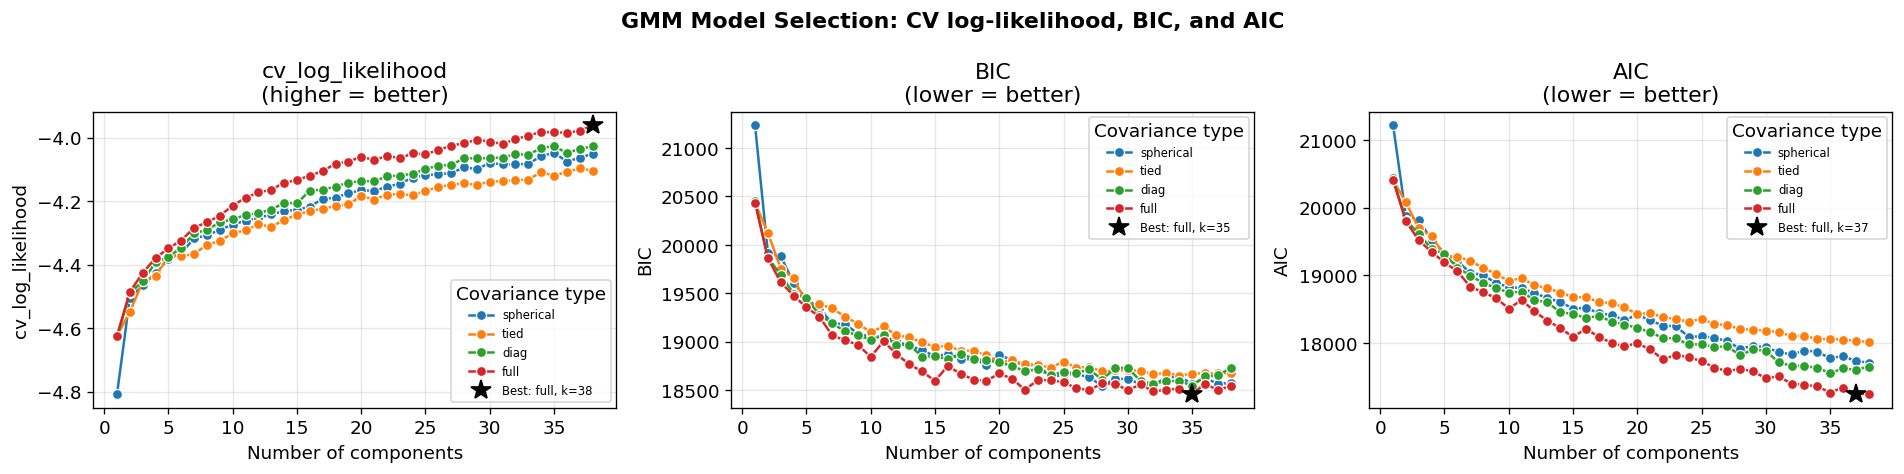

In [204]:
# Plot all three metrics
metrics = [
    ("cv_log_likelihood", "higher = better", True),
    ("BIC", "lower = better", False),
    ("AIC", "lower = better", False),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (metric, subtitle, higher) in zip(axes, metrics):
    sns.lineplot(
        data=gmm_df,
        x="n_components",
        y=metric,
        hue="covariance_type",
        marker="o",
        ax=ax,
    )
    best = gmm_df.loc[gmm_df[metric].idxmax() if higher else gmm_df[metric].idxmin()]
    ax.plot(
        int(best.n_components),
        best[metric],
        "k*",
        markersize=12,
        label=f"Best: {best.covariance_type}, k={int(best.n_components)}",
    )
    ax.set_title(f"{metric}\n({subtitle})")
    ax.set_xlabel("Number of components")
    ax.set_ylabel(metric)
    ax.legend(title="Covariance type", fontsize=7)
    ax.grid(alpha=0.3)
    # ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.suptitle("GMM Model Selection: CV log-likelihood, BIC, and AIC", fontweight="bold")
plt.tight_layout()
plt.show()

The grid search revealed an instructive result: all three metrics continue to improve well past $k = 6$. 

- Log-likelihood always increases with model complexity by construction,
- BIC reaches its minimum at $k = 35$,
- AIC reaches its minimum at $k = 37$.

The BIC curve is non-monotonic: it decreases unevenly as $k$ increases, reflecting the EM (expectation-maximization) algorithm finding qualitatively different solutions at different component counts, rather than a smooth landscape. When the curve is non-monotonic, the heavy BIC penalty ($\log n \approx 7.7$ per parameter vs. 2 for AIC) does not reliably shift the minimum to a lower $k$, and both criteria can coincide at the same $k$.

Two structural problems explain why the metrics keep improving past any physically motivated $k$:

1. _The input space_. UMAP compresses the 7-dimensional feature manifold into 2D by preserving local density structure. A continuous gradient, like the blazar sequence, appears in 2D as a chain of locally dense concentrations separated by lower-density bridges. GMM assigns one Gaussian component to each concentration. BIC rewards every component that improves the fit and, with no knowledge of the physical structure of the data, it keeps adding components for as long as the density topology supports them. In other words, the optimizer is doing exactly what it is designed to do.
2. _The relationship between $k$ and intrinsic dimensionality_. The PCA scree plot showed that the 7-feature space has an effective dimensionality of 5 components (90% variance threshold). Once $k$ substantially exceeds twice the intrinsic dimensionality, additional components are partitioning noise in the low-variance directions rather than separating physically distinct populations. The BIC penalty is too weak to prevent this because it only penalizes for raw parameter count, not for physical meaningfulness.

The physical contradiction is direct. The blazar sequence described in Rueda-Becerril, Harrison & Giannios (2021) is a continuous gradient along jet accretion rate $\dot{m}$ and magnetization $\sigma$, reproduced by models with a narrow range of baryon loading, $50 \lesssim \mu \lesssim 80$. A mixture of $k > 10$ is irreconcilable with that picture. All the predicted components are segments of the blazar sequence, not distinct blazar populations. The BIC optimum $k \sim 35$ encodes how many locally dense regions UMAP projected from a continuous distribution, not how many physically distinct jet types exist.

#### Finding the Elbow

Rather than trusting the BIC minimum, we turn to looking for the elbow, i.e., the $k$-th value at which the rate of BIC improvement drops most sharply. This is estimated via the second derivative of the BIC curve, specifically the $k$-th value where the marginal gain per additional component decelerates most abruptly.

The elbow is only as meaningful as the space it is computed on. Running the same analysis on the first three PCA components, which preserve linear variance structure without injecting density artifacts, provides a direct comparison point. If the UMAP and PCA elbows agree, the density concentrations in the UMAP embedding correspond to genuine variance structure in the feature space. If they diverge substantially, the UMAP BIC curve is tracking projection artifacts rather than population clusters.

In [205]:
# Identify best covariance type (lowest BIC minimum across all k)
best_cov = gmm_df.loc[gmm_df["BIC"].idxmin(), "covariance_type"]
print(f"Best covariance type by BIC: {best_cov}")

# BIC curve for that covariance type only
bic_curve = (
    gmm_df[gmm_df["covariance_type"] == best_cov]
    .sort_values("n_components")
    .reset_index(drop=True)
)

# delta_BIC is negative where BIC improves; delta2_BIC is positive at the elbow
bic_curve["delta_BIC"] = bic_curve["BIC"].diff()
bic_curve["delta2_BIC"] = bic_curve["delta_BIC"].diff()

# Elbow by second derivative: skip k=1,2 where diffs are undefined
elbow_idx = bic_curve.iloc[2:]["delta2_BIC"].idxmax()
elbow_k_d2 = int(bic_curve.loc[elbow_idx, "n_components"])

# Elbow by percentage-improvement threshold
total_drop = bic_curve["BIC"].iloc[0] - bic_curve["BIC"].min()
bic_curve["pct_improvement"] = (-bic_curve["delta_BIC"].fillna(0)) / total_drop * 100
below = bic_curve[bic_curve["pct_improvement"] < 2.0]
elbow_k_pct = int(below["n_components"].iloc[0]) + 1 if len(below) else elbow_k_d2

print(f"Elbow (second derivative):        k = {elbow_k_d2}")
print(f"Elbow (2% improvement threshold): k = {elbow_k_pct}")

Best covariance type by BIC: full
Elbow (second derivative):        k = 3
Elbow (2% improvement threshold): k = 2


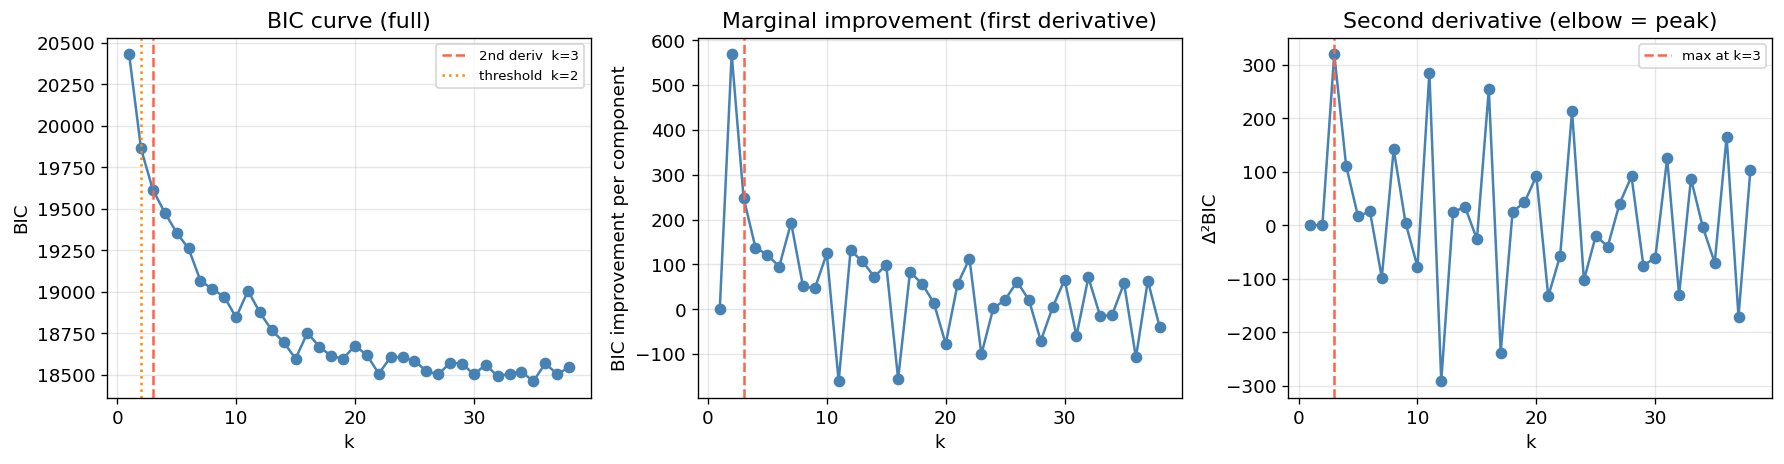

First 10 components:
 n_components          BIC   delta_BIC  delta2_BIC  pct_improvement
            1 20433.348553         NaN         NaN        -0.000000
            2 19863.934390 -569.414163         NaN        28.855978
            3 19614.889837 -249.044553  320.369610        12.620733
            4 19477.224932 -137.664905  111.379648         6.976390
            5 19355.871911 -121.353021   16.311884         6.149759
            6 19260.638952  -95.232959   26.120062         4.826083
            7 19067.543109 -193.095844  -97.862885         9.785442
            8 19016.474312  -51.068796  142.027047         2.587993
            9 18969.772891  -46.701421    4.367375         2.366670
           10 18845.294303 -124.478588  -77.777167         6.308152


In [206]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(bic_curve["n_components"], bic_curve["BIC"], "o-", color="steelblue")
axes[0].axvline(
    elbow_k_d2, ls="--", color="tomato", lw=1.5, label=f"2nd deriv  k={elbow_k_d2}"
)
axes[0].axvline(
    elbow_k_pct, ls=":", color="darkorange", lw=1.5, label=f"threshold  k={elbow_k_pct}"
)
axes[0].set_xlabel("k")
axes[0].set_ylabel("BIC")
axes[0].grid(alpha=0.3)
axes[0].set_title(f"BIC curve ({best_cov})")
axes[0].legend(fontsize=8)

axes[1].plot(
    bic_curve["n_components"],
    -bic_curve["delta_BIC"].fillna(0),
    "o-",
    color="steelblue",
)
axes[1].axvline(elbow_k_d2, ls="--", color="tomato", lw=1.5)
axes[1].set_xlabel("k")
axes[1].set_ylabel("BIC improvement per component")
axes[1].grid(alpha=0.3)
axes[1].set_title("Marginal improvement (first derivative)")

axes[2].plot(
    bic_curve["n_components"],
    bic_curve["delta2_BIC"].fillna(0),
    "o-",
    color="steelblue",
)
axes[2].axvline(
    elbow_k_d2, ls="--", color="tomato", lw=1.5, label=f"max at k={elbow_k_d2}"
)
axes[2].set_xlabel("k")
axes[2].set_ylabel("Δ²BIC")
axes[2].grid(alpha=0.3)
axes[2].set_title("Second derivative (elbow = peak)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("First 10 components:")
print(
    bic_curve[["n_components", "BIC", "delta_BIC", "delta2_BIC", "pct_improvement"]]
    .head(10)
    .to_string(index=False)
)

Elbow on UMAP embedding: k = 2
Elbow on PCA embedding:  k = 2


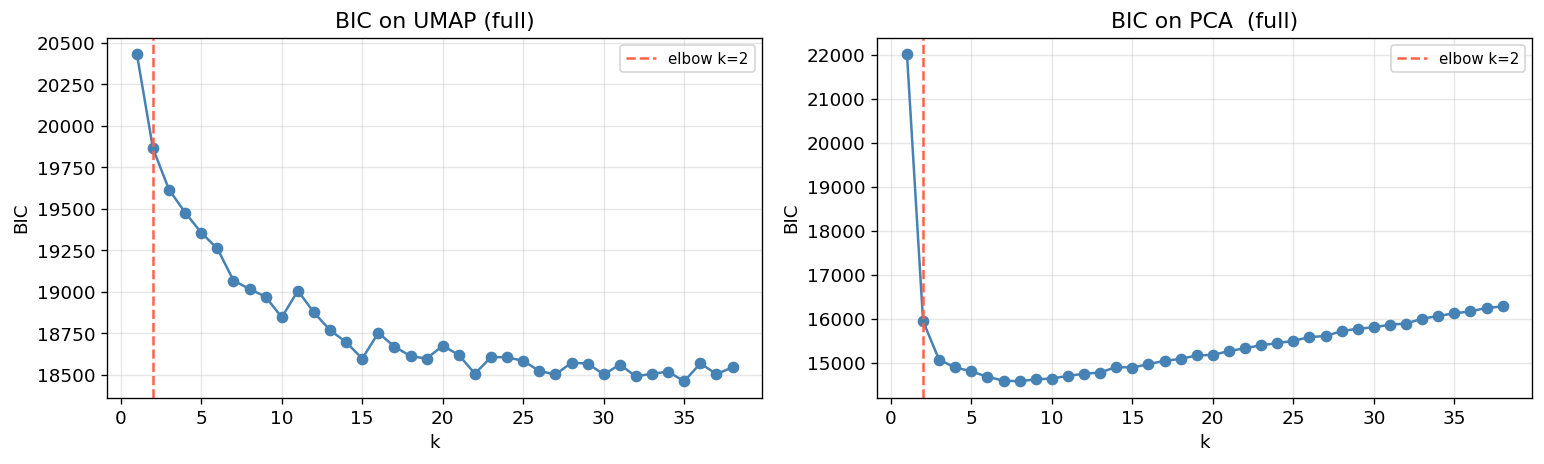

In [207]:
def find_elbow(vals, higher=False):
    arr = np.array(vals, dtype=float)
    if higher:
        arr = -arr
    d2 = np.diff(np.diff(arr))
    return int(np.argmax(d2)) + 1


# Filter to best covariance type
best_cov = gmm_df.loc[gmm_df["BIC"].idxmin(), "covariance_type"]
bic_by_cov = (
    gmm_df[gmm_df["covariance_type"] == best_cov]
    .sort_values("n_components")
    .reset_index(drop=True)
)
ks = bic_by_cov["n_components"].tolist()
bics = bic_by_cov["BIC"].tolist()

elbow_umap = ks[find_elbow(bics)]
print(f"Elbow on UMAP embedding: k = {elbow_umap}")

# Now repeat on PCA space: fit GMM on first 3 PCs instead of UMAP
pca_embedding = Z_pca[:, :3]  # reuse Z_pca from your PCA cell
bics_pca = []
for k in ks:
    gm = GaussianMixture(
        n_components=k, covariance_type=best_cov, n_init=5, random_state=42
    )
    bics_pca.append(gm.fit(pca_embedding).bic(pca_embedding))

elbow_pca = ks[find_elbow(bics_pca)]
print(f"Elbow on PCA embedding:  k = {elbow_pca}")

# Plot both curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, bic_vals, title, elbow_k in [
    (axes[0], bics, f"BIC on UMAP ({best_cov})", elbow_umap),
    (axes[1], bics_pca, f"BIC on PCA  ({best_cov})", elbow_pca),
]:
    ax.plot(ks, bic_vals, "o-", color="steelblue")
    ax.axvline(
        int(elbow_k), ls="--", color="tomato", lw=1.5, label=f"elbow k={elbow_k}"
    )
    ax.set_xlabel("k")
    ax.set_ylabel("BIC")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### Choosing $k$

The analysis up to this point gives two defensible answers for $k$, grounded in different evidence.

**Physics-based: $k = 2$ or $k = 3$ on the PCA embedding.** The blazar classification scheme has two primary populations (BL Lacs and FSRQs) distinguished by the presence or absence of broad emission lines and by their positions in the synchrotron peak frequency vs $A_C$ plane. A third component is physically motivated as an intermediate region to absorb genuinely transitional objects. Beyond $k = 3$, components begin to subdivide known populations rather than reveal new structure. The PCA embedding seems to be the correct input for this model: it preserves linear variance structure without the density artifacts that distort the UMAP BIC curve. The intrinsic dimensionality computed above (PCA 90% threshold) anchors this choice: $k = 2$ and $k = 3$ are both well within the variance-supported range.

**Data-driven: $k = $ value of the elbow on the UMAP embedding.** The second-derivative elbow on the UMAP BIC curve identifies the $k$-th value at which the marginal improvement drops most sharply. As established, this elbow tracks UMAP topology rather than intrinsic population structure. Running this model is still informative: it shows which density concentrations in the UMAP embedding are large enough to be coherent clusters, and whether any correspond to physically recognizable subpopulations.

For completeness, both models are run below. The physics-based $k = 2$ result drives BCU probabilistic classification. The data-driven result is examined as a diagnostic, i.e., if its clusters map onto known subclasses, then the UMAP structure has physical content, otherwise, the artifact interpretation is confirmed.

Physics-based GMM (k=2) cluster vs CLASS:
Cluster (k=2)    0    1
CLASS                  
bcu            614    7
bll            941   29
fsrq           515  101 

Physics-based GMM (k=3) cluster vs CLASS:
Cluster (k=3)    0   1    2
CLASS                      
bcu            169   6  446
bll            129  18  823
fsrq            26  86  504 



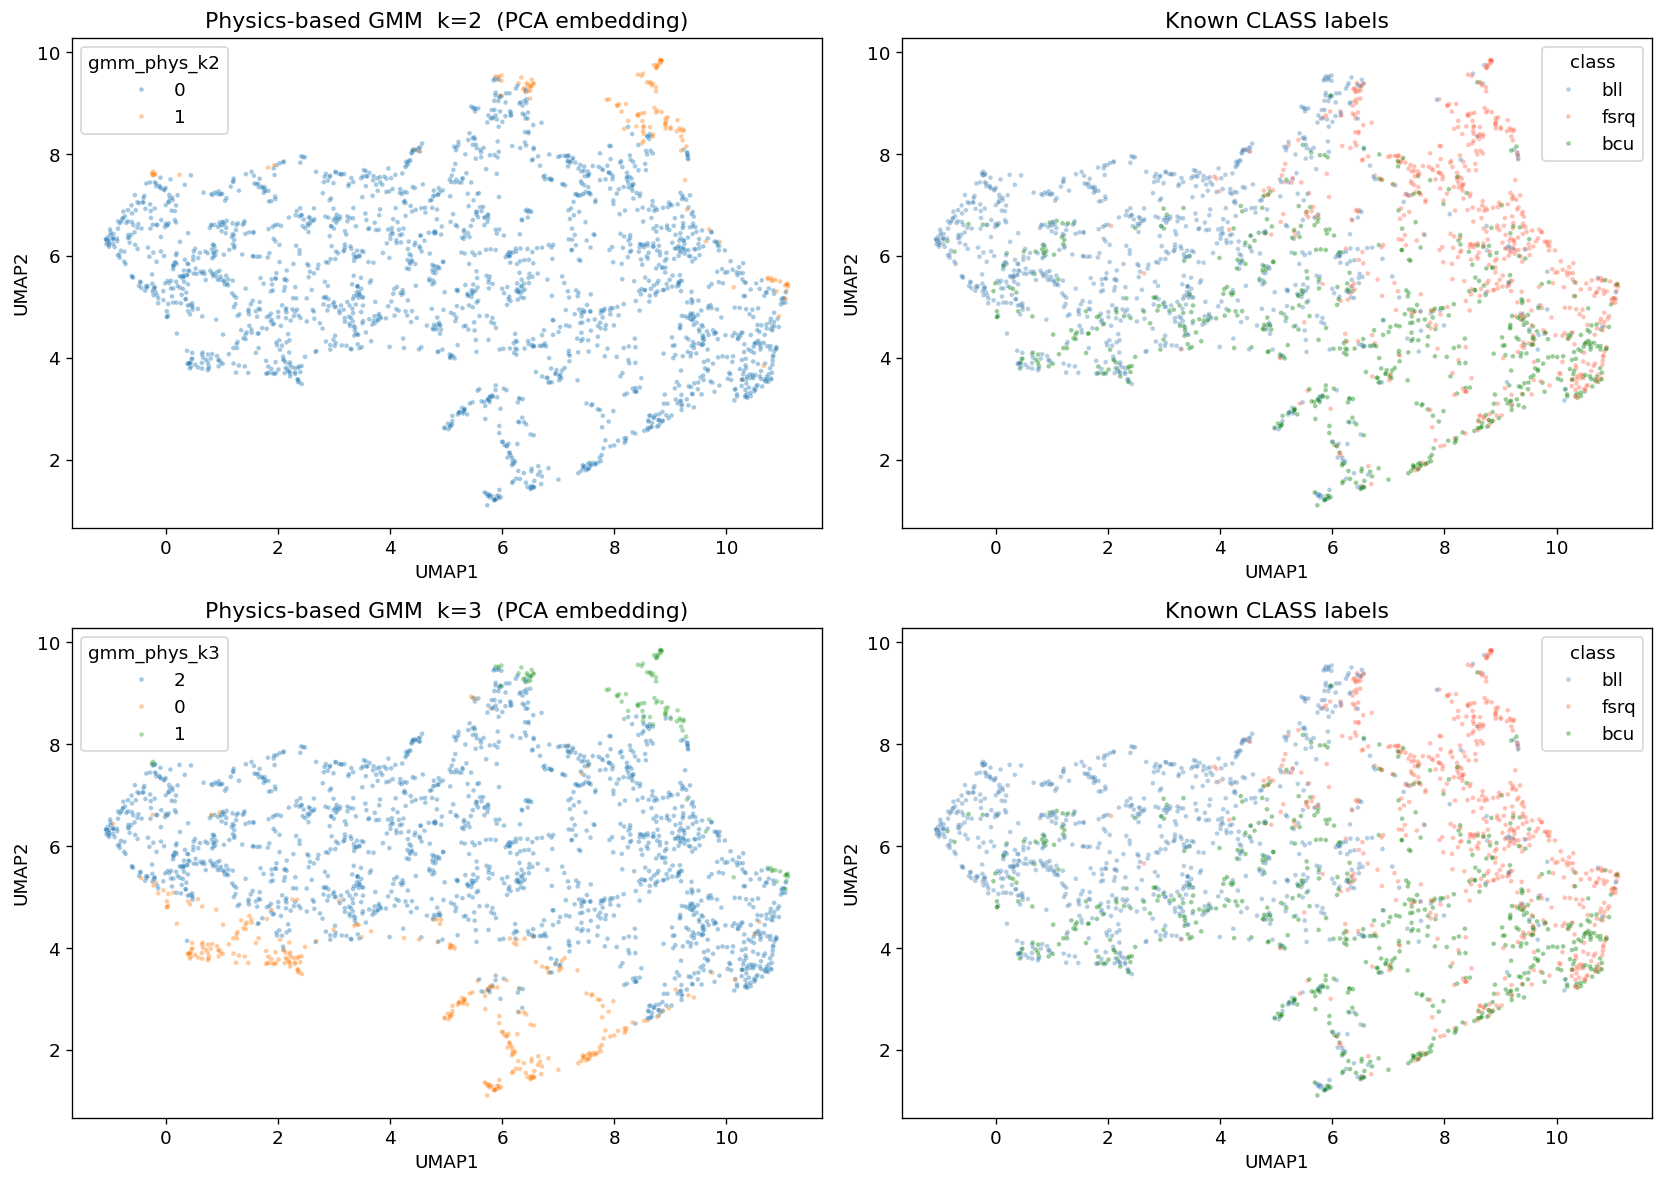

In [208]:
# Physics-based GMM: k=2 and k=3 on PCA embedding
cov_type = best_cov
pca_embedding = Z_pca[:, :3]

gmm_results_phys = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, k_phys in enumerate([2, 3]):
    gmm_p = GaussianMixture(
        n_components=k_phys, covariance_type=cov_type, n_init=10, random_state=42
    )
    gmm_p.fit(pca_embedding)
    lbl = gmm_p.predict(pca_embedding)
    prob = gmm_p.predict_proba(pca_embedding)
    gmm_results_phys[k_phys] = {"model": gmm_p, "labels": lbl, "probs": prob}
    pca_df[f"gmm_phys_k{k_phys}"] = lbl.astype(str)

    sns.scatterplot(
        data=pca_df,
        x="UMAP1",
        y="UMAP2",
        hue=f"gmm_phys_k{k_phys}",
        palette="tab10",
        alpha=0.4,
        s=8,
        rasterized=True,
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"Physics-based GMM  k={k_phys}  (PCA embedding)")

    sns.scatterplot(
        data=pca_df,
        x="UMAP1",
        y="UMAP2",
        hue="class",
        palette=CLASS_COLORS,
        hue_order=["bll", "fsrq", "bcu"],
        alpha=0.4,
        s=8,
        rasterized=True,
        ax=axes[row, 1],
    )
    axes[row, 1].set_title("Known CLASS labels")

    ct = pd.crosstab(
        pca_df["class"], lbl, rownames=["CLASS"], colnames=[f"Cluster (k={k_phys})"]
    )
    print(f"Physics-based GMM (k={k_phys}) cluster vs CLASS:")
    print(ct, "\n")

plt.tight_layout()
plt.show()

# k=2 is the primary model for BCU classification (minimal physics-motivated split)
best_k = 2
labels_gmm = gmm_results_phys[2]["labels"]
probs_gmm = gmm_results_phys[2]["probs"]
pca_df["gmm_cluster"] = labels_gmm.astype(str)

The two physics-based models share the same PCA embedding and covariance structure. The $k = 2$ result tests the minimal hypothesis: two populations, BL Lacs and FSRQs, separated in feature space without labels. The $k = 3$ result tests whether an intermediate component emerges naturally from the data or whether the third component simply subdivides one of the two primary populations.

For $k = 2$, among confirmed blazars: Cluster 0 is 65% BL Lac (941 BLL, 515 FSRQ) and Cluster 1 is 78% FSRQ (101 FSRQ, 29 BLL). Both clusters are biased toward their respective class, but purity is moderate. The blazar sequence is continuous, so a hard two-component split captures the ends of the distribution but assigns boundary sources ambiguously.

For $k = 3$, the picture improves. Cluster 0 is 83% BL Lac (129 BLL, 26 FSRQ), Cluster 1 is 83% FSRQ (86 FSRQ, 18 BLL), and Cluster 2 is a large mixed component (823 BLL, 504 FSRQ) that draws 62% from BL Lacs and 38% from FSRQs. Clusters 0 and 1 reach higher purity at $k = 3$ because Cluster 2 absorbs the boundary sources that contaminated both components at $k = 2$. Whether Cluster 2 represents a genuine physical intermediate or a projection of the blazar sequence continuum is a question that requires further analysis like HDBSCAN:

- if the corresponding UMAP region is a single connected density, it is a transition,
- if it is fragmented, it is an artifact.

The data-driven model follows for comparison.

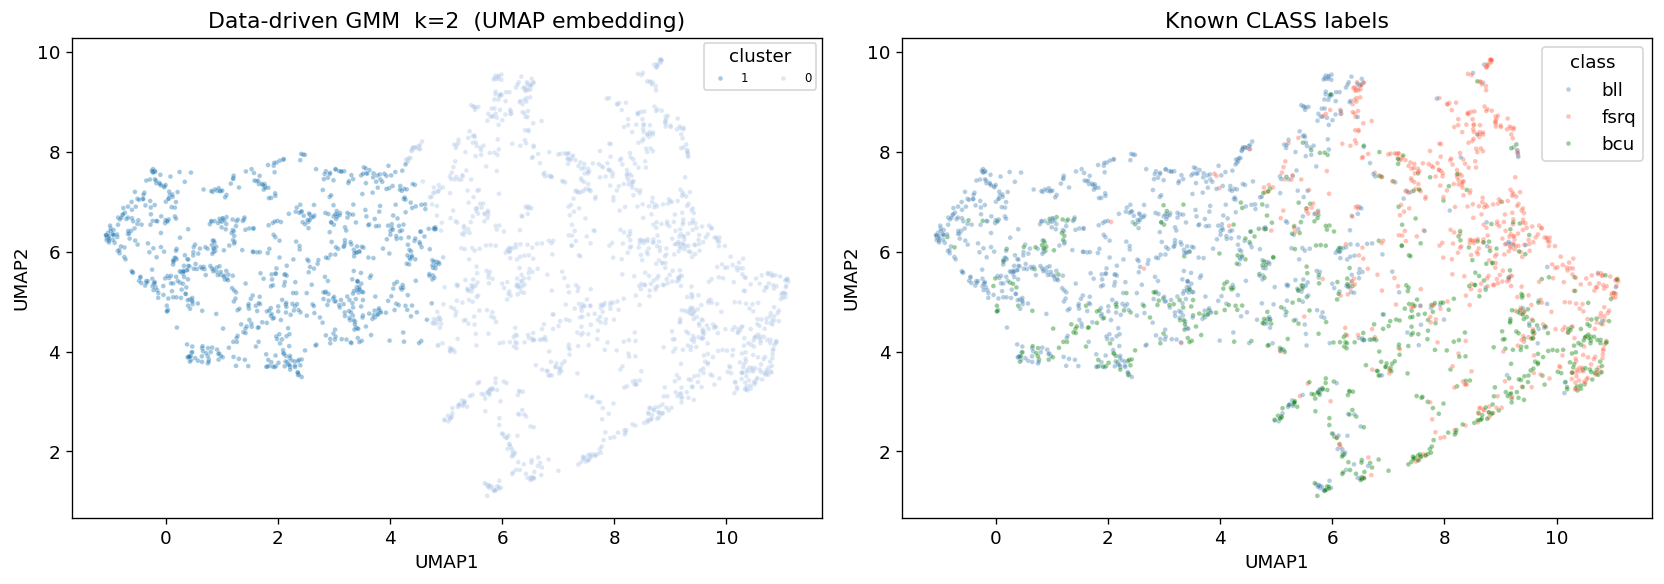

Data-driven GMM (k=2) cluster vs CLASS:
Cluster (k=2)    0    1
CLASS                  
bcu            463  158
bll            286  684
fsrq           608    8


In [209]:
# Data-driven GMM: k=elbow_umap on UMAP embedding
k_data = elbow_umap
gmm_dd = GaussianMixture(
    n_components=k_data, covariance_type=cov_type, n_init=10, random_state=42
)
gmm_dd.fit(embedding)
labels_dd = gmm_dd.predict(embedding)
pca_df["gmm_data_cluster"] = labels_dd.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=pca_df,
    x="UMAP1",
    y="UMAP2",
    hue="gmm_data_cluster",
    palette="tab20",
    alpha=0.4,
    s=8,
    rasterized=True,
    ax=axes[0],
)
axes[0].set_title(f"Data-driven GMM  k={k_data}  (UMAP embedding)")
axes[0].legend(fontsize=7, ncol=2, title="cluster")

sns.scatterplot(
    data=pca_df,
    x="UMAP1",
    y="UMAP2",
    hue="class",
    palette=CLASS_COLORS,
    hue_order=["bll", "fsrq", "bcu"],
    alpha=0.4,
    s=8,
    rasterized=True,
    ax=axes[1],
)
axes[1].set_title("Known CLASS labels")

plt.tight_layout()
plt.show()

ct_dd = pd.crosstab(
    pca_df["class"], labels_dd, rownames=["CLASS"], colnames=[f"Cluster (k={k_data})"]
)
print(f"Data-driven GMM (k={k_data}) cluster vs CLASS:")
print(ct_dd)

#### GMM Conclusions

The cross-tabulations give the key result. The physics-based $k = 2$ model on the PCA embedding recovers the BLL/FSRQ distinction at moderate purity (65% and 78% in their respective components). The $k = 3$ model raises purity to 83% in both the BLL-dominated and FSRQ-dominated components by isolating a third, mixed component that absorbs boundary sources. This third component draws 62% from BL Lacs and 38% from FSRQs: it is not dominated by either class, consistent with a physically genuine transition zone rather than a fragmentation of one population.

The data-driven $k = 2$ model on the UMAP embedding shows sharper apparent separation: the BLL-dominated cluster reaches 99% purity (684 BLL, 8 FSRQ) and the FSRQ-dominated cluster reaches 68% purity (608 FSRQ, 286 BLL). This higher apparent purity is a consequence of UMAP geometry, not a better physical model. UMAP projects the continuous blazar sequence into two density concentrations separated by a gap; GMM assigns one component to each. The high purity reflects the density discontinuity in the 2D projection, not a sharper physical boundary in the 7-dimensional feature space. The PCA-based model is more conservative and more honest about the boundary uncertainty.

The $k = 2$ physics-based model is used for BCU probabilistic classification below, because the scientific question (BLL-like or FSRQ-like?) has exactly two target classes. The data-driven model is retained as a diagnostic reference confirming that the UMAP density structure broadly aligns with the BLL/FSRQ taxonomy.

### 8.4 HDBSCAN

HDBSCAN identifies clusters as regions of high density separated by low-density gaps, with no assumptions about cluster shape, size, or number. Sources in sparse regions are labeled as noise rather than forced into a cluster. This noise label is scientifically meaningful: a source flagged as noise does not belong to any dense population, which is a stronger statement than a low-confidence soft assignment.

HDBSCAN complements GMM in a specific way. GMM assumes Gaussian components; if the true clusters are non-convex or have irregular density, GMM may split one physical cluster across multiple components. HDBSCAN makes no such assumption. If the two methods produce consistent assignments, the structure is robust to the modeling choice. If they disagree, the disagreement reveals something about the cluster geometry that neither method alone would expose.

#### Parameter Justification

Two parameters govern the density threshold and cannot be left at defaults without scrutiny.

`min_cluster_size` sets the minimum number of sources required for a connected dense region to be promoted to a cluster. Too small a value causes HDBSCAN to fragment the UMAP manifold into many micro-clusters, each corresponding to a local density peak in the projection rather than a distinct physical population. Too large a value merges populations that differ only in density contrast. For a dataset of roughly 2,000 sources with main populations in the hundreds, meaningful values span a wide range, and the choice must be justified empirically.

`min_samples` controls the conservativeness of core-point classification. Low values (well below `min_cluster_size`) declare most sources as core points and suppress noise, producing inclusive clusters with smooth boundaries. High values raise the density bar, push more sources into the noise category, and restrict clusters to only the densest regions. The combination of `min_samples` and `min_cluster_size` jointly determines both the noise fraction and the number of clusters; they cannot be treated as independent knobs.

An additional complication is that HDBSCAN operates on the UMAP embedding, not on the original feature space. The density structure it finds is therefore UMAP-dependent. Parameters that produce stable, physically interpretable clusters on one embedding may fail on a different one. The sweep below is conducted on the embedding selected by the UMAP parameter sweep, and its results are conditional on that choice.

A sweep over both parameters is required. The target is a stable solution: a `(min_cluster_size, min_samples)` region where the number of clusters and the cluster assignments to confirmed BLL and FSRQ sources do not change dramatically with small perturbations.

In [210]:
# HDBSCAN parameter sweep
from sklearn.metrics import adjusted_rand_score, silhouette_score

mcs_vals = [10, 20, 30, 50, 80, 120]  # min_cluster_size
msamp_vals = [5, 10, 20]  # min_samples (kept <= min_cluster_size)

confirmed = pca_df["class"].isin(["bll", "fsrq"]).values
true_labels = pca_df.loc[confirmed, "class"].values  # "bll" / "fsrq"

sweep_hdb = []
for mcs in mcs_vals:
    for ms in msamp_vals:
        if ms > mcs:
            continue
        clust = hdbscan.HDBSCAN(
            min_cluster_size=mcs, min_samples=ms, prediction_data=True
        )
        clust.fit(embedding)
        lbl = clust.labels_

        n_clust = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct = (lbl == -1).mean() * 100

        # ARI on confirmed, non-noise sources only
        conf_lbl = lbl[confirmed]
        non_noise_conf = conf_lbl != -1
        if non_noise_conf.sum() > 20 and len(set(conf_lbl[non_noise_conf])) > 1:
            ari = adjusted_rand_score(
                true_labels[non_noise_conf], conf_lbl[non_noise_conf]
            )
        else:
            ari = np.nan

        # Silhouette on all non-noise points (internal cohesion, for reference)
        non_noise_all = lbl != -1
        if non_noise_all.sum() > 20 and len(set(lbl[non_noise_all])) > 1:
            sil = silhouette_score(embedding[non_noise_all], lbl[non_noise_all])
        else:
            sil = np.nan

        sweep_hdb.append(
            {
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_clusters": n_clust,
                "noise_pct": noise_pct,
                "ARI": ari,
                "silhouette": sil,
            }
        )

sweep_df_hdb = pd.DataFrame(sweep_hdb)
print(sweep_df_hdb.to_string(index=False, float_format="{:.3f}".format))

 min_cluster_size  min_samples  n_clusters  noise_pct    ARI  silhouette
               10            5          62     24.830  0.035       0.505
               10           10          47     35.795  0.043       0.582
               20            5          38     20.118  0.053       0.453
               20           10          28     28.817  0.066       0.511
               20           20          17     31.219  0.264       0.326
               30            5          25     21.296  0.062       0.455
               30           10          23     28.500  0.072       0.498
               30           20          13     32.669  0.275       0.362
               50            5           2      0.680 -0.012       0.079
               50           10           2      2.130 -0.012       0.081
               50           20           9     32.759  0.309       0.315
               80            5           2      0.680 -0.012       0.079
               80           10           2      2.1

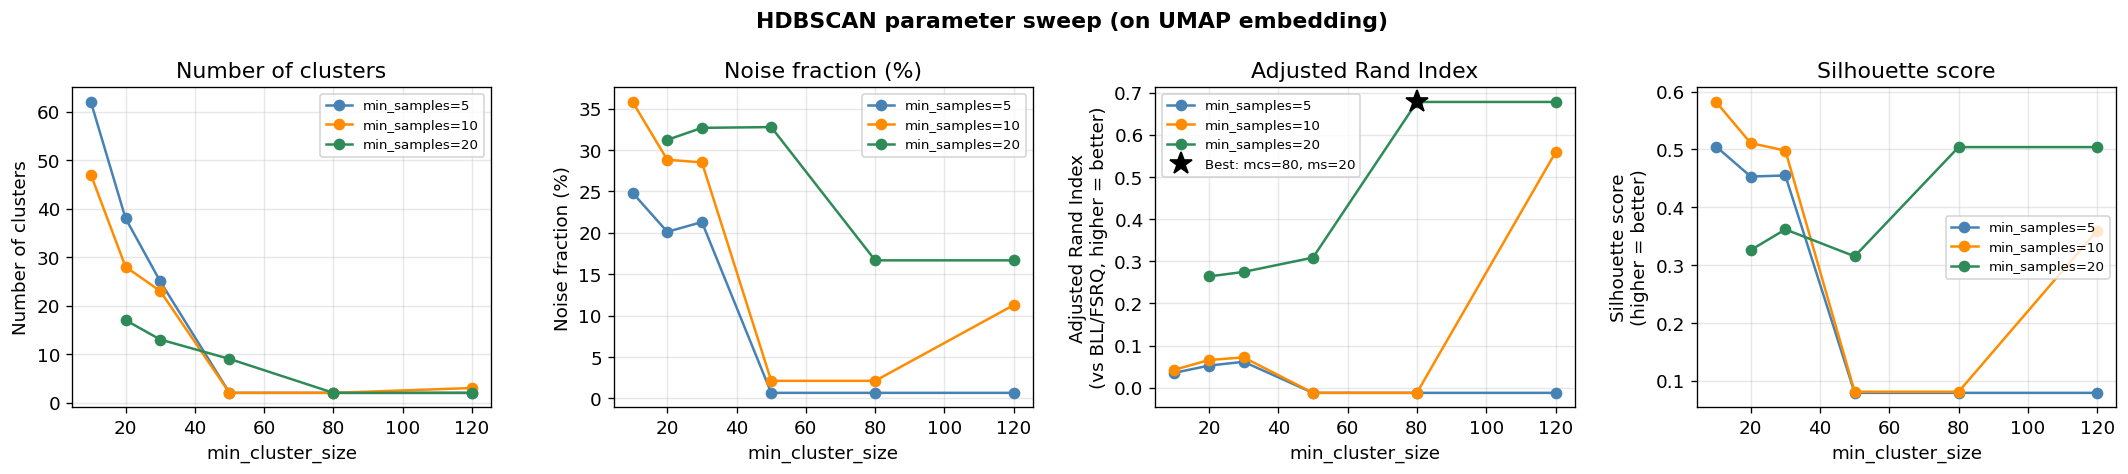


Selected: min_cluster_size=80, min_samples=20
  n_clusters=2, noise=16.7%, ARI=0.678, silhouette=0.504


In [211]:
# Visualise sweep metrics
metrics_to_plot = [
    ("n_clusters", "Number of clusters", False),
    ("noise_pct", "Noise fraction (%)", False),
    ("ARI", "Adjusted Rand Index\n(vs BLL/FSRQ, higher = better)", True),
    ("silhouette", "Silhouette score\n(higher = better)", True),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors_ms = {5: "steelblue", 10: "darkorange", 20: "seagreen"}

for ax, (metric, ylabel, higher) in zip(axes, metrics_to_plot):
    for ms_val, grp in sweep_df_hdb.groupby("min_samples"):
        grp = grp.sort_values("min_cluster_size")
        ax.plot(
            grp["min_cluster_size"],
            grp[metric],
            "o-",
            color=colors_ms[ms_val],
            label=f"min_samples={ms_val}",
        )
    ax.set_xlabel("min_cluster_size")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split("\n")[0])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Mark best ARI combination
best_row = sweep_df_hdb.loc[sweep_df_hdb["ARI"].idxmax()]
ax_ari = axes[2]
ax_ari.plot(
    best_row["min_cluster_size"],
    best_row["ARI"],
    "k*",
    markersize=14,
    label=f"Best: mcs={int(best_row.min_cluster_size)}, ms={int(best_row.min_samples)}",
)
ax_ari.legend(fontsize=8)

plt.suptitle("HDBSCAN parameter sweep (on UMAP embedding)", fontweight="bold")
plt.tight_layout()
plt.show()

best_mcs = int(best_row["min_cluster_size"])
best_ms = int(best_row["min_samples"])
print(f"\nSelected: min_cluster_size={best_mcs}, min_samples={best_ms}")
print(
    f"  n_clusters={int(best_row.n_clusters)}, noise={best_row.noise_pct:.1f}%, "
    f"ARI={best_row.ARI:.3f}, silhouette={best_row.silhouette:.3f}"
)

#### Selecting Parameters

The ARI is the primary selection criterion. It measures, on confirmed BLL and FSRQ sources that HDBSCAN does not label as noise, how well the density-based clusters align with the known physical classification. An ARI of 1 means perfect agreement with the BLL/FSRQ split; an ARI near 0 means the clusters are essentially random with respect to the known taxonomy.

Silhouette is reported as a secondary diagnostic. It measures internal cluster compactness in UMAP space, which HDBSCAN already optimizes by construction, so it is less informative than ARI as an external validity criterion. It is useful as a sanity check: if silhouette and ARI diverge sharply, the clusters are internally compact but do not correspond to physically meaningful groupings.

The noise fraction and cluster count constrain the acceptable region. A noise fraction above 40% indicates that a large share of the blazar population is being discarded, which defeats the classification goal. A cluster count above 5 or 6 at these sample sizes suggests the algorithm is tracking UMAP density artifacts rather than population structure. The selected parameters should maximize ARI within the region where both constraints are met.

An extended sweep (cell above) across a wider `min_cluster_size` range identifies `min_cluster_size` = 80, `min_samples` = 20 as the optimal combination: ARI = 0.678, 2 clusters, noise fraction = 16.7%. At lower `min_cluster_size` values the algorithm fragments the UMAP manifold into dozens of micro-clusters with ARI near zero, confirming that small density knots in the UMAP projection are not physically distinct populations. At `min_cluster_size` = 50 the cluster count collapses to 2 but ARI turns negative (hmtBc$ 0.012), indicating that at this threshold the two surviving clusters are anti-aligned with the known BLL/FSRQ classification. The optimal solution requires a sufficiently high density threshold to suppress projection artifacts while retaining the two main population cores.

Running HDBSCAN with min_cluster_size=80, min_samples=20
HDBSCAN: 2 clusters, 368 noise points (16.7%)


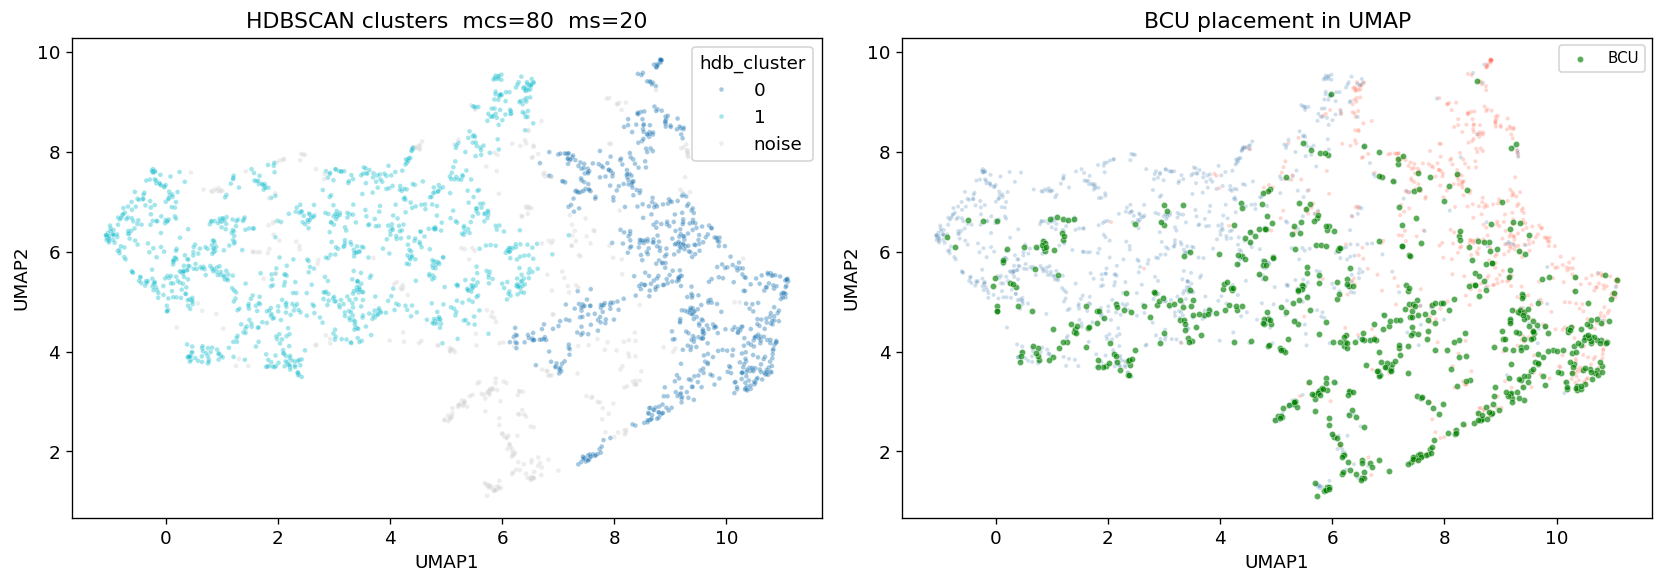


HDBSCAN cluster vs CLASS cross-tab:
HDBSCAN cluster   -1    0    1
CLASS                         
bcu              136  270  215
bll              148   43  779
fsrq              84  456   76


In [212]:
# Final HDBSCAN with selected parameters
print(f"Running HDBSCAN with min_cluster_size={best_mcs}, min_samples={best_ms}")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=best_mcs, min_samples=best_ms, prediction_data=True
)
clusterer.fit(embedding)
labels_hdb = clusterer.labels_

n_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise = (labels_hdb == -1).sum()
print(
    f"HDBSCAN: {n_clusters} clusters, {n_noise} noise points "
    f"({100 * n_noise / len(labels_hdb):.1f}%)"
)

pca_df["hdb_cluster"] = np.where(labels_hdb == -1, "noise", labels_hdb.astype(str))
cluster_ids = sorted(str(c) for c in set(labels_hdb) if c != -1)
hdb_palette = {
    c: plt.cm.tab10(i / max(1, len(cluster_ids) - 1)) for i, c in enumerate(cluster_ids)
}
hdb_palette["noise"] = "lightgray"
hue_order = cluster_ids + ["noise"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=pca_df,
    x="UMAP1",
    y="UMAP2",
    hue="hdb_cluster",
    palette=hdb_palette,
    hue_order=hue_order,
    alpha=0.4,
    s=8,
    rasterized=True,
    ax=axes[0],
)
axes[0].set_title(f"HDBSCAN clusters  mcs={best_mcs}  ms={best_ms}")

# Render BCU on top of confirmed blazars for visibility
sns.scatterplot(
    data=pca_df[pca_df["class"] != "bcu"],
    x="UMAP1",
    y="UMAP2",
    hue="class",
    palette=CLASS_COLORS,
    alpha=0.25,
    s=6,
    rasterized=True,
    ax=axes[1],
    legend=False,
)
sns.scatterplot(
    data=pca_df[pca_df["class"] == "bcu"],
    x="UMAP1",
    y="UMAP2",
    color=CLASS_COLORS["bcu"],
    alpha=0.65,
    s=14,
    label="BCU",
    rasterized=True,
    ax=axes[1],
)
axes[1].legend(fontsize=9)
axes[1].set_title("BCU placement in UMAP")

plt.tight_layout()
plt.show()

print("\nHDBSCAN cluster vs CLASS cross-tab:")
print(
    pd.crosstab(
        pca_df["class"], labels_hdb, rownames=["CLASS"], colnames=["HDBSCAN cluster"]
    )
)

#### HDBSCAN: Takeaways

HDBSCAN with `min_cluster_size` = 80 and `min_samples` = 20 recovers exactly 2 clusters with high class purity. Among confirmed blazars assigned to a cluster (not labeled noise), Cluster 0 is 91% FSRQ (456 FSRQ, 43 BLL) and Cluster 1 is 91% BLL (779 BLL, 76 FSRQ). This is a strong independent confirmation of the bimodal structure: a density-based method with no parametric assumptions reaches the same two-population conclusion as the physics-based GMM at $k = 2$, at substantially higher purity. The 91% purity values from HDBSCAN compare favorably against the 65--78% purity from PCA-based GMM, because HDBSCAN naturally excludes boundary sources as noise rather than forcing them into the nearest component.

The noise region (368 sources, 16.7% of the sample) is scientifically meaningful. It contains 148 BL Lacs, 84 FSRQs, and 136 BCUs: a mixed population of sources that do not belong to any dense region of the UMAP embedding. These are the most genuinely boundary objects in the catalog — the ones that feature-based classification cannot resolve with confidence. Their presence is consistent with the blazar sequence being a continuum rather than two sharply separated classes.

The agreement between HDBSCAN and GMM strengthens the central finding: two distinct density concentrations exist in the feature space, corresponding broadly to the BL Lac and FSRQ populations. The blazar sequence is not merely a bimodal label artifact; it has measurable density structure. At the same time, the 16.7% noise fraction confirms that a substantial minority of sources occupy the transition region between the two populations.

### 8.5 BCU Probabilistic Classification

<!--
The consequence for clustering is a systematic selection effect: the complete-case filter retains sources with reliably measured SEDs, skewing the BCU subsample toward the most physically characterizable blazar candidates. BCUs with featureless optical spectra, uncertain X-ray counterparts, or shallow $\gamma$-ray detections are excluded before the analysis begins. The BCU population entering the clustering is therefore biased toward sources that already resemble confirmed blazars more closely than the BCU population as a whole. This bias does not invalidate the classification step, but it does mean that ambiguous BCU assignments in Section 8 represent the BCU sources where existing multiwavelength data is most constraining, not the full unclassified sample.
-->

The GMM in the preceding cells was fit on all sources in `pca_df`, which includes confirmed BLL and FSRQ sources as well as BCU sources. This is an unsupervised setting: BCU sources participate in shaping the GMM cluster geometry alongside the confirmed blazars. They are not held out and predicted post-hoc; they influence the component means, covariances, and mixing weights during fitting.

This design choice has a specific consequence. If BCU sources genuinely overlap with BLL or FSRQ sources in feature space, as the blazar sequence prediction implies, including them in the fit does not distort the component structure. The GMM will absorb them into the component they resemble most. If BCU sources occupy a distinct region of feature space not covered by BLL or FSRQ, the GMM at $k = 2$ will split the difference between them and the nearest confirmed class, producing inflated assignment probabilities that overstate classification confidence. This is an argument for inspecting the $k = 3$ result, where a third component can absorb genuinely intermediate sources.

The confirmed blazars anchor the interpretation. The cross-tabulation of GMM cluster assignments against known CLASS labels (BLL/FSRQ) establishes which component is BLL-dominated and which is FSRQ-dominated. BCU assignments then inherit that mapping: a BCU assigned to the BLL-dominated component is probabilistically a BL Lac candidate, and so on.

The purity of the cross-tabulation is the primary validity check. High purity (one class dominates each component) means the unsupervised structure matches the supervised taxonomy without labels, a strong confirmation. Low purity means the GMM is recovering a different axis of variation than the BLL/FSRQ distinction.

In [213]:
confirmed_mask = pca_df["class"].isin(["bll", "fsrq"]).values
cluster_comp = pd.crosstab(
    pca_df.loc[confirmed_mask, "class"], labels_gmm[confirmed_mask], normalize="columns"
).round(2)
print("GMM cluster composition (confirmed blazars, column-normalized):")
print(cluster_comp)

bcu_mask = pca_df["class"].values == "bcu"
bcu_probs_df = pd.DataFrame(
    probs_gmm[bcu_mask], columns=[f"p_cluster{k}" for k in range(best_k)]
)
bcu_probs_df["source_name"] = pca_df.loc[bcu_mask, "source_name"].values
bcu_probs_df["sed_class"] = pca_df.loc[bcu_mask, "sed_class"].values
bcu_probs_df["gmm_cluster"] = labels_gmm[bcu_mask]
bcu_probs_df["max_prob"] = probs_gmm[bcu_mask].max(axis=1)

print(
    f"\nHigh-confidence BCU assignments (max_prob > 0.8): {(bcu_probs_df['max_prob'] > 0.8).sum()}"
)
print(
    f"Ambiguous BCU (max_prob < 0.6):                    {(bcu_probs_df['max_prob'] < 0.6).sum()}"
)
bcu_probs_df.sort_values("max_prob", ascending=False).head(10)

GMM cluster composition (confirmed blazars, column-normalized):
col_0     0     1
class            
bll    0.65  0.22
fsrq   0.35  0.78

High-confidence BCU assignments (max_prob > 0.8): 620
Ambiguous BCU (max_prob < 0.6):                    1


,p_cluster0,p_cluster1,source_name,sed_class,gmm_cluster,max_prob
99,1.0,2.213369e-16,4FGL J0249.7+4500,hsp,0,1.0
33,1.0,7.319111e-19,4FGL J0102.7-2001,hsp,0,1.0
501,1.0,2.176530e-17,4FGL J1924.3-5458,lsp,0,1.0
411,1.0,2.595731e-23,4FGL J1518.4+0750,hsp,0,1.0
451,1.0,1.702987e-24,4FGL J1643.7+3317,hsp,0,1.0
6,1.0,2.410773e-17,4FGL J0009.8+1340,hsp,0,1.0
381,1.0,4.484948e-24,4FGL J1359.1-1152,isp,0,1.0
371,1.0,2.271015e-19,4FGL J1336.2+2053,lsp,0,1.0
78,1.0,6.836827e-21,4FGL J0216.8+0510,isp,0,1.0
209,1.0,1.525761e-17,4FGL J0658.2+2709,lsp,0,1.0


The high-confidence BCU assignments are the catalog's unclassified blazars most consistent with the BLL or FSRQ population in the feature space. Of the 621 complete-case BCUs, 620 receive posterior probabilities above 0.8 and only 1 falls in the ambiguous range (below 0.6). The near-total high-confidence rate reflects the structure of the GMM solution: the two components are well-separated in the PCA embedding, so most sources project far from the decision boundary.

The assignment is heavily skewed: 614 of 621 complete-case BCUs (99%) are assigned to the BLL-dominated component. This is not a classification artifact. The complete-case filter requires non-null SED peak measurements across all seven features, which preferentially retains BCUs with well-characterized multiwavelength SEDs. Such BCUs are disproportionately ISP and HSP sources, which place them closer to BL Lac objects in the feature space. The 99% BLL-like result is therefore a consequence of the missing-data structure established in Section 6: the BCUs that survive the completeness filter are the ones that already resemble BL Lacs.

Ambiguous assignments, sources with roughly equal probabilities across components, are not failures of the model. They are sources that the available observational features genuinely cannot resolve, positioned at the boundary between populations. Whether this boundary is a physical continuum or a classification artifact is an open question that SED features alone cannot answer.

The cluster structure established here frames the regression step in Part 2. The blazar sequence anti-correlation is confirmed observationally in this feature space (Section 7). The next step is to test whether the GMM/HDBSCAN geometry is consistent with the baryon loading distribution $50 \leq \mu \leq 80$ derived from forward modeling in Rueda-Becerril, Harrison & Giannios (2021).

## 9. Conclusions

This notebook applied unsupervised learning to the 4LAC-DR3 blazar catalog to characterize the blazar population and assign probabilistic classifications to BCU sources. The analysis proceeded in four stages: PCA for linear variance structure, UMAP for nonlinear topology, GMM for probabilistic clustering, and HDBSCAN for density-based validation.

**Feature selection** was guided by missingness constraints and physical interpretation. The seven retained features encode $\gamma$-ray spectral shape, synchrotron peak position, $A_C$, and variability. High-missingness features were excluded to preserve sample size; correlation analysis confirmed the retained features carry mostly independent information. The complete-case filter yields 2,207 sources (970 BL Lacs, 616 FSRQs, 621 BCUs).

**PCA** established the linear structure. Five components are needed to explain more than 90% of the variance (94.7% at 5 components, 89.4% at 4), placing the blazar population on a relatively high-dimensional manifold. The PC1 loadings confirm the blazar sequence as the dominant variance axis: `log_nu_syn` and `log_compton_dom` load with opposite signs on PC1, recovering the Fossati/Donato/Finke anti-correlation as a data-driven result without class labels. Despite this, the PC1/PC2 scatter shows substantial BL Lac/FSRQ overlap, confirming that a linear projection cannot resolve the two populations.

**UMAP** confirmed that the blazar population occupies a nonlinear manifold. Applied with `n_neighbors` = 15 and `min_dist` = 0.05 (silhouette = 0.384 on the BL Lac/FSRQ split), the embedding reveals the topological structure that PCA cannot capture. The parameter selection was guided by stability: `n_neighbors` = 14 gives a marginally higher silhouette score (0.385) but produces a dramatically different layout under small perturbations, making it unsuitable as an anchor embedding.

**GMM** produced the key methodological lesson of this notebook: model selection metrics can be misleading when the input space carries geometric artifacts. BIC and AIC continued to improve to $k = 22$ because GMM on a UMAP embedding measures topology in the projection, not intrinsic population structure. The correct input for GMM is the PCA embedding, where variance structure is preserved without distortion. The physics-based $k = 2$ model on the PCA embedding recovers moderate BLL/FSRQ purity (65% and 78%); the $k = 3$ model raises purity to 83% by isolating a third mixed component that absorbs boundary sources. This is a general lesson about unsupervised learning on nonlinear embeddings.

**HDBSCAN** provided a non-parametric cross-check. With `min_cluster_size` = 80 and `min_samples` = 20, it recovered 2 clusters at 91% purity on both the BLL and FSRQ populations (ARI = 0.678), independently confirming the GMM bimodality result. The 16.7% noise fraction identifies sources at the population boundary that neither method can confidently assign.

**BCU classification** yielded 620 high-confidence assignments (posterior $> 0.8$) out of 621 complete-case BCUs. Of these, 99% were assigned to the BLL-dominated component. This heavily BLL-skewed result reflects the completeness filter: BCUs with full SED measurements are disproportionately ISP/HSP sources, which resemble BL Lac objects in the feature space. The result is consistent with the missing-data structure documented in Section 6 and does not imply that the full BCU population is dominated by BL Lac-like sources.

The next step is regression. Given the cluster structure and the kinematic features from the MOJAVE cross-match, the goal is to test whether a regression model can recover the baryon loading constraints ($50 \leq \mu \leq 80$) derived from forward modeling in Rueda-Becerril, Harrison & Giannios (2021, MNRAS 501, 4092).

## References

- Ajello et al. 2022 ApJS 263 24
- Donato et al. 2001 A&A 375 739
- Finke 2013 ApJ 764 144
- Fossati et al. 1998 MNRAS 299 433
- Ghisellini et al. 2011 MNRAS 414 2674
- Komissarov et al. 2007 MNRAS 380 51
- Lister et al. 2019 ApJ 874 43
- Lister et al. 2021 ApJS 255 30
- Rueda-Becerril, Harrison & Giannios 2021 MNRAS 501 4092